# MENTORÍA 06
# **Cambio climático y ML: cómo mitigar las emisiones de CO2 mediante la reducción del consumo energético en construcciones edilicias**

**TP N°3: Aprendizaje supervisado o no supervisado**

Fecha de entrega: **22 de septiembre**

Integrantes:
  
*   Valeria Becker
*   Marcos Asís Rodríquez
*   Ángel Valentino Indorato
*   Pablo Boggetti


## Consignas generales

En este último trabajo práctico, deberemos encargarnos de encontrar el modelo que logre las mejores métricas. Recuerden que tenemos un problema de REGRESIÓN, por lo que las métricas y los modelos a seleccionar deben ser acorde a ello.

**Métricas**

Lo primero que deberán discutir entre ustedes y decidir será:

1- ¿Qué métricas existen para evaluar modelos de regresión?

2- ¿Cuál de esas métricas es más conveniente utilizar y porqué?


**Modelos (elijan y testeen al menos DOS modelos)**
--> algunas opciones: Linear Regression, Decision Tree Regressor, Random Forest Regressor, XGBoost Regressor, LGGM Regressor, Gradient Boosting Regressor, Extra Trees Regressor (si no vieron nada de boosting o bagging, pueden quedarse solo con regresion lineal, probar regularización -lasso, ridge, elastic-net-, o árboles de decisión. Y si quieren ver algo de boosting o bagging les súper recomiendo los videitos de StatQuest).

En segundo lugar, deberán evaluar distintos modelos de regresión.

3- ¿Qué modelos de regresión existen (los que hayan visto)?

4- ¿Cuáles son sus hiperparámetros (de los que vayan a probar)?

5- ¿Qué me dice cada uno de esos hiperparámetros?

6- ¿Sobre qué conjunto de datos (train, val o test) deberé evaluar estos hiperparámetros?

Por último, les dejo una pregunta (tal vez tonta, pero tal vez no, basada en la confusión que me generó a mí la primera vez que me crucé con este modelo):

7- ¿Podré implementar una regresión logística? ¿porqué sí o porqué no?

## Extra: PIPELINES

Les planteo el siguiente punto como un ejercicio tipo bonus o complementario (no obligatorio), pero es súper conveniente que lo practiquen para, entre otras cosas:
1- hacer el código mucho más legible;
2- no pifiarle en los pasos de fit y transform sobre train y test, y así evitar data leakage.

La implementación de Pipelines tiene distintos niveles de complejidad. En este TP los invito a que, al menos, implementen el nivel más sencillo de todos. Aquí un a lista de posibilidades, de más sencillo a más complejo:

- Implementar un pipeline solo para variables numéricas;
- Implementar un pipeline para variables numéricas y categóricas (usando ColumnTransformer, por ejemplo);
- Implementar un pipeline que incluya las dos categorías de arriba mencionadas y GridSearchCV para cada modelo y sus hiperparámetros;
- Desarrollar sus propias clases (esto no lo se hacer del todo, pero si desean probar y compartir, más que bienvendio!)

Si necesitan algo de material extra, me avisan y les puedo facilitar algunas cosas.

# 1.IMPORTACION DE LIBRERIAS

In [22]:
!pip install missingno
!pip install optuna

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# 2.ESCENARIOS

Se muestra el codigo para generar los X_train, X_test, y_train e y_test para cada escenario

## PASOS EN COMUN

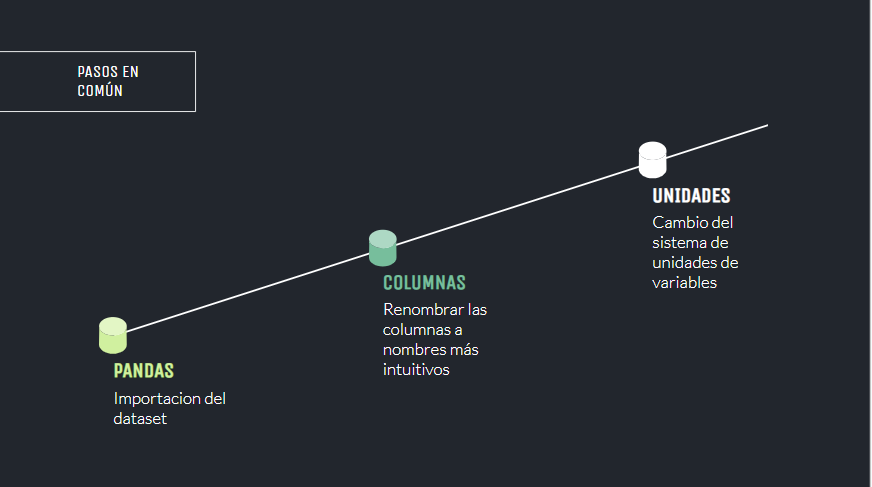

In [24]:
# 1) Importacion del data set
df = pd.read_csv("data.csv")

# 2) Renombrar columnas
df=df.rename(columns={
    'Year_Factor': 'factor_año',
    'State_Factor': 'factor_estado',
    'building_class': 'clase_edificio',
    'facility_type': 'tipo_instalacion',
    'floor_area': 'area_edificio',
    'year_built': 'año_construccion',
    'energy_star_rating': 'calificacion_energystar',
    'ELEVATION': 'elevacion',
    'january_min_temp': 'enero_temp_min',
    'january_avg_temp': 'enero_temp_promedio',
    'january_max_temp': 'enero_temp_max',
    'february_min_temp': 'febrero_temp_min',
    'february_avg_temp': 'febrero_temp_promedio',
    'february_max_temp': 'febrero_temp_max',
    'march_min_temp': 'marzo_temp_min',
    'march_avg_temp': 'marzo_temp_promedio',
    'march_max_temp': 'marzo_temp_max',
    'april_min_temp': 'abril_temp_min',
    'april_avg_temp': 'abril_temp_promedio',
    'april_max_temp': 'abril_temp_max',
    'may_min_temp': 'mayo_temp_min',
    'may_avg_temp': 'mayo_temp_promedio',
    'may_max_temp': 'mayo_temp_max',
    'june_min_temp': 'junio_temp_min',
    'june_avg_temp': 'junio_temp_promedio',
    'june_max_temp': 'junio_temp_max',
    'july_min_temp': 'julio_temp_min',
    'july_avg_temp': 'julio_temp_promedio',
    'july_max_temp': 'julio_temp_max',
    'august_min_temp': 'agosto_temp_min',
    'august_avg_temp': 'agosto_temp_promedio',
    'august_max_temp': 'agosto_temp_max',
    'september_min_temp': 'septiembre_temp_min',
    'september_avg_temp': 'septiembre_temp_promedio',
    'september_max_temp': 'septiembre_temp_max',
    'october_min_temp': 'octubre_temp_min',
    'october_avg_temp': 'octubre_temp_promedio',
    'october_max_temp': 'octubre_temp_max',
    'november_min_temp': 'noviembre_temp_min',
    'november_avg_temp': 'noviembre_temp_promedio',
    'november_max_temp': 'noviembre_temp_max',
    'december_min_temp': 'diciembre_temp_min',
    'december_avg_temp': 'diciembre_temp_promedio',
    'december_max_temp': 'diciembre_temp_max',
    'cooling_degree_days': 'grados_dia_enfriamiento',
    'heating_degree_days': 'grados_dia_calefaccion',
    'precipitation_inches': 'precipitacion_mm',
    'snowfall_inches': 'nevada_mm',
    'snowdepth_inches': 'profundidad_nieve_mm',
    'avg_temperature': 'temperatura_promedio',
    'days_below_30F':'dias_menos_1C',
    'days_below_20F': 'dias_menos_6C',
    'days_below_10F': 'dias_menos_12C',
    'days_below_0F': 'dias_menos_18C',
    'days_above_80F': 'dias_mas_27C',
    'days_above_90F': 'dias_mas_32C',
    'days_above_100F': 'dias_mas_38C',
    'days_above_110F': 'dias_mas_43C',
    'direction_max_wind_speed': 'direccion_velocidad_viento_maxima',
    'direction_peak_wind_speed': 'direccion_velocidad_viento_pico',
    'max_wind_speed': 'velocidad_viento_maxima',
    'days_with_fog': 'dias_con_niebla',
    'site_eui': 'consumo',
})


# 3) Cambio de unidades
    # consumo -> kBtu/ft² to kWh/m²
df['consumo']= df['consumo'] * 3.1546
df['consumo'] = df['consumo'].round(2)
    # temperatura -> °F to °C
temp_cols = [col for col in df.columns if 'temp' in col]
df_temp = df[temp_cols]
df_temp_C=(df_temp-32)* (5/9)
df_temp_C = df_temp_C.round(2)
df[temp_cols] = df_temp_C
    # precipitaciones -> inches to mm
precip_cols = [col for col in df.columns if 'inches' in col]
df_precip = df[precip_cols]
df_precip_mm = df_precip * 25.4
df_precip_mm = df_precip_mm.round(2)
df[precip_cols] = df_precip_mm
    # areas -> ft² to m²
df['area_edificio']= df['area_edificio'] * 0.092903
df['area_edificio'] = df['area_edificio'].round(2)
    # velocidad -> mph to km/h
df['velocidad_viento_maxima']= df['velocidad_viento_maxima'] * 1.60934
df['velocidad_viento_maxima'] = df['velocidad_viento_maxima'].round(2)

# 4) Eliminar la columna 'id'
if 'id' in df.columns:
    df = df.drop('id', axis=1)
    print("Columna 'id' eliminada.")
else:
    print("La columna 'id' no se encuentra en el DataFrame.")

Columna 'id' eliminada.


## ESCENARIO BASE

DESCRIPCION:
* Datos sin escalar.
* Todas las features.
* Imputacion de valores faltantes mediante _'SimpleImputer'_
* Encoding de variables categoricas mediante _'OneHotEncoder'_


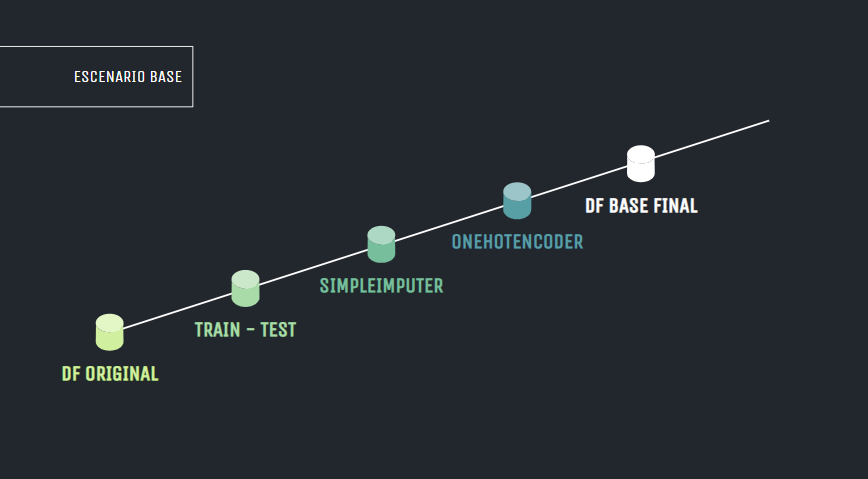

In [25]:
#--Escenario Base--

# 1) Separar la variable target
df_escBase = df.copy()
X_escBase = df_escBase.drop('consumo', axis=1)
y_escBase = df_escBase['consumo']

# 2) Dividir el set de datos de entrenamiento y testeo (70-30)
X_train_escBase, X_test_escBase, y_train_escBase, y_test_escBase = train_test_split(X_escBase, y_escBase, test_size=0.3, random_state=42)

# 3) Imputacion y Encoding
  # Identificar columnas numéricas y categóricas DESPUÉS del split
  # Excluir 'id' de las columnas numéricas que serán transformadas si existe
numerical_cols = X_train_escBase.select_dtypes(include=np.number).columns.tolist()
if 'id' in numerical_cols:
    numerical_cols.remove('id')
categorical_cols = X_train_escBase.select_dtypes(include=['object', 'category']).columns.tolist()

  # Crear preprocesadores para columnas numéricas y categóricas
  # Pipeline numérico: Imputación
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
    ])

  # Pipeline categórico: One-Hot Encoding
categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

  # Combinar preprocesadores usando ColumnTransformer
  # Aplicar las transformaciones a las columnas numéricas y categóricas identificadas
  # 'remainder'='passthrough' mantendrá las columnas no especificadas (como 'id')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ],
    remainder='passthrough'
)

  # Aplicar el preprocesador al conjunto de entrenamiento
  # fit_transform aprende los parámetros del preprocesamiento (como la media para la imputación y las categorías para el encoding) y transforma los datos
X_train_processed = preprocessor.fit_transform(X_train_escBase)

  # Aplicar el preprocesador al conjunto de prueba
  # transform usa los parámetros aprendidos en el conjunto de entrenamiento para transformar los datos de prueba
X_test_processed = preprocessor.transform(X_test_escBase)

  # Obtener nombres de características después del preprocesamiento para crear DataFrames
  # Esto requiere reconstruir los nombres de las columnas después de la transformación
  # Primero, obtener los nombres de las columnas transformadas
transformed_cols = numerical_cols + list(preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols))
  # Luego, añadir las columnas que pasaron directamente ('remainder')
passthrough_cols = [col for col in X_train_escBase.columns if col not in numerical_cols + categorical_cols]
all_feature_names = transformed_cols + passthrough_cols


# 4) Generar los Dataframe para lo modelos
  # Convertir los arrays procesados de vuelta a DataFrames
X_train_final_escBase = pd.DataFrame(X_train_processed, index=X_train_escBase.index, columns=all_feature_names)
X_test_final_escBase = pd.DataFrame(X_test_processed, index=X_test_escBase.index, columns=all_feature_names)


  # Los dataframes y ya están divididos y no necesitan más procesamiento para este escenario
y_train_final_escBase = y_train_escBase
y_test_final_escBase = y_test_escBase


print("Preparación de datos para Escenario Base completa usando pipeline.")
print(f"X_train_final_escBase shape: {X_train_final_escBase.shape}")
print(f"X_test_final_escBase shape: {X_test_final_escBase.shape}")
print(f"y_train_final_escBase shape: {y_train_final_escBase.shape}")
print(f"y_test_final_escBase shape: {y_test_final_escBase.shape}")

print("\nX_train_final_escBase head:")
display(X_train_final_escBase.head())

print("\nX_test_final_escBase head:")
display(X_test_final_escBase.head())


Preparación de datos para Escenario Base completa usando pipeline.
X_train_final_escBase shape: (53029, 128)
X_test_final_escBase shape: (22728, 128)
y_train_final_escBase shape: (53029,)
y_test_final_escBase shape: (22728,)

X_train_final_escBase head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,enero_temp_min,enero_temp_promedio,enero_temp_max,febrero_temp_min,febrero_temp_promedio,...,tipo_instalacion_Retail_Uncategorized,tipo_instalacion_Retail_Vehicle_dealership_showroom,tipo_instalacion_Service_Drycleaning_or_Laundry,tipo_instalacion_Service_Uncategorized,tipo_instalacion_Service_Vehicle_service_repair_shop,tipo_instalacion_Warehouse_Distribution_or_Shipping_center,tipo_instalacion_Warehouse_Nonrefrigerated,tipo_instalacion_Warehouse_Refrigerated,tipo_instalacion_Warehouse_Selfstorage,tipo_instalacion_Warehouse_Uncategorized
13184,6.0,8054.69,1959.0,61.0,198.1,-18.89,-3.80,10.00,-16.67,-1.27,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18163,2.0,53405.94,1990.0,86.0,15.2,-10.56,2.96,16.67,-6.67,4.93,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
74041,6.0,6521.79,1979.0,9.0,26.5,-2.22,6.36,13.33,1.11,8.71,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16247,1.0,263652.40,1970.0,70.0,42.7,-14.44,-1.29,11.67,-9.44,2.24,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50301,5.0,5384.66,1928.0,54.0,25.6,-13.33,-1.19,13.33,-16.67,-4.47,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



X_test_final_escBase head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,enero_temp_min,enero_temp_promedio,enero_temp_max,febrero_temp_min,febrero_temp_promedio,...,tipo_instalacion_Retail_Uncategorized,tipo_instalacion_Retail_Vehicle_dealership_showroom,tipo_instalacion_Service_Drycleaning_or_Laundry,tipo_instalacion_Service_Uncategorized,tipo_instalacion_Service_Vehicle_service_repair_shop,tipo_instalacion_Warehouse_Distribution_or_Shipping_center,tipo_instalacion_Warehouse_Nonrefrigerated,tipo_instalacion_Warehouse_Refrigerated,tipo_instalacion_Warehouse_Selfstorage,tipo_instalacion_Warehouse_Uncategorized
29922,3.0,23674.38,1990.0,61.09609,15.2,-11.67,1.71,16.11,-8.33,1.06,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
55120,6.0,6362.00,1928.0,97.00000,3.4,-11.67,1.36,15.00,-18.33,3.17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
52830,6.0,9636.27,1941.0,65.00000,10.7,-11.67,1.36,15.00,-18.33,3.17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47809,5.0,21547.74,1957.0,78.00000,21.3,-13.33,-1.19,13.33,-16.67,-4.47,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4663,6.0,1211.46,1931.0,86.00000,2.4,2.78,11.50,16.67,5.56,13.86,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## ESCENARIO 1

DESCRIPCION:

* Datos escalados con 'StandardScaler'.
* Todas las features.
* Imputacion de valores faltantes mediante 'SimpleImputer'
* Encoding de variables categoricas mediante 'OneHotEncoder'

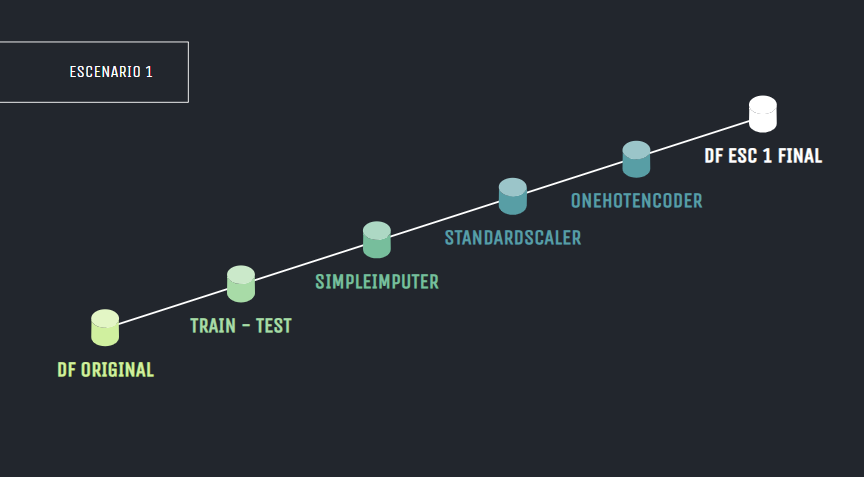

In [26]:
#--Escenario 1--

# 1) Separar la variable target
df_esc1 = df.copy()
# X_esc1 = df_esc1.drop('consumo', axis=1)
# y_esc1 = df_esc1['consumo']

# # 2) Dividir el set de datos de entrenamiento y testeo (70-30)
# X_train_esc1, X_test_esc1, y_train_esc1, y_test_esc1 = train_test_split(X_esc1, y_esc1, test_size=0.3, random_state=42)

#-------------------------
# 2) Dividir el set de datos de entrenamiento y testeo (70-30)
train_esc1, test_esc1 = train_test_split(df_esc1, test_size=0.3, random_state=42)

# 3) Imputacion, Escalado y Encoding
  # Identificar columnas numéricas y categóricas DESPUÉS del split
  # Excluir 'id' de las columnas numéricas que serán transformadas si existe
numerical_cols = train_esc1.select_dtypes(include=np.number).columns.tolist()
if 'id' in numerical_cols:
    numerical_cols.remove('id')
categorical_cols = train_esc1.select_dtypes(include=['object', 'category']).columns.tolist()

  # Crear preprocesadores para columnas numéricas y categóricas
  # Pipeline numérico: Imputación y Escalado
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
    ])

  # Pipeline categórico: One-Hot Encoding
categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

  # Combinar preprocesadores usando ColumnTransformer
  # Aplicar las transformaciones a las columnas numéricas y categóricas identificadas
  # 'remainder'='passthrough' mantendrá las columnas no especificadas (como 'id')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ],
    remainder='passthrough'
)

  # Aplicar el preprocesador al conjunto de entrenamiento
  # fit_transform aprende los parámetros del preprocesamiento (como la media para la imputación, la media y desviación estándar para el escalado y las categorías para el encoding) y transforma los datos
train_processed = preprocessor.fit_transform(train_esc1)

  # Aplicar el preprocesador al conjunto de prueba
  # transform usa los parámetros aprendidos en el conjunto de entrenamiento para transformar los datos de prueba
test_processed = preprocessor.transform(test_esc1)

  # Obtener nombres de características después del preprocesamiento para crear DataFrames
  # Esto requiere reconstruir los nombres de las columnas después de la transformación
  # Primero, obtener los nombres de las columnas transformadas
transformed_cols = numerical_cols + list(preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols))
  # Luego, añadir las columnas que pasaron directamente ('remainder')
passthrough_cols = [col for col in train_esc1.columns if col not in numerical_cols + categorical_cols]
all_feature_names = transformed_cols + passthrough_cols


# 4) Generar los Dataframe para lo modelos
  # Convertir los arrays procesados de vuelta a DataFrames
train_final_esc1 = pd.DataFrame(train_processed, index=train_esc1.index, columns=all_feature_names)
test_final_esc1 = pd.DataFrame(test_processed, index=test_esc1.index, columns=all_feature_names)

# 5) Separar la variable target
X_train_final_esc1 = train_final_esc1.drop('consumo', axis=1)
y_train_final_esc1 = train_final_esc1['consumo']

X_test_final_esc1 = test_final_esc1.drop('consumo', axis=1)
y_test_final_esc1 = test_final_esc1['consumo']

  # Los dataframes y ya están divididos y no necesitan más procesamiento para este escenario
# y_train_final_esc1 = y_train_esc1
# y_test_final_esc1 = y_test_esc1


print("Preparación de datos para Escenario 1 completa usando pipeline.")
print(f"X_train_final_esc1 shape: {X_train_final_esc1.shape}")
print(f"X_test_final_esc1 shape: {X_test_final_esc1.shape}")
print(f"y_train_final_esc1 shape: {y_train_final_esc1.shape}")
print(f"y_test_final_esc1 shape: {y_test_final_esc1.shape}")

print("\nX_train_final_esc1 head:")
display(X_train_final_esc1.head())

print("\ny_train_final_esc1 head:")
display(y_train_final_esc1.head())
display(y_train_final_esc1.describe())

print("\nX_test_final_esc1 head:")
display(X_test_final_esc1.head())

Preparación de datos para Escenario 1 completa usando pipeline.
X_train_final_esc1 shape: (53029, 128)
X_test_final_esc1 shape: (22728, 128)
y_train_final_esc1 shape: (53029,)
y_test_final_esc1 shape: (22728,)

X_train_final_esc1 head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,enero_temp_min,enero_temp_promedio,enero_temp_max,febrero_temp_min,febrero_temp_promedio,...,tipo_instalacion_Retail_Uncategorized,tipo_instalacion_Retail_Vehicle_dealership_showroom,tipo_instalacion_Service_Drycleaning_or_Laundry,tipo_instalacion_Service_Uncategorized,tipo_instalacion_Service_Vehicle_service_repair_shop,tipo_instalacion_Warehouse_Distribution_or_Shipping_center,tipo_instalacion_Warehouse_Nonrefrigerated,tipo_instalacion_Warehouse_Refrigerated,tipo_instalacion_Warehouse_Selfstorage,tipo_instalacion_Warehouse_Uncategorized
13184,1.108561,-0.326554,0.182698,-0.004180,2.659445,-1.432769,-1.309383,-1.690125,-0.773749,-0.654066,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18163,-1.604780,1.691065,1.034244,1.083317,-0.406136,0.164327,0.429344,0.551052,0.655523,0.601565,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
74041,1.108561,-0.394751,0.732082,-2.266174,-0.216737,1.763341,1.303852,-0.571217,1.767496,1.367094,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16247,-2.283115,11.044662,0.484859,0.387319,0.054790,-0.579578,-0.663790,-1.128991,0.259614,0.056783,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50301,0.430226,-0.445340,-0.668849,-0.308679,-0.231822,-0.366760,-0.638069,-0.571217,-0.773749,-1.302133,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



y_train_final_esc1 head:


,consumo
13184,-0.234592
18163,-0.352391
74041,-0.500943
16247,0.329295
50301,0.253755


,consumo
count,5.302900e+04
mean,1.271578e-16
std,1.000009e+00
min,-1.385807e+00
25%,-4.769105e-01
50%,-1.269005e-01
75%,2.436477e-01
max,1.552172e+01



X_test_final_esc1 head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,enero_temp_min,enero_temp_promedio,enero_temp_max,febrero_temp_min,febrero_temp_promedio,...,tipo_instalacion_Retail_Uncategorized,tipo_instalacion_Retail_Vehicle_dealership_showroom,tipo_instalacion_Service_Drycleaning_or_Laundry,tipo_instalacion_Service_Uncategorized,tipo_instalacion_Service_Vehicle_service_repair_shop,tipo_instalacion_Warehouse_Distribution_or_Shipping_center,tipo_instalacion_Warehouse_Nonrefrigerated,tipo_instalacion_Warehouse_Refrigerated,tipo_instalacion_Warehouse_Selfstorage,tipo_instalacion_Warehouse_Uncategorized
29922,-0.926445,0.368346,1.034244,-3.090853e-16,-0.406136,-0.048491,0.107834,0.362887,0.418264,-0.182192,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
55120,1.108561,-0.401859,-0.668849,1.561816e+00,-0.603916,-0.048491,0.017811,-0.010082,-1.011009,0.245128,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
52830,1.108561,-0.256191,-0.311749,1.698196e-01,-0.481561,-0.048491,0.017811,-0.010082,-1.011009,0.245128,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47809,0.430226,0.273735,0.127759,7.353182e-01,-0.303894,-0.366760,-0.638069,-0.571217,-0.773749,-1.302133,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4663,1.108561,-0.631000,-0.586441,1.083317e+00,-0.620677,2.721982,2.625902,0.551052,2.403522,2.410078,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## ESCENARIO 2

**Escenerio conservador** donde se tienen en cuenta no solo todas las variables
que se consideran relevantes sino tambien algunas adicionales, no se eliminan registros, se imputan datos faltantes.

DESCRIPCION:

* Datos escalados con _'StandardScaler'_.
* Imputcion de valores faltantes:
  * Se hace la imputacion en las variables 'año_construccion' (por su bajo porcentaje de valor faltantes, **2,4%**) y 'calificacion_energystar' (por su importancia para predecir la variable target, **-0,51 de correlacion**).
* Variables categoricas:
  * Eliminacion de 'clase_edificio', la informacion esta contemplada en 'tipo_instalacion'.
  * La variable 'tipo_instalacion' se agrupa en los siguientes rubros:
    * Residential: 57.16%
    * Office: 17.36%
    * Education: 7.57%
    * Warehouse/Industrial: 4.30%
    * Service: 3.29%
    * Retail: 2.58%
    * Other/Unknown: 2.56%
    * Public Assembly: 2.16%
    * Health Care: 1.74%
    * Mixed Use: 1.23%
   
  * Codificadas con metodo _'OneHotEncoder'_
* Variables de temperatura por mes:
  * Eliminacion de todas las 'nombreMes_temp_promedio', se conservan solo los minimos y maximos de cada mes, con esta informacion ya se esta contemplando el promedio.
* Variables meteorologicas:
  * Eliminacion de las 3 variables asociadas al viento ('direccion_velocidad_viento_maxima', 'direccion_velocidad_viento_pico' y 'velocidad_viento_maxima') y la de niebla ('dias_con_niebla'), por el gran procentaje de valores faltantes, **>50%**.


  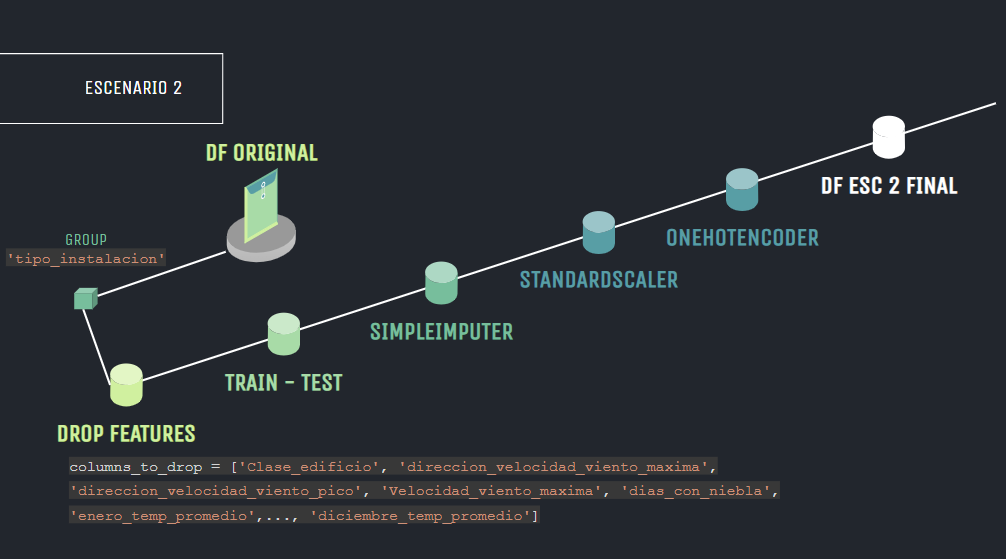

In [27]:
#--Escenario 2--

# Define a mapping from detailed facility types to broader categories
facility_type_mapping = {
    '5plus_Unit_Building': 'Residential',
    'Multifamily_Uncategorized': 'Residential',
    '2to4_Unit_Building': 'Residential',
    'Lodging_Dormitory_or_fraternity_sorority': 'Residential',
    'Office_Uncategorized': 'Office',
    'Office_Medical_non_diagnostic': 'Office',
    'Office_Bank_or_other_financial': 'Office',
    'Office_Mixed_use': 'Office',
    'Retail_Enclosed_mall': 'Retail',
    'Retail_Vehicle_dealership_showroom': 'Retail',
    'Retail_Uncategorized': 'Retail',
    'Retail_Strip_shopping_mall': 'Retail',
    'Food_Sales': 'Retail',
    'Grocery_store_or_food_market': 'Retail',
    'Warehouse_Distribution_or_Shipping_center': 'Warehouse/Industrial',
    'Warehouse_Nonrefrigerated': 'Warehouse/Industrial',
    'Warehouse_Selfstorage': 'Warehouse/Industrial',
    'Industrial': 'Warehouse/Industrial',
    'Warehouse_Refrigerated': 'Warehouse/Industrial',
    'Warehouse_Uncategorized': 'Warehouse/Industrial',
    'Education_Other_classroom': 'Education',
    'Education_College_or_university': 'Education',
    'Education_Uncategorized': 'Education',
    'Education_Preschool_or_daycare': 'Education',
    'Public_Assembly_Entertainment_culture': 'Public Assembly',
    'Public_Assembly_Drama_theater': 'Public Assembly',
    'Public_Assembly_Social_meeting': 'Public Assembly',
    'Religious_worship': 'Public Assembly',
    'Parking_Garage': 'Public Assembly',
    'Public_Assembly_Recreation': 'Public Assembly',
    'Public_Assembly_Movie_Theater': 'Public Assembly',
    'Public_Assembly_Uncategorized': 'Public Assembly',
    'Public_Assembly_Library': 'Public Assembly',
    'Public_Safety_Uncategorized': 'Public Assembly',
    'Public_Safety_Fire_or_police_station': 'Public Assembly',
    'Public_Assembly_Other': 'Public Assembly',
    'Public_Safety_Penitentiary': 'Public Assembly',
    'Public_Safety_Courthouse': 'Public Assembly',
    'Public_Assembly_Stadium': 'Public Assembly',
    'Health_Care_Inpatient': 'Health Care',
    'Health_Care_Uncategorized': 'Health Care',
    'Health_Care_Outpatient_Clinic': 'Health Care',
    'Health_Care_Outpatient_Uncategorized': 'Health Care',
    'Nursing_Home': 'Health Care',
    'Service_Vehicle_service_repair_shop': 'Service',
    'Service_Drycleaning_or_Laundry': 'Service',
    'Service_Uncategorized': 'Service',
    'Food_Service_Uncategorized': 'Service',
    'Food_Service_Other': 'Service',
    'Food_Service_Restaurant_or_cafeteria': 'Service',
    'Lodging_Hotel': 'Service', # Could also be Lodging, but grouping with service for simplicity
    'Lodging_Other': 'Service',
    'Lodging_Uncategorized': 'Service',
    'Mixed_Use_Predominantly_Commercial': 'Mixed Use',
    'Mixed_Use_Commercial_and_Residential': 'Mixed Use',
    'Mixed_Use_Predominantly_Residential': 'Mixed Use',
    'Commercial_Other': 'Other/Unknown',
    'Commercial_Unknown': 'Other/Unknown',
    'Laboratory': 'Other/Unknown' # Assuming Laboratory is not a major category
}

# 1) Copia del dataframe original
df_esc2 = df.copy()

# Apply the mapping to create a new grouped column
df_esc2['tipo_instalacion_agrupado'] = df_esc2['tipo_instalacion'].map(facility_type_mapping)


# Apply eliminaciones y selecciones ANTES de separar X e y
# Eliminar columnas especificadas, including the original 'tipo_instalacion'
columns_to_drop = [
    'clase_edificio',
    'direccion_velocidad_viento_maxima',
    'direccion_velocidad_viento_pico',
    'velocidad_viento_maxima',
    'dias_con_niebla',
    'enero_temp_promedio', 'febrero_temp_promedio', 'marzo_temp_promedio',
    'abril_temp_promedio', 'mayo_temp_promedio', 'junio_temp_promedio',
    'julio_temp_promedio', 'agosto_temp_promedio', 'septiembre_temp_promedio',
    'octubre_temp_promedio', 'noviembre_temp_promedio', 'diciembre_temp_promedio',
    'tipo_instalacion' # Add the original column to drop
]
df_esc2 = df_esc2.drop(columns=columns_to_drop, errors='ignore') # Use errors='ignore' to avoid errors if a column is already dropped or not present

# 2) Separar la variable target
# X_esc2 = df_esc2.drop('consumo', axis=1)
# y_esc2 = df_esc2['consumo']

# 3) Dividir el set de datos de entrenamiento y testeo (70-30)
#X_train_esc2, X_test_esc2, y_train_esc2, y_test_esc2 = train_test_split(X_esc2, y_esc2, test_size=0.3, random_state=42)
train_esc2, test_esc2 = train_test_split(df_esc2, test_size=0.3, random_state=42)

# 3) Imputacion, Escalado y Encoding
  # Identificar columnas numéricas and categóricas DESPUÉS del split
  # Excluir 'id' de las columnas numéricas que serán transformadas si existe
numerical_cols = train_esc2.select_dtypes(include=np.number).columns.tolist()
if 'id' in numerical_cols:
    numerical_cols.remove('id')
# Update categorical_cols to include the new grouped column
categorical_cols = train_esc2.select_dtypes(include=['object', 'category']).columns.tolist()


  # Crear preprocesadores para columnas numéricas y categóricas
  # Pipeline numérico: Imputación y Escalado
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Use mean imputation for all numerical columns
    ('scaler', StandardScaler())
    ])

  # Pipeline categórico: One-Hot Encoding
categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

  # Combinar preprocesadores usando ColumnTransformer
  # Apply the numerical pipeline to all identified numerical columns
  # Apply the categorical pipeline to all identified categorical columns
  # 'remainder'='passthrough' will keep the unspecified columns (like 'id')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_cols), # Apply numerical pipeline to all numerical columns
        ('cat', categorical_pipeline, categorical_cols)
    ],
    remainder='passthrough' # Keep non-specified columns
)


  # Aplicar el preprocesador al conjunto de entrenamiento
  # fit_transform aprende los parámetros del preprocesamiento (como la media para la imputación, la media y desviación estándar para el escalado y las categorías para el encoding) y transforma los datos
train_processed = preprocessor.fit_transform(train_esc2)

  # Aplicar el preprocesador al conjunto de prueba
  # transform usa los parámetros aprendidos en el conjunto de entrenamiento para transformar los datos de prueba
test_processed = preprocessor.transform(test_esc2)

  # Obtener nombres de características después del preprocesamiento para crear DataFrames
  # Esto requires reconstructing the column names after the transformation
  # First, get the names of the transformed columns from the numerical pipeline
transformed_cols = numerical_cols
  # Add the names from the one-hot encoder
transformed_cols += list(preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols))
  # Then, add the columns that passed directly ('remainder')
passthrough_cols = [col for col in train_esc2.columns if col not in numerical_cols + categorical_cols]
all_feature_names = transformed_cols + passthrough_cols


# 4) Generar los Dataframe para lo modelos
  # Convertir los arrays procesados de vuelta a DataFrames
train_final_esc2 = pd.DataFrame(train_processed, index=train_esc2.index, columns=all_feature_names)
test_final_esc2 = pd.DataFrame(test_processed, index=test_esc2.index, columns=all_feature_names)

# 5) Separar la variable target
X_train_final_esc2 = train_final_esc2.drop('consumo', axis=1)
y_train_final_esc2 = train_final_esc2['consumo']

X_test_final_esc2 = test_final_esc2.drop('consumo', axis=1)
y_test_final_esc2 = test_final_esc2['consumo']

  # Los dataframes y ya están divididos y no necesitan más procesamiento para este escenario
# y_train_final_esc2 = y_train_esc2
# y_test_final_esc2 = y_test_esc2


print("Preparación de datos para Escenario 2 completa usando pipeline.")
print(f"X_train_final_esc2 shape: {X_train_final_esc2.shape}")
print(f"X_test_final_esc2 shape: {X_test_final_esc2.shape}")
print(f"y_train_final_esc2 shape: {y_train_final_esc2.shape}")
print(f"y_test_final_esc2 shape: {y_test_final_esc2.shape}")

print("\nX_train_final_esc2 head:")
display(X_train_final_esc2.head())

print("\nX_test_final_esc2 head:")
display(X_test_final_esc2.head())

Preparación de datos para Escenario 2 completa usando pipeline.
X_train_final_esc2 shape: (53029, 61)
X_test_final_esc2 shape: (22728, 61)
y_train_final_esc2 shape: (53029,)
y_test_final_esc2 shape: (22728,)

X_train_final_esc2 head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,enero_temp_min,enero_temp_max,febrero_temp_min,febrero_temp_max,marzo_temp_min,...,tipo_instalacion_agrupado_Health Care,tipo_instalacion_agrupado_Mixed Use,tipo_instalacion_agrupado_Office,tipo_instalacion_agrupado_Other/Unknown,tipo_instalacion_agrupado_Public Assembly,tipo_instalacion_agrupado_Residential,tipo_instalacion_agrupado_Retail,tipo_instalacion_agrupado_Service,tipo_instalacion_agrupado_Warehouse/Industrial,tipo_instalacion_agrupado_nan
13184,1.108561,-0.326554,0.182698,-0.004180,2.659445,-1.432769,-1.690125,-0.773749,0.773166,-0.959667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18163,-1.604780,1.691065,1.034244,1.083317,-0.406136,0.164327,0.551052,0.655523,0.419016,0.337433,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
74041,1.108561,-0.394751,0.732082,-2.266174,-0.216737,1.763341,-0.571217,1.767496,0.655827,1.336309,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
16247,-2.283115,11.044662,0.484859,0.387319,0.054790,-0.579578,-1.128991,0.259614,1.009976,-0.162004,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50301,0.430226,-0.445340,-0.668849,-0.308679,-0.231822,-0.366760,-0.571217,-0.773749,-1.833885,-0.959667,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0



X_test_final_esc2 head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,enero_temp_min,enero_temp_max,febrero_temp_min,febrero_temp_max,marzo_temp_min,...,tipo_instalacion_agrupado_Health Care,tipo_instalacion_agrupado_Mixed Use,tipo_instalacion_agrupado_Office,tipo_instalacion_agrupado_Other/Unknown,tipo_instalacion_agrupado_Public Assembly,tipo_instalacion_agrupado_Residential,tipo_instalacion_agrupado_Retail,tipo_instalacion_agrupado_Service,tipo_instalacion_agrupado_Warehouse/Industrial,tipo_instalacion_agrupado_nan
29922,-0.926445,0.368346,1.034244,-3.090853e-16,-0.406136,-0.048491,0.362887,0.418264,-0.410887,0.536849,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
55120,1.108561,-0.401859,-0.668849,1.561816e+00,-0.603916,-0.048491,-0.010082,-1.011009,0.299544,0.438040,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
52830,1.108561,-0.256191,-0.311749,1.698196e-01,-0.481561,-0.048491,-0.010082,-1.011009,0.299544,0.438040,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
47809,0.430226,0.273735,0.127759,7.353182e-01,-0.303894,-0.366760,-0.571217,-0.773749,-1.833885,-0.959667,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4663,1.108561,-0.631000,-0.586441,1.083317e+00,-0.620677,2.721982,0.551052,2.403522,1.959352,2.532803,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## ESCENARIO 3

**Escenerio arriesgado** donde solo se tienen en cuenta las variables que se consideran relevantes, se eliminan registros que se consideran que pueden afectar al modelo, no se imputan datos faltantes para no agregar informacion estimada al data set.

DESCRIPCION:

* Datos escalados con _'StandardScaler'_.
* Valores faltantes:
  * En aquellas variables que contengan datos faltantes, se elimina directamente el registro, para no introducir error en el set de datos.
* Variables categoricas:
  * Eliminacion de 'clase_edificio', la informacion esta contemplada en 'tipo_instalacion'.
  * La variable 'tipo_instalacion' se agrupa en los siguientes rubros:
      * Residential: 57.16%
      * Office: 17.36%
      * Education: 7.57%
      * Warehouse/Industrial: 4.30%
      * Service: 3.29%
      * Retail: 2.58%
      * Other/Unknown: 2.56%
      * Public Assembly: 2.16%
      * Health Care: 1.74%
      * Mixed Use: 1.23%
* Variables de temperatura:
  * Solo se considera 'temperatura_promedio'.
* Variables meteorologicas:
  * Eliminacion de las 3 variables asociadas al viento ('direccion_velocidad_viento_maxima', 'direccion_velocidad_viento_pico' y 'velocidad_viento_maxima') y la de niebla ('dias_con_niebla'), por el gran procentaje de valores faltantes, **>50%**.


  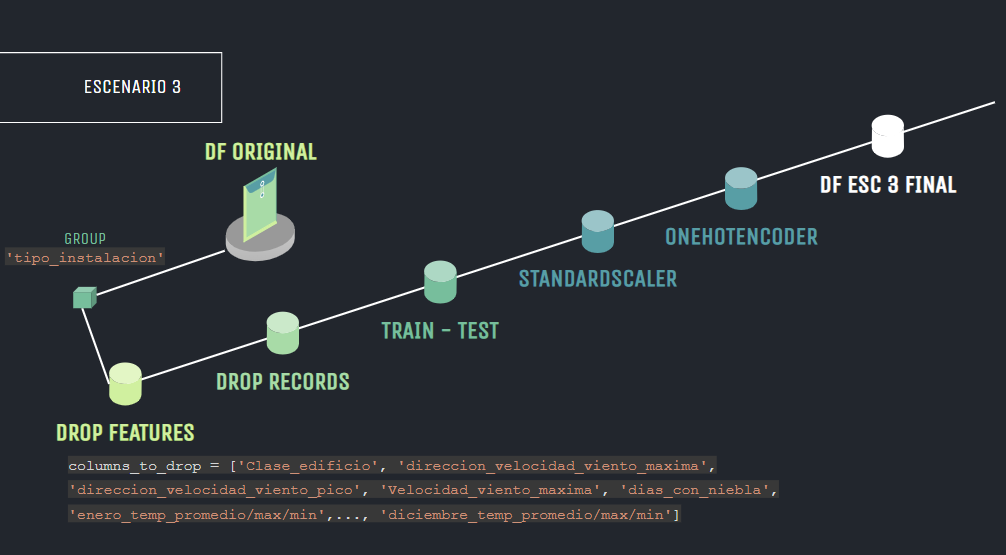

In [28]:
#--Escenario 3--

# Define a mapping from detailed facility types to broader categories
facility_type_mapping = {
    '5plus_Unit_Building': 'Residential',
    'Multifamily_Uncategorized': 'Residential',
    '2to4_Unit_Building': 'Residential',
    'Lodging_Dormitory_or_fraternity_sorority': 'Residential',
    'Office_Uncategorized': 'Office',
    'Office_Medical_non_diagnostic': 'Office',
    'Office_Bank_or_other_financial': 'Office',
    'Office_Mixed_use': 'Office',
    'Retail_Enclosed_mall': 'Retail',
    'Retail_Vehicle_dealership_showroom': 'Retail',
    'Retail_Uncategorized': 'Retail',
    'Retail_Strip_shopping_mall': 'Retail',
    'Food_Sales': 'Retail',
    'Grocery_store_or_food_market': 'Retail',
    'Warehouse_Distribution_or_Shipping_center': 'Warehouse/Industrial',
    'Warehouse_Nonrefrigerated': 'Warehouse/Industrial',
    'Warehouse_Selfstorage': 'Warehouse/Industrial',
    'Industrial': 'Warehouse/Industrial',
    'Warehouse_Refrigerated': 'Warehouse/Industrial',
    'Warehouse_Uncategorized': 'Warehouse/Industrial',
    'Education_Other_classroom': 'Education',
    'Education_College_or_university': 'Education',
    'Education_Uncategorized': 'Education',
    'Education_Preschool_or_daycare': 'Education',
    'Public_Assembly_Entertainment_culture': 'Public Assembly',
    'Public_Assembly_Drama_theater': 'Public Assembly',
    'Public_Assembly_Social_meeting': 'Public Assembly',
    'Religious_worship': 'Public Assembly',
    'Parking_Garage': 'Public Assembly',
    'Public_Assembly_Recreation': 'Public Assembly',
    'Public_Assembly_Movie_Theater': 'Public Assembly',
    'Public_Assembly_Uncategorized': 'Public Assembly',
    'Public_Assembly_Library': 'Public Assembly',
    'Public_Safety_Uncategorized': 'Public Assembly',
    'Public_Safety_Fire_or_police_station': 'Public Assembly',
    'Public_Assembly_Other': 'Public Assembly',
    'Public_Safety_Penitentiary': 'Public Assembly',
    'Public_Safety_Courthouse': 'Public Assembly',
    'Public_Assembly_Stadium': 'Public Assembly',
    'Health_Care_Inpatient': 'Health Care',
    'Health_Care_Uncategorized': 'Health Care',
    'Health_Care_Outpatient_Clinic': 'Health Care',
    'Health_Care_Outpatient_Uncategorized': 'Health Care',
    'Nursing_Home': 'Health Care',
    'Service_Vehicle_service_repair_shop': 'Service',
    'Service_Drycleaning_or_Laundry': 'Service',
    'Service_Uncategorized': 'Service',
    'Food_Service_Uncategorized': 'Service',
    'Food_Service_Other': 'Service',
    'Food_Service_Restaurant_or_cafeteria': 'Service',
    'Lodging_Hotel': 'Service', # Could also be Lodging, but grouping with service for simplicity
    'Lodging_Other': 'Service',
    'Lodging_Uncategorized': 'Service',
    'Mixed_Use_Predominantly_Commercial': 'Mixed Use',
    'Mixed_Use_Commercial_and_Residential': 'Mixed Use',
    'Mixed_Use_Predominantly_Residential': 'Mixed Use',
    'Commercial_Other': 'Other/Unknown',
    'Commercial_Unknown': 'Other/Unknown',
    'Laboratory': 'Other/Unknown' # Assuming Laboratory is not a major category
}

# 1) Copia del dataframe original
df_esc3 = df.copy()

# Apply the mapping to create a new grouped column
df_esc3['tipo_instalacion_agrupado'] = df_esc3['tipo_instalacion'].map(facility_type_mapping)

# Aplicar eliminaciones iniciales de columnas según descripción, including original 'tipo_instalacion'
columns_to_drop_initial = [
    'clase_edificio',
    'direccion_velocidad_viento_maxima',
    'direccion_velocidad_viento_pico',
    'velocidad_viento_maxima',
    'dias_con_niebla',
    'tipo_instalacion' # Add original column to drop
]
df_esc3 = df_esc3.drop(columns=columns_to_drop_initial, errors='ignore')

# Seleccionar solo 'temperatura_promedio' de las columnas de temperatura
temp_cols = [col for col in df_esc3.columns if 'temp' in col]
temp_cols_to_drop = [col for col in temp_cols if col != 'temperatura_promedio']
df_esc3 = df_esc3.drop(columns=temp_cols_to_drop, errors='ignore')

# Eliminar filas con valores faltantes
df_esc3.dropna(inplace=True)

# 2) Separar la variable target
# X_esc3 = df_esc3.drop('consumo', axis=1)
# y_esc3 = df_esc3['consumo']

# 3) Dividir el set de datos de entrenamiento y testeo (70-30)
#X_train_esc3, X_test_esc3, y_train_esc3, y_test_esc3 = train_test_split(X_esc3, y_esc3, test_size=0.3, random_state=42)
train_esc3, test_esc3 = train_test_split(df_esc3, test_size=0.3, random_state=42)

# 4) Escalado y Codificación
  # Identificar columnas numéricas y categóricas DESPUÉS de eliminar NaNs y dividir
  # Excluir 'id' de las columnas numéricas que serán transformadas si existe
numerical_cols = train_esc3.select_dtypes(include=np.number).columns.tolist()
if 'id' in numerical_cols:
    numerical_cols.remove('id')
# Update categorical_cols to include the new grouped column
categorical_cols = train_esc3.select_dtypes(include=['object', 'category']).columns.tolist()

  # Crear preprocesadores para columnas numéricas y categóricas
  # Pipeline numérico: Escalado
numerical_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
    ])

  # Pipeline categórico: Codificación One-Hot
categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

  # Combinar preprocesadores usando ColumnTransformer
  # Aplicar transformaciones a las columnas numéricas y categóricas identificadas
  # 'remainder'='passthrough' mantendrá las columnas no especificadas (como 'id')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ],
    remainder='passthrough'
)

  # Aplicar el preprocesador al conjunto de entrenamiento
  # fit_transform aprende los parámetros de preprocesamiento y transforma los datos
train_processed = preprocessor.fit_transform(train_esc3)

  # Aplicar el preprocesador al conjunto de prueba
  # transform usa los parámetros aprendidos del conjunto de entrenamiento
test_processed = preprocessor.transform(test_esc3)

  # Obtener nombres de características después del preprocesamiento para crear DataFrames
  # Reconstruir nombres de columnas después de la transformación
  # Primero, obtener nombres de columnas transformadas del pipeline numérico
transformed_cols = numerical_cols
  # Agregar nombres del codificador one-hot
transformed_cols += list(preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols))
  # Luego, agregar las columnas que pasaron directamente ('remainder')
passthrough_cols = [col for col in train_esc3.columns if col not in numerical_cols + categorical_cols]
all_feature_names = transformed_cols + passthrough_cols


# 5) Generar DataFrames para los modelos
  # Convertir los arrays procesados de vuelta a DataFrames
train_final_esc3 = pd.DataFrame(train_processed, index=train_esc3.index, columns=all_feature_names)
test_final_esc3 = pd.DataFrame(test_processed, index=test_esc3.index, columns=all_feature_names)

# 6) Separar la variable target
X_train_final_esc3 = train_final_esc3.drop('consumo', axis=1)
y_train_final_esc3 = train_final_esc3['consumo']

X_test_final_esc3 = test_final_esc3.drop('consumo', axis=1)
y_test_final_esc3 = test_final_esc3['consumo']

  # Los dataframes y ya están divididos y no necesitan más procesamiento para este escenario
# y_train_final_esc3 = y_train_esc3
# y_test_final_esc3 = y_test_esc3


print("Preparación de datos para Escenario 3 completa usando pipeline.")
print(f"X_train_final_esc3 shape: {X_train_final_esc3.shape}")
print(f"X_test_final_esc3 shape: {X_test_final_esc3.shape}")
print(f"y_train_final_esc3 shape: {y_train_final_esc3.shape}")
print(f"y_test_final_esc3 shape: {y_test_final_esc3.shape}")

print("\nX_train_final_esc3 head:")
display(X_train_final_esc3.head())

print("\nX_test_final_esc3 head:")
display(X_test_final_esc3.head())

Preparación de datos para Escenario 3 completa usando pipeline.
X_train_final_esc3 shape: (33905, 35)
X_test_final_esc3 shape: (14531, 35)
y_train_final_esc3 shape: (33905,)
y_test_final_esc3 shape: (14531,)

X_train_final_esc3 head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,grados_dia_enfriamiento,grados_dia_calefaccion,precipitacion_mm,nevada_mm,profundidad_nieve_mm,...,tipo_instalacion_agrupado_Education,tipo_instalacion_agrupado_Health Care,tipo_instalacion_agrupado_Mixed Use,tipo_instalacion_agrupado_Office,tipo_instalacion_agrupado_Other/Unknown,tipo_instalacion_agrupado_Public Assembly,tipo_instalacion_agrupado_Residential,tipo_instalacion_agrupado_Retail,tipo_instalacion_agrupado_Service,tipo_instalacion_agrupado_Warehouse/Industrial
66712,-0.655464,2.345326,1.346182,0.558221,0.933717,0.564613,0.289031,0.569796,0.552846,-0.441244,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3332,-0.655464,-0.574636,-0.341536,0.208885,-0.577889,-1.695023,-3.544400,-2.130728,-1.799317,-1.097462,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
16045,-3.042265,0.515004,-0.673966,0.208885,0.012692,0.309803,-0.051909,2.872874,0.698111,1.207572,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2033,-1.451064,-0.646742,-0.929681,0.977425,-0.577889,-2.161374,-1.551309,-3.717635,-1.799317,-1.097462,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
58499,0.935737,-0.565264,-0.648394,0.558221,0.012692,0.689614,-0.153335,-0.068614,0.212034,-0.540504,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



X_test_final_esc3 head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,grados_dia_enfriamiento,grados_dia_calefaccion,precipitacion_mm,nevada_mm,profundidad_nieve_mm,...,tipo_instalacion_agrupado_Education,tipo_instalacion_agrupado_Health Care,tipo_instalacion_agrupado_Mixed Use,tipo_instalacion_agrupado_Office,tipo_instalacion_agrupado_Other/Unknown,tipo_instalacion_agrupado_Public Assembly,tipo_instalacion_agrupado_Residential,tipo_instalacion_agrupado_Retail,tipo_instalacion_agrupado_Service,tipo_instalacion_agrupado_Warehouse/Industrial
54238,0.935737,-0.415633,-0.443822,-1.502863,-0.678077,0.689614,-0.153335,-0.068614,0.212034,-0.540504,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
36820,-0.655464,-0.241566,0.144322,0.697956,0.012692,-0.178182,0.607974,1.046924,0.994226,0.981480,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
51176,0.140136,-0.440879,-0.750680,-2.026868,-0.470671,0.910770,0.100842,-0.183816,0.943942,1.455722,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2064,-1.451064,-0.638945,-1.313253,1.221960,-0.577889,-2.161374,-1.551309,-3.717635,-1.799317,-1.097462,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9552,0.935737,0.767691,0.988181,1.047292,-0.685108,0.884328,-0.292644,-0.553422,-0.123191,-0.755567,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
print("Columnas en el DataFrame de Escenario 3:")
print(X_train_final_esc3.columns.tolist())

Columnas en el DataFrame de Escenario 3:
['factor_año', 'area_edificio', 'año_construccion', 'calificacion_energystar', 'elevacion', 'grados_dia_enfriamiento', 'grados_dia_calefaccion', 'precipitacion_mm', 'nevada_mm', 'profundidad_nieve_mm', 'dias_menos_1C', 'dias_menos_6C', 'dias_menos_12C', 'dias_menos_18C', 'dias_mas_27C', 'dias_mas_32C', 'dias_mas_38C', 'dias_mas_43C', 'factor_estado_State_1', 'factor_estado_State_10', 'factor_estado_State_11', 'factor_estado_State_2', 'factor_estado_State_4', 'factor_estado_State_6', 'factor_estado_State_8', 'tipo_instalacion_agrupado_Education', 'tipo_instalacion_agrupado_Health Care', 'tipo_instalacion_agrupado_Mixed Use', 'tipo_instalacion_agrupado_Office', 'tipo_instalacion_agrupado_Other/Unknown', 'tipo_instalacion_agrupado_Public Assembly', 'tipo_instalacion_agrupado_Residential', 'tipo_instalacion_agrupado_Retail', 'tipo_instalacion_agrupado_Service', 'tipo_instalacion_agrupado_Warehouse/Industrial']


## ESCENARIO 4

DESCRIPCION:

+ Eliminación de las variables climaticas
 + Variables relacionadas a viento y niebla
 + Variables de rango de temperatura, quitando minimo y maximo para solo conservar promedio por mes
+ Se descarta la variable "tipo de instalación" preeviendo que su informacion este correctamtente representada en la variables "clase de edificio"
+ La implementacion de un pipeline que impute los datos faltantes con "_IterativeImputer_" con un máximo de 100 iteraciones y luego escale los datos con "_StandardScaler_".

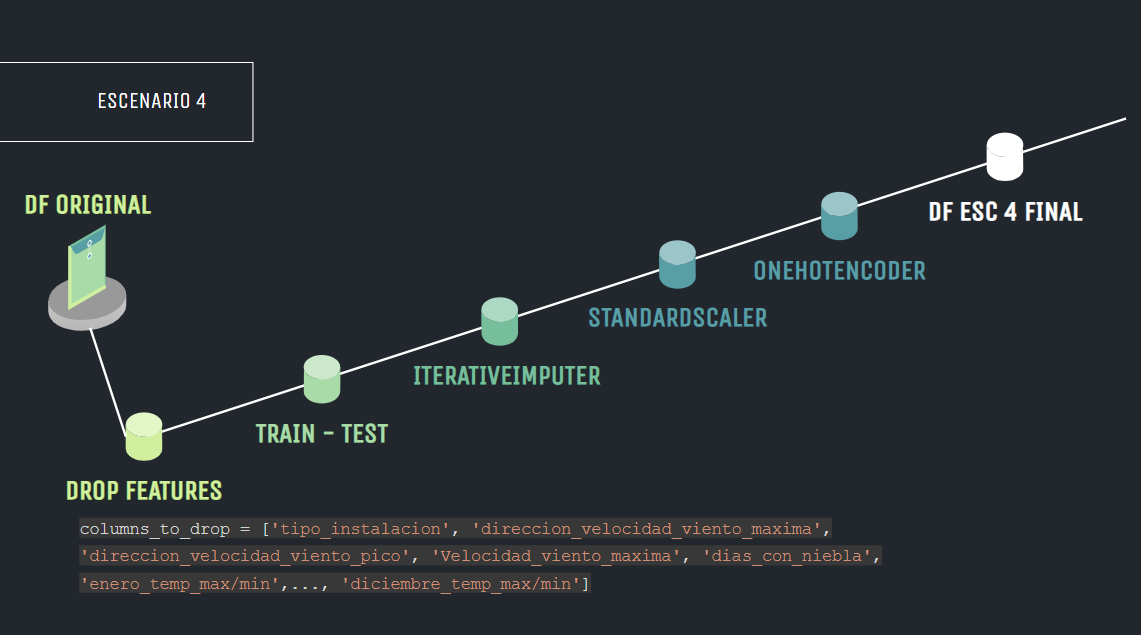

In [30]:
# Step 0: Copy df
df_esc4 = df.copy()

# Step 1: Drop unwanted columns
temp_cols_to_drop = [col for col in df_esc4.columns if ('_temp_min' in col or '_temp_max' in col)]
wind_fog_cols_to_drop = [col for col in df_esc4.columns if ('viento' in col or 'niebla' in col)]

df_esc4 = df_esc4.drop(columns=temp_cols_to_drop + wind_fog_cols_to_drop + ['tipo_instalacion'], errors='ignore')

# Step 2: Separate target
# X_esc4 = df_esc4.drop(columns=['consumo'])
# y_esc4 = df_esc4['consumo']

# Step 3: Train/test split before anything else
train_esc4, test_esc4 = train_test_split(df_esc4, test_size=0.3, random_state=42)

# Step 4: Separate column types AFTER the split
numerical_cols = train_esc4.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_esc4.select_dtypes(include=['object', 'category']).columns.tolist()

# Step 5: Create preprocessors for numerical and categorical columns
# Numerical pipeline: Impute + Scale
numerical_pipeline = Pipeline(steps=[
    ('imputer', IterativeImputer(max_iter=100, random_state=0)),
    ('scaler', StandardScaler())
])

# Categorical pipeline: One-Hot Encoding
categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessors using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ],
    remainder='passthrough' # Keep non-specified columns
)

# Step 6: Apply the preprocessor to the training and test sets
train_processed = preprocessor.fit_transform(train_esc4)
test_processed = preprocessor.transform(test_esc4)

# Step 7: Get feature names after preprocessing to create DataFrames
transformed_cols = numerical_cols + list(preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols))
passthrough_cols = [col for col in train_esc4.columns if col not in numerical_cols + categorical_cols]
all_feature_names = transformed_cols + passthrough_cols

# Step 8: Generate DataFrames for the models
train_final_esc4 = pd.DataFrame(train_processed, index=train_esc4.index, columns=all_feature_names)
test_final_esc4 = pd.DataFrame(test_processed, index=test_esc4.index, columns=all_feature_names)

# Step 9: Separate target
X_train_final_esc4 = train_final_esc4.drop(columns=['consumo'])
y_train_final_esc4 = train_final_esc4['consumo']

X_test_final_esc4 = test_final_esc4.drop(columns=['consumo'])
y_test_final_esc4 = test_final_esc4['consumo']

# Assign target variables to match scenario naming convention
# y_train_final_esc4 = y_train_esc4
# y_test_final_esc4 = y_test_esc4

# Optional: check the shape
print("Preparación de datos para Escenario 4 completa usando pipeline.")
print(f"X_train_final_esc4 shape: {X_train_final_esc4.shape}")
print(f"X_test_final_esc4 shape: {X_test_final_esc4.shape}")
print(f"y_train_final_esc4 shape: {y_train_final_esc4.shape}")
print(f"y_test_final_esc4 shape: {y_test_final_esc4.shape}")

print("\nX_train_final_esc4 head:")
display(X_train_final_esc4.head())

print("\nX_test_final_esc4 head:")
display(X_test_final_esc4.head())

Preparación de datos para Escenario 4 completa usando pipeline.
X_train_final_esc4 shape: (53029, 40)
X_test_final_esc4 shape: (22728, 40)
y_train_final_esc4 shape: (53029,)
y_test_final_esc4 shape: (22728,)

X_train_final_esc4 head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,enero_temp_promedio,febrero_temp_promedio,marzo_temp_promedio,abril_temp_promedio,mayo_temp_promedio,...,dias_mas_43C,factor_estado_State_1,factor_estado_State_10,factor_estado_State_11,factor_estado_State_2,factor_estado_State_4,factor_estado_State_6,factor_estado_State_8,clase_edificio_Commercial,clase_edificio_Residential
13184,1.108561,-0.326554,0.192072,-0.015287,2.659445,-1.309383,-0.654066,0.003433,-1.909878,-0.647002,...,-0.015699,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
18163,-1.604780,1.691065,1.032815,0.967422,-0.406136,0.429344,0.601565,0.968587,0.391257,0.483240,...,-0.015699,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
74041,1.108561,-0.394751,0.734487,-2.059321,-0.216737,1.303852,1.367094,0.730678,0.988114,-1.623119,...,-0.015699,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
16247,-2.283115,11.044662,0.490400,0.338488,0.054790,-0.663790,0.056783,-0.326396,0.204290,0.264898,...,-0.015699,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
50301,0.430226,-0.445340,-0.648672,-0.290445,-0.231822,-0.638069,-1.302133,-0.959018,0.182717,1.703388,...,-0.015699,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0



X_test_final_esc4 head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,enero_temp_promedio,febrero_temp_promedio,marzo_temp_promedio,abril_temp_promedio,mayo_temp_promedio,...,dias_mas_43C,factor_estado_State_1,factor_estado_State_10,factor_estado_State_11,factor_estado_State_2,factor_estado_State_4,factor_estado_State_6,factor_estado_State_8,clase_edificio_Commercial,clase_edificio_Residential
29922,-0.926445,0.368346,1.032815,-0.849487,-0.406136,0.107834,-0.182192,-0.650817,-0.320657,-0.338754,...,-0.015699,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
55120,1.108561,-0.401859,-0.648672,1.399814,-0.603916,0.017811,0.245128,0.657683,-0.184027,-0.338754,...,-0.015699,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
52830,1.108561,-0.256191,-0.296102,0.141947,-0.481561,0.017811,0.245128,0.657683,-0.184027,-0.338754,...,-0.015699,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
47809,0.430226,0.273735,0.137830,0.652955,-0.303894,-0.638069,-1.302133,-0.959018,0.182717,1.703388,...,-0.015699,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4663,1.108561,-0.631000,-0.567310,0.967422,-0.620677,2.625902,2.410078,1.987812,2.591718,-0.955249,...,-0.015699,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## ESCENARIO 5

DESCRIPCION:

+ Eliminación de las variables climaticas
 + Variables relacionadas a viento y niebla
 + Variables de temperatura promedio, valor minimo y valor maximo
+ Creación de una nueva variable climatica donde se promedian los meses agrupados por estacion.  
+ Nuevamente se descarta la variable "tipo de instalación" preeviendo que su informacion este correctamtente representada en la variables "clase de edificio"
+ La implementacion de un pipeline que impute los datos faltantes con "SimpleImputer" utilizando la **mediana** y luego escale los datos con "_StandardScaler_".

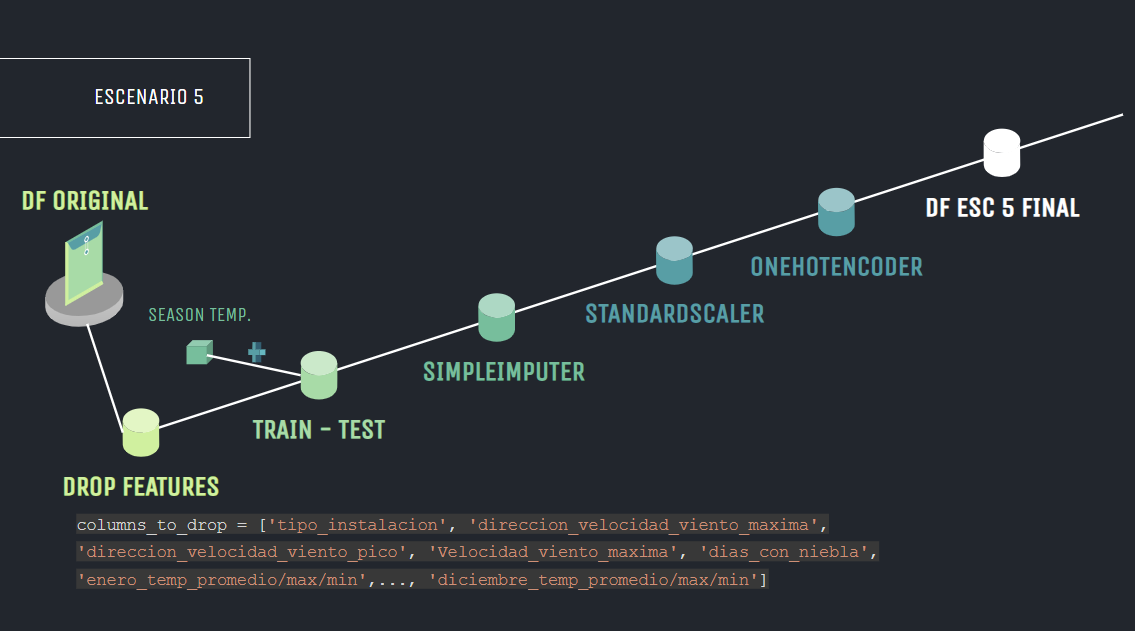

In [31]:
# Step 0: Copy base
df_esc5 = df.copy()

# Step 1: Drop unwanted columns
drop_cols = [col for col in df_esc5.columns if (
    '_temp_min' in col or '_temp_max' in col or 'viento' in col or 'niebla' in col
)]
df_esc5 = df_esc5.drop(columns=drop_cols)

# Step 2: Create seasonal average columns
seasons = {
    'verano_temp_promedio': ['junio_temp_promedio', 'julio_temp_promedio', 'agosto_temp_promedio'],
    'otoño_temp_promedio': ['septiembre_temp_promedio', 'octubre_temp_promedio', 'noviembre_temp_promedio'],
    'invierno_temp_promedio': ['diciembre_temp_promedio', 'enero_temp_promedio', 'febrero_temp_promedio'],
    'primavera_temp_promedio': ['marzo_temp_promedio', 'abril_temp_promedio', 'mayo_temp_promedio']
}

for season, months in seasons.items():
    df_esc5[season] = df_esc5[months].mean(axis=1)

# Drop monthly columns
monthly_cols = [month for months in seasons.values() for month in months]
df_esc5 = df_esc5.drop(columns=monthly_cols)


# Step 3: Split features and target
# X_esc5 = df_esc5.drop(columns=['consumo'])
# y_esc5 = df_esc5['consumo']

# Step 4: Train-test split (before any transformation)
train_esc5, test_esc5 = train_test_split(df_esc5, test_size=0.3, random_state=42)

# Step 5: Identify column types
numerical_cols = train_esc5.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_esc5.select_dtypes(include=['object', 'category']).columns.tolist()

# Step 6: Create preprocessors for numerical and categorical columns
# Numerical pipeline: Impute + Scale
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: One-Hot Encoding
categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessors using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ],
    remainder='passthrough' # Keep non-specified columns
)

# Step 7: Apply the preprocessor to the training and test sets
train_processed = preprocessor.fit_transform(train_esc5)
test_processed = preprocessor.transform(test_esc5)

# Step 8: Get feature names after preprocessing to create DataFrames
transformed_cols = numerical_cols + list(preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols))
passthrough_cols = [col for col in train_esc5.columns if col not in numerical_cols + categorical_cols]
all_feature_names = transformed_cols + passthrough_cols


# Step 9: Generate DataFrames for the models
train_final_esc5 = pd.DataFrame(train_processed, index=train_esc5.index, columns=all_feature_names)
test_final_esc5 = pd.DataFrame(test_processed, index=test_esc5.index, columns=all_feature_names)

# Step 10: Split features and target
X_train_final_esc5 = train_final_esc5.drop(columns=['consumo'])
y_train_final_esc5 = train_final_esc5['consumo']

X_test_final_esc5 = test_final_esc5.drop(columns=['consumo'])
y_test_final_esc5 = test_final_esc5['consumo']

# Assign target variables to match scenario naming convention
# y_train_final_esc5 = y_train_esc5
# y_test_final_esc5 = y_test_esc5

# Optional: check the shape
print("Preparación de datos para Escenario 5 completa usando pipeline.")
print(f"X_train_final_esc5 shape: {X_train_final_esc5.shape}")
print(f"X_test_final_esc5 shape: {X_test_final_esc5.shape}")
print(f"y_train_final_esc5 shape: {y_train_final_esc5.shape}")
print(f"y_test_final_esc5 shape: {y_test_final_esc5.shape}")

print("\nX_train_final_esc5 head:")
display(X_train_final_esc5.head())

print("\nX_test_final_esc5 head:")
display(X_test_final_esc5.head())

Preparación de datos para Escenario 5 completa usando pipeline.
X_train_final_esc5 shape: (53029, 92)
X_test_final_esc5 shape: (22728, 92)
y_train_final_esc5 shape: (53029,)
y_test_final_esc5 shape: (22728,)

X_train_final_esc5 head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,grados_dia_enfriamiento,grados_dia_calefaccion,precipitacion_mm,nevada_mm,profundidad_nieve_mm,...,tipo_instalacion_Retail_Uncategorized,tipo_instalacion_Retail_Vehicle_dealership_showroom,tipo_instalacion_Service_Drycleaning_or_Laundry,tipo_instalacion_Service_Uncategorized,tipo_instalacion_Service_Vehicle_service_repair_shop,tipo_instalacion_Warehouse_Distribution_or_Shipping_center,tipo_instalacion_Warehouse_Nonrefrigerated,tipo_instalacion_Warehouse_Refrigerated,tipo_instalacion_Warehouse_Selfstorage,tipo_instalacion_Warehouse_Uncategorized
13184,1.108561,-0.326554,0.182929,-0.094671,2.659445,0.479610,1.348325,0.047848,-0.098842,-0.060235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18163,-1.604780,1.691065,1.034474,0.984705,-0.406136,0.191896,-0.419375,-0.365877,-1.092242,-0.881000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
74041,1.108561,-0.394751,0.732313,-2.339773,-0.216737,-2.397529,-0.669132,0.249987,-1.552461,-0.932298,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16247,-2.283115,11.044662,0.485090,0.293904,0.054790,0.329388,0.013457,2.874022,0.877720,1.444502,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50301,0.430226,-0.445340,-0.668617,-0.396896,-0.231822,0.965923,0.165009,-0.133511,1.124667,1.700991,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



X_test_final_esc5 head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,grados_dia_enfriamiento,grados_dia_calefaccion,precipitacion_mm,nevada_mm,profundidad_nieve_mm,...,tipo_instalacion_Retail_Uncategorized,tipo_instalacion_Retail_Vehicle_dealership_showroom,tipo_instalacion_Service_Drycleaning_or_Laundry,tipo_instalacion_Service_Uncategorized,tipo_instalacion_Service_Vehicle_service_repair_shop,tipo_instalacion_Warehouse_Distribution_or_Shipping_center,tipo_instalacion_Warehouse_Nonrefrigerated,tipo_instalacion_Warehouse_Refrigerated,tipo_instalacion_Warehouse_Selfstorage,tipo_instalacion_Warehouse_Uncategorized
29922,-0.926445,0.368346,1.034474,0.164379,-0.406136,0.179166,0.419616,0.371837,0.030244,-0.573213,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
55120,1.108561,-0.401859,-0.668617,1.459630,-0.603916,0.731678,-0.087173,-0.020162,0.389439,-0.362322,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
52830,1.108561,-0.256191,-0.311517,0.078029,-0.481561,0.731678,-0.087173,-0.020162,0.389439,-0.362322,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47809,0.430226,0.273735,0.127990,0.639305,-0.303894,0.965923,0.165009,-0.133511,1.124667,1.700991,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4663,1.108561,-0.631000,-0.586209,0.984705,-0.620677,-2.697973,-2.811468,-1.982993,-1.631034,-0.937998,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# RESUMEN

Se muestra en forma de tabla el resumen de cada escenario

Resumen de los escenarios (ordenado por Número de Columnas en X_train):


,Scenario,Train Set Shape (X),Test Set Shape (X),Train Set Shape (y),Test Set Shape (y),Train Rows,Train Cols
0,Base,"(53029, 128)","(22728, 128)","(53029,)","(22728,)",53029,128
1,1,"(53029, 128)","(22728, 128)","(53029,)","(22728,)",53029,128
5,5,"(53029, 92)","(22728, 92)","(53029,)","(22728,)",53029,92
2,2,"(53029, 61)","(22728, 61)","(53029,)","(22728,)",53029,61
4,4,"(53029, 40)","(22728, 40)","(53029,)","(22728,)",53029,40
3,3,"(33905, 35)","(14531, 35)","(33905,)","(14531,)",33905,35


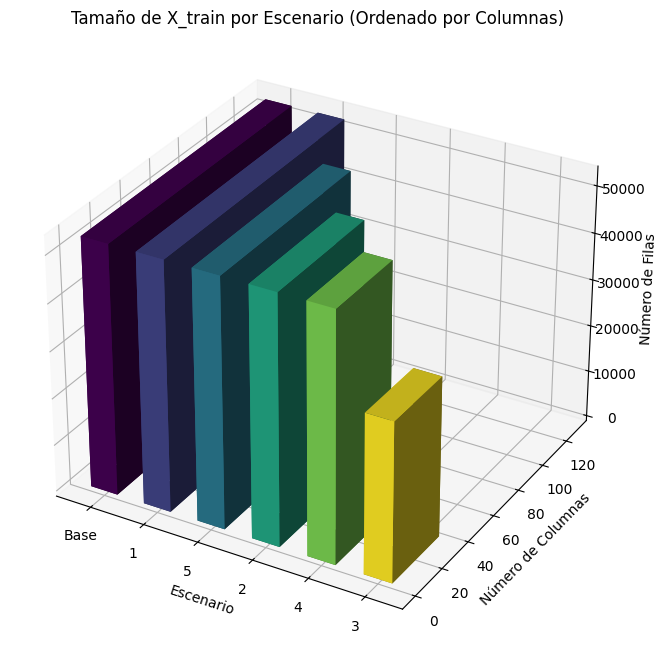

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Create a dictionary with the scenario details
scenario_summary = {
    'Scenario': ['Base', '1', '2', '3', '4', '5'],
    'Train Set Shape (X)': [X_train_final_escBase.shape, X_train_final_esc1.shape, X_train_final_esc2.shape, X_train_final_esc3.shape, X_train_final_esc4.shape, X_train_final_esc5.shape],
    'Test Set Shape (X)': [X_test_final_escBase.shape, X_test_final_esc1.shape, X_test_final_esc2.shape, X_test_final_esc3.shape, X_test_final_esc4.shape, X_test_final_esc5.shape],
    'Train Set Shape (y)': [y_train_final_escBase.shape, y_train_final_esc1.shape, y_train_final_esc2.shape, y_train_final_esc3.shape, y_train_final_esc4.shape, y_train_final_esc5.shape],
    'Test Set Shape (y)': [y_test_final_escBase.shape, y_test_final_esc1.shape, y_test_final_esc2.shape, y_test_final_esc3.shape, y_test_final_esc4.shape, y_test_final_esc5.shape]
}

# Create a DataFrame from the dictionary
summary_df = pd.DataFrame(scenario_summary)

# Extract the number of rows and columns from the 'Train Set Shape (X)' tuple
train_rows = [shape[0] for shape in summary_df['Train Set Shape (X)']]
train_cols = [shape[1] for shape in summary_df['Train Set Shape (X)']]

# Add rows and columns as columns to the DataFrame for easier sorting
summary_df['Train Rows'] = train_rows
summary_df['Train Cols'] = train_cols

# Sort the DataFrame by 'Train Cols' in descending order
summary_df_sorted = summary_df.sort_values(by='Train Cols', ascending=False)

# Display the sorted DataFrame
print("Resumen de los escenarios (ordenado por Número de Columnas en X_train):")
display(summary_df_sorted)

# Extract sorted data for plotting
scenarios_sorted = summary_df_sorted['Scenario']
train_rows_sorted = summary_df_sorted['Train Rows']
train_cols_sorted = summary_df_sorted['Train Cols']


# Create a 3D bar plot for the size of X_train for each scenario
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

x_pos = np.arange(len(scenarios_sorted))
y_pos = [0] * len(scenarios_sorted)
z_pos = [0] * len(scenarios_sorted)

dx = [0.5] * len(scenarios_sorted)
dy = train_rows_sorted  # Height of the bars (number of rows)
dz = train_cols_sorted  # Depth of the bars (number of columns)

# Define colors for each bar
colors = plt.cm.viridis(np.linspace(0, 1, len(scenarios_sorted)))

# Plot bars with different colors
ax.bar3d(x_pos, z_pos, y_pos, dx, dz, dy, color=colors)

ax.set_xticks(x_pos + dx[0]/2)
ax.set_xticklabels(scenarios_sorted)
ax.set_xlabel('Escenario')
ax.set_zlabel('Número de Filas')
ax.set_ylabel('Número de Columnas')
ax.set_title('Tamaño de X_train por Escenario (Ordenado por Columnas)')

plt.show()

Número de Columnas por Escenario (X_train):


,X_train_cols
Base,128
1,128
2,61
3,35
4,40
5,92


/tmp/ipython-input-1473986400.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=column_counts_df.index, y=column_counts_df['X_train_cols'], palette='viridis')


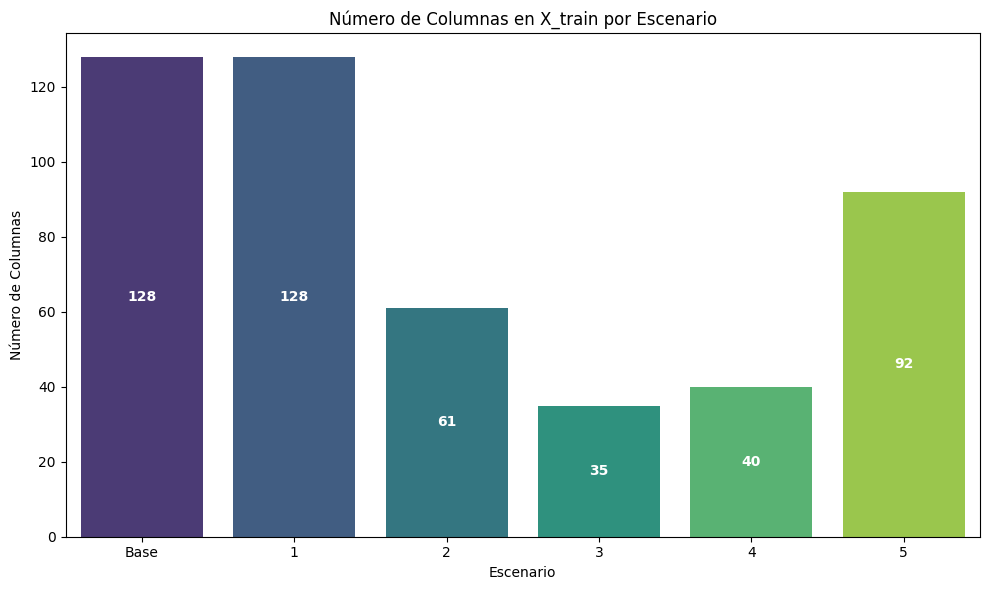

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns # Import seaborn for enhanced plotting

# Create a dictionary to store the number of columns for X_train and X_test for each scenario
column_counts = {}

# Iterate through the scenarios and get the shape of X_train and X_test
# Make sure the scenario variables exist before accessing them
scenarios = {
    'Base': (X_train_final_escBase, X_test_final_escBase),
    '1': (X_train_final_esc1, X_test_final_esc1),
    '2': (X_train_final_esc2, X_test_final_esc2),
    '3': (X_train_final_esc3, X_test_final_esc3),
    '4': (X_train_final_esc4, X_test_final_esc4),
    '5': (X_train_final_esc5, X_test_final_esc5)
}

for scenario_name, (X_train, X_test) in scenarios.items():
    column_counts[scenario_name] = {
        'X_train_cols': X_train.shape[1],
        'X_test_cols': X_test.shape[1]
    }

# Create a DataFrame from the dictionary
column_counts_df = pd.DataFrame(column_counts).T

# Display the table with enhanced styling, focusing on X_train columns
print("Número de Columnas por Escenario (X_train):")
display(column_counts_df[['X_train_cols']].style.background_gradient(cmap='Blues').set_caption("Número de Columnas en X_train por Escenario"))

# Create a 2D bar plot for X_train columns only
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x=column_counts_df.index, y=column_counts_df['X_train_cols'], palette='viridis')

# Add labels and title
plt.ylabel('Número de Columnas')
plt.xlabel('Escenario')
plt.title('Número de Columnas en X_train por Escenario')

# Add the column counts on top of the bars
for bar in barplot.patches:
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height()/2, # Position in the center of the bar
             int(bar.get_height()),
             ha='center', va='center', color='white', fontweight='bold') # Set color to white and fontweight to bold


plt.tight_layout()
plt.show()

# 3.MODELOS

## 3.1.METRICAS (REGRESION)

### OPCIONES

Las metricas que se pueden utilizar para evaluar los modelos de regresion son:


1. **MAE – Mean Absolute Error**  
   Mide el promedio de los errores absolutos entre predicciones y valores reales.  
   $$
   MAE = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|
   $$  
   - Robusta a outliers.  
   - [Docs sklearn.metrics.mean_absolute_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html)

---

2. **MSE – Mean Squared Error**  
   Calcula el promedio de los errores al cuadrado, penalizando más los grandes errores.  
   $$
   MSE = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2
   $$  
   - Útil si queremos dar más peso a errores grandes.  
   - [Docs sklearn.metrics.mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html)

---

3. **RMSE – Root Mean Squared Error**  
   Es la raíz cuadrada del MSE, expresada en la misma unidad que la variable objetivo.  
   $$
   RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
   $$  
   - Facilita la interpretación frente al MSE.  
   - [Docs sklearn.metrics.mean_squared_error (squared=False)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html)

---

4. **R² – Coeficiente de determinación**  
   Indica la proporción de la varianza de la variable dependiente explicada por el modelo.  
   $$
   R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
   $$  
   - Valores cercanos a 1 indican buen ajuste.  
   - Puede ser negativo si el modelo es peor que usar la media.  
   - [Docs sklearn.metrics.r2_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)

---

5. **Mediana del Error Absoluto**  
   Toma la mediana de los errores absolutos, siendo más robusta frente a valores extremos.  
   $$
   MedAE = \text{mediana}(|y_i - \hat{y}_i|)
   $$  
   - Reduce la influencia de outliers muy grandes.  
   - [Docs sklearn.metrics.median_absolute_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.median_absolute_error.html)

---

6. **MAPE – Mean Absolute Percentage Error**  
   Representa el error absoluto en términos porcentuales sobre el valor real.  
   $$
   MAPE = \frac{100}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|
   $$  
   - Útil para interpretar errores en % relativo.  
   - No confiable si $y_i \approx 0$.  
   - [Docs sklearn.metrics.mean_absolute_percentage_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_percentage_error.html)


### SELECCION

Para la eleccion de la mejor metrica se prioriza los siguientes aspectos:

1. **Claridad en la interpretación**:  
   Los resultados deben ser comprensibles para las entidades encargadas de tomar desiciones.

2. **Consistencia con la unidad de medida**:  
   El error debe expresarse en la misma unidad que la variable de interés (kWh), para facilitar la toma de decisiones operativas.



* **MAE (Mean Absolute Error)**
    - Se interpreta directamente como *“el modelo se equivoca en promedio X kWh”*.  
    - Es robusta frente a valores atípicos extremos.  
    - Fácil de comunicar a un público no técnico.

  Ejemplo de interpretación:  
  *“Nuestro modelo predice el consumo con un error promedio de 120 kWh mensuales”*.



* **R² (Coeficiente de determinación)**:  
    - Indica la proporción de la variabilidad explicada por el modelo. Útil para mostrar la calidad general del ajuste.  


---

**La métrica más conveniente y de fácil interpretación es el **MAE**, complementado con **R²** para evaluar la calidad global del modelo.**

---

## 3.2.REGRESION LINEAL

CON TODAS LAS VARIABLES

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# Diccionario para almacenar los resultados de las métricas por escenario y set
resultados_metricas = {}

# Diccionario de escenarios y sus datos
escenarios = {
    'Base': (X_train_final_escBase, X_test_final_escBase, y_train_final_escBase, y_test_final_escBase),
    '1': (X_train_final_esc1, X_test_final_esc1, y_train_final_esc1, y_test_final_esc1),
    '2': (X_train_final_esc2, X_test_final_esc2, y_train_final_esc2, y_test_final_esc2),
    '3': (X_train_final_esc3, X_test_final_esc3, y_train_final_esc3, y_test_final_esc3),
    '4': (X_train_final_esc4, X_test_final_esc4, y_train_final_esc4, y_test_final_esc4),
    '5': (X_train_final_esc5, X_test_final_esc5, y_train_final_esc5, y_test_final_esc5)
}

# Iterar sobre cada escenario
for nombre_escenario, (X_train, X_test, y_train, y_test) in escenarios.items():
    print(f"--- Evaluando Escenario: {nombre_escenario} ---")

    # 1) Crear y entrenar el modelo de Regresión Lineal
    modelo_lr = LinearRegression()
    modelo_lr.fit(X_train, y_train)

    # Realizar predicciones en el conjunto de entrenamiento y prueba
    y_train_pred = modelo_lr.predict(X_train)
    y_test_pred = modelo_lr.predict(X_test)

    # 2) Calcular métricas: MAE y R2 para entrenamiento
    mae_train = mean_absolute_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)

    # Calcular métricas: MAE y R2 para prueba
    mae_test = mean_absolute_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Almacenar los resultados
    resultados_metricas[nombre_escenario] = {
        'MAE_Train': mae_train,
        'R2_Train': r2_train,
        'MAE_Test': mae_test,
        'R2_Test': r2_test
        }

    print(f"  MAE (Train): {mae_train:.2f}")
    print(f"  R2 (Train): {r2_train:.2f}")
    print(f"  MAE (Test): {mae_test:.2f}")
    print(f"  R2 (Test): {r2_test:.2f}")
    print("-" * (len(nombre_escenario) + 20))

# Mostrar los resultados en una tabla
resultados_df = pd.DataFrame(resultados_metricas).T
print("\nResumen de Métricas por Escenario (Train y Test):")
display(resultados_df)

--- Evaluando Escenario: Base ---
  MAE (Train): 76.82
  R2 (Train): 0.36
  MAE (Test): 75.91
  R2 (Test): 0.36
------------------------
--- Evaluando Escenario: 1 ---
  MAE (Train): 0.41
  R2 (Train): 0.36
  MAE (Test): 0.41
  R2 (Test): 0.36
---------------------
--- Evaluando Escenario: 2 ---
  MAE (Train): 0.45
  R2 (Train): 0.25
  MAE (Test): 0.44
  R2 (Test): 0.27
---------------------
--- Evaluando Escenario: 3 ---
  MAE (Train): 0.39
  R2 (Train): 0.41
  MAE (Test): 0.39
  R2 (Test): 0.42
---------------------
--- Evaluando Escenario: 4 ---
  MAE (Train): 0.43
  R2 (Train): 0.41
  MAE (Test): 0.43
  R2 (Test): 0.43
---------------------
--- Evaluando Escenario: 5 ---
  MAE (Train): 0.41
  R2 (Train): 0.36
  MAE (Test): 0.41
  R2 (Test): 0.36
---------------------

Resumen de Métricas por Escenario (Train y Test):


,MAE_Train,R2_Train,MAE_Test,R2_Test
Base,76.818236,0.357622,75.912996,0.356924
1,0.413013,0.357622,0.408146,0.356924
2,0.447960,0.250647,0.437217,0.269244
3,0.389126,0.409641,0.392793,0.423348
4,0.432066,0.413389,0.425678,0.432298
5,0.412621,0.355607,0.407572,0.355588


### GRAFICOS

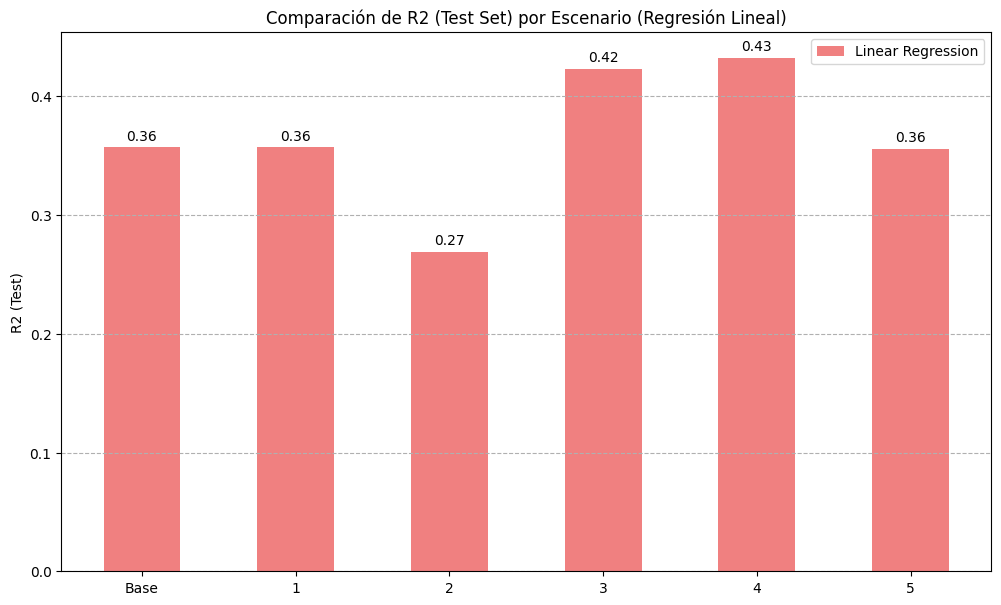

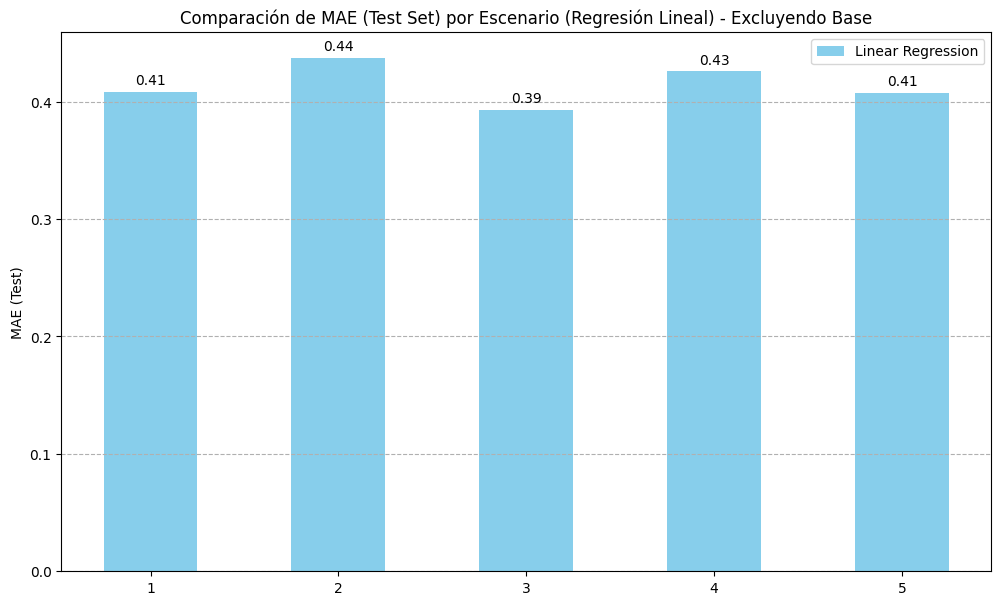

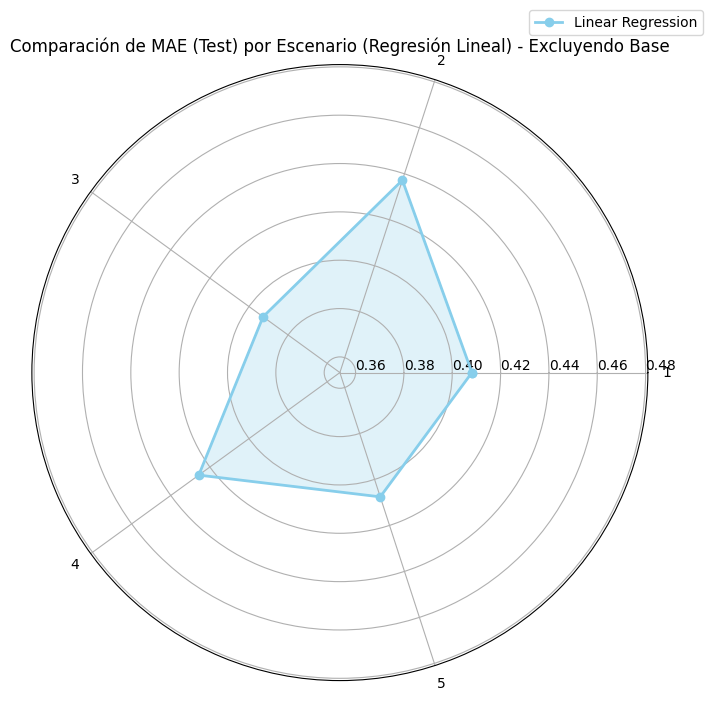

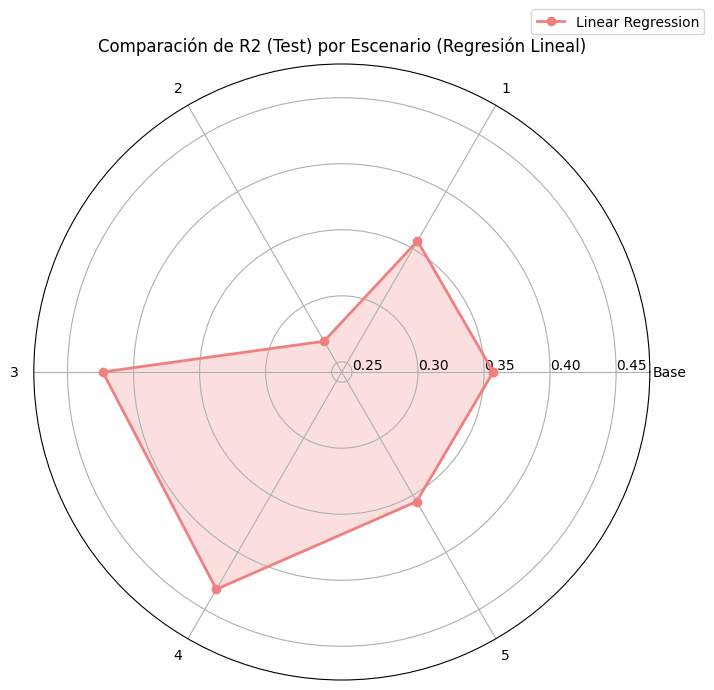

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Reutilizamos los resultados de métricas de Regresión Lineal
# Asegúrate de que la variable resultados_metricas esté disponible

# Define color palettes for MAE and R2
mae_color = 'skyblue'
r2_color = 'lightcoral'


# --- Bar Plot para R2 (Test) - Escenarios Base, 1, 2, 3, 4, 5 ---
metric = 'R2_Test'
scenarios_to_plot = ['Base', '1', '2', '3', '4', '5']

# Extract data for the selected scenarios and metric for Linear Regression
r2_data_lr = [resultados_metricas[scenario][metric] for scenario in scenarios_to_plot]


x = np.arange(len(scenarios_to_plot))
width = 0.5 # Adjust width for single bars

fig1, ax1 = plt.subplots(figsize=(12, 7))

rects_lr_r2 = ax1.bar(x, r2_data_lr, width, label='Linear Regression', color=r2_color)

ax1.set_ylabel('R2 (Test)')
ax1.set_title('Comparación de R2 (Test Set) por Escenario (Regresión Lineal)')
ax1.set_xticks(x)
ax1.set_xticklabels(scenarios_to_plot)
ax1.legend()
ax1.grid(axis='y', linestyle='--')

# Add value labels on top of bars
for rect in rects_lr_r2:
    height = rect.get_height()
    ax1.annotate(f'{height:.2f}',
                 xy=(rect.get_x() + rect.get_width() / 2, height),
                 xytext=(0, 3),  # 3 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom')


plt.show()


# --- Bar Plot para MAE (Test) - Escenarios 1, 2, 3, 4, 5 ---
metric = 'MAE_Test'
scenarios_to_plot_mae = ['1', '2', '3', '4', '5'] # Excluye Escenario Base

# Extract data for the selected scenarios and metric for Linear Regression
mae_data_lr = [resultados_metricas[scenario][metric] for scenario in scenarios_to_plot_mae]


x_mae = np.arange(len(scenarios_to_plot_mae))

fig2, ax2 = plt.subplots(figsize=(12, 7))

rects_lr_mae = ax2.bar(x_mae, mae_data_lr, width, label='Linear Regression', color=mae_color)

ax2.set_ylabel('MAE (Test)')
ax2.set_title('Comparación de MAE (Test Set) por Escenario (Regresión Lineal) - Excluyendo Base')
ax2.set_xticks(x_mae)
ax2.set_xticklabels(scenarios_to_plot_mae)
ax2.legend()
ax2.grid(axis='y', linestyle='--')

# Add value labels on top of bars
for rect in rects_lr_mae:
    height = rect.get_height()
    ax2.annotate(f'{height:.2f}',
                 xy=(rect.get_x() + rect.get_width() / 2, height),
                 xytext=(0, 3),  # 3 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom')


plt.show()


# --- Gráficos polares para métricas de test (Regresión Lineal) ---
# Filter out 'Base' scenario for MAE polar plot
escenarios_nombres_polar_mae = [esc for esc in resultados_metricas.keys() if esc != 'Base']
num_scenarios_polar_mae = len(escenarios_nombres_polar_mae)
angles_polar_mae = np.linspace(0, 2 * np.pi, num_scenarios_polar_mae, endpoint=False).tolist()
angles_polar_mae += angles_polar_mae[:1] # Cerrar el círculo

# Gráfico polar para MAE (Test)
fig_mae_test_polar, ax_mae_test_polar = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Obtener los valores de MAE (Test) para Linear Regression (excluding Base)
valores_mae_test_lr = [resultados_metricas[escenario]['MAE_Test'] for escenario in escenarios_nombres_polar_mae]
valores_mae_test_lr += valores_mae_test_lr[:1] # Cerrar el círculo


# Trazar la línea para Linear Regression
ax_mae_test_polar.plot(angles_polar_mae, valores_mae_test_lr, 'o-', linewidth=2, color=mae_color, label='Linear Regression')
ax_mae_test_polar.fill(angles_polar_mae, valores_mae_test_lr, alpha=0.25, color=mae_color)


ax_mae_test_polar.set_thetagrids(np.array(angles_polar_mae[:-1]) * 180 / np.pi, escenarios_nombres_polar_mae)
ax_mae_test_polar.set_title('Comparación de MAE (Test) por Escenario (Regresión Lineal) - Excluyendo Base', va='bottom')
ax_mae_test_polar.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

# Ajustar límite radial para MAE (Test) - un valor más bajo es mejor (más cerca del centro)
min_mae_test_lr = min(resultados_metricas[escenario]['MAE_Test'] for escenario in escenarios_nombres_polar_mae)
max_mae_test_lr = max(resultados_metricas[escenario]['MAE_Test'] for escenario in escenarios_nombres_polar_mae)
ax_mae_test_polar.set_ylim(min_mae_test_lr * 0.9, max_mae_test_lr * 1.1) # Escala normal (mayor valor = más lejos del centro)
ax_mae_test_polar.set_rlabel_position(0) # Posicionar etiquetas radiales
ax_mae_test_polar.grid(True)

plt.show()


# Gráfico polar para R2 (Test) - Keep all scenarios for R2 as per previous request
escenarios_nombres_polar_r2 = list(resultados_metricas.keys())
num_scenarios_polar_r2 = len(escenarios_nombres_polar_r2)
angles_polar_r2 = np.linspace(0, 2 * np.pi, num_scenarios_polar_r2, endpoint=False).tolist()
angles_polar_r2 += angles_polar_r2[:1] # Cerrar el círculo

fig_r2_test_polar, ax_r2_test_polar = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Obtener los valores de R2 (Test) para Linear Regression
valores_r2_test_lr = [resultados_metricas[escenario]['R2_Test'] for escenario in escenarios_nombres_polar_r2]
valores_r2_test_lr += valores_r2_test_lr[:1] # Cerrar el círculo

# Trazar la línea para Linear Regression
ax_r2_test_polar.plot(angles_polar_r2, valores_r2_test_lr, 'o-', linewidth=2, color=r2_color, label='Linear Regression')
ax_r2_test_polar.fill(angles_polar_r2, valores_r2_test_lr, alpha=0.25, color=r2_color)


ax_r2_test_polar.set_thetagrids(np.array(angles_polar_r2[:-1]) * 180 / np.pi, escenarios_nombres_polar_r2)
ax_r2_test_polar.set_title('Comparación de R2 (Test) por Escenario (Regresión Lineal)', va='bottom')
ax_r2_test_polar.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

# Ajustar límite radial para R2 (Test) - un valor más alto es mejor (más lejos del centro)
min_r2_test_lr = min(resultados_metricas[escenario]['R2_Test'] for escenario in escenarios_nombres_polar_r2)
max_r2_test_lr = max(resultados_metricas[escenario]['R2_Test'] for escenario in escenarios_nombres_polar_r2)
ax_r2_test_polar.set_ylim(min_r2_test_lr * 0.9, max_r2_test_lr * 1.1) # Escala normal (mayor valor = más lejos del centro)
ax_r2_test_polar.set_rlabel_position(0) # Posicionar etiquetas radiales
ax_r2_test_polar.grid(True)

plt.show()

CON LAS 5 CARACTERÍSTICAS QUE TIENEN MAS CORRELACIÓN CON LA VARIABLE TARGET:

features = ['calificacion_energystar', 'nevada_mm', 'grados_dia_calefaccion','dias_menos_1C','grados_dia_enfriamiento']

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# Diccionario para almacenar los resultados de las métricas por escenario y set
resultados_metricas_lr_5 = {}

# Diccionario de escenarios y sus datos
escenarios = {
    'Base': (X_train_final_escBase, X_test_final_escBase, y_train_final_escBase, y_test_final_escBase),
    '1': (X_train_final_esc1, X_test_final_esc1, y_train_final_esc1, y_test_final_esc1),
    '2': (X_train_final_esc2, X_test_final_esc2, y_train_final_esc2, y_test_final_esc2),
    '3': (X_train_final_esc3, X_test_final_esc3, y_train_final_esc3, y_test_final_esc3),
    '4': (X_train_final_esc4, X_test_final_esc4, y_train_final_esc4, y_test_final_esc4),
    '5': (X_train_final_esc5, X_test_final_esc5, y_train_final_esc5, y_test_final_esc5)
}

# Iterar sobre cada escenario
for nombre_escenario, (X_train, X_test, y_train, y_test) in escenarios.items():
    #Seleccionamos las variables mas correlacionasdas con la variable target
    features = ['calificacion_energystar', 'nevada_mm', 'grados_dia_calefaccion','dias_menos_1C','grados_dia_enfriamiento']
    X_train = X_train[features]
    X_test = X_test[features]

    print(f"--- Evaluando Escenario: {nombre_escenario} ---")

    # 1) Crear y entrenar el modelo de Regresión Lineal
    modelo_lr = LinearRegression()
    modelo_lr.fit(X_train, y_train)

    # Realizar predicciones en el conjunto de entrenamiento y prueba
    y_train_pred = modelo_lr.predict(X_train)
    y_test_pred = modelo_lr.predict(X_test)

    # 2) Calcular métricas: MAE y R2 para entrenamiento
    mae_train = mean_absolute_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)

    # Calcular métricas: MAE y R2 para prueba
    mae_test = mean_absolute_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Almacenar los resultados
    resultados_metricas_lr_5[nombre_escenario] = {
        'MAE_Train': mae_train,
        'R2_Train': r2_train,
        'MAE_Test': mae_test,
        'R2_Test': r2_test
        }

    print(f"  MAE (Train): {mae_train:.2f}")
    print(f"  R2 (Train): {r2_train:.2f}")
    print(f"  MAE (Test): {mae_test:.2f}")
    print(f"  R2 (Test): {r2_test:.2f}")
    print("-" * (len(nombre_escenario) + 20))

# Mostrar los resultados en una tabla
resultados_df = pd.DataFrame(resultados_metricas_lr_5).T
print("\nResumen de Métricas por Escenario (Train y Test):")
display(resultados_df)

--- Evaluando Escenario: Base ---
  MAE (Train): 89.20
  R2 (Train): 0.16
  MAE (Test): 87.75
  R2 (Test): 0.17
------------------------
--- Evaluando Escenario: 1 ---
  MAE (Train): 0.48
  R2 (Train): 0.16
  MAE (Test): 0.47
  R2 (Test): 0.17
---------------------
--- Evaluando Escenario: 2 ---
  MAE (Train): 0.48
  R2 (Train): 0.16
  MAE (Test): 0.47
  R2 (Test): 0.17
---------------------
--- Evaluando Escenario: 3 ---
  MAE (Train): 0.43
  R2 (Train): 0.28
  MAE (Test): 0.43
  R2 (Test): 0.29
---------------------
--- Evaluando Escenario: 4 ---
  MAE (Train): 0.44
  R2 (Train): 0.38
  MAE (Test): 0.44
  R2 (Test): 0.40
---------------------
--- Evaluando Escenario: 5 ---
  MAE (Train): 0.48
  R2 (Train): 0.15
  MAE (Test): 0.47
  R2 (Test): 0.16
---------------------

Resumen de Métricas por Escenario (Train y Test):


,MAE_Train,R2_Train,MAE_Test,R2_Test
Base,89.203478,0.156647,87.748771,0.171084
1,0.479602,0.156647,0.471781,0.171084
2,0.479602,0.156647,0.471781,0.171084
3,0.431795,0.284377,0.429673,0.293279
4,0.440506,0.383003,0.435622,0.400862
5,0.481918,0.150628,0.474454,0.164295


##3.3.REGRESION LINEAL CON PENALIZACION

In [37]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# Diccionario para almacenar los resultados de las métricas por escenario y set para Ridge
resultados_metricas_ridge = {}

# Lista de valores de alpha para probar
alphas_to_test = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0] # Puedes ajustar estos valores según necesites

# Lista de escenarios y sus datos (reutilizamos los de la sección anterior)
# escenarios = {
#     'Base': (X_train_final_escBase, X_test_final_escBase, y_train_final_escBase, y_test_final_escBase),
#     '1': (X_train_final_esc1, X_test_final_esc1, y_train_final_esc1, y_test_final_esc1),
#     '2': (X_train_final_esc2, X_test_final_esc2, y_train_final_esc2, y_test_final_esc2),
#     '3': (X_train_final_esc3, X_test_final_esc3, y_train_final_esc3, y_test_final_esc3),
#     '4': (X_train_final_esc4, X_test_final_esc4, y_train_final_esc4, y_test_final_esc4),
#     '5': (X_train_final_esc5, X_test_final_esc5, y_train_final_esc5, y_test_final_esc5)
# }

# Iterar sobre cada valor de alpha
for alpha_val in alphas_to_test:
    print(f"--- Evaluando Regresión Ridge con alpha={alpha_val} ---")
    resultados_metricas_ridge[f'alpha={alpha_val}'] = {} # Sub-diccionario para este alpha

    # Iterar sobre cada escenario para el alpha actual
    for nombre_escenario, (X_train, X_test, y_train, y_test) in escenarios.items():
        print(f"  Escenario: {nombre_escenario}")

        # 1) Crear y entrenar el modelo de Regresión Ridge con el alpha actual
        modelo_ridge = Ridge(alpha=alpha_val, random_state=42)
        modelo_ridge.fit(X_train, y_train)

        # Realizar predicciones en el conjunto de entrenamiento y prueba
        y_train_pred_ridge = modelo_ridge.predict(X_train)
        y_test_pred_ridge = modelo_ridge.predict(X_test)

        # 2) Calcular métricas: MAE y R2 para entrenamiento
        mae_train_ridge = mean_absolute_error(y_train, y_train_pred_ridge)
        r2_train_ridge = r2_score(y_train, y_train_pred_ridge)

        # Calcular métricas: MAE y R2 para prueba
        mae_test_ridge = mean_absolute_error(y_test, y_test_pred_ridge)
        r2_test_ridge = r2_score(y_test, y_test_pred_ridge)

        # Almacenar los resultados para este escenario y alpha
        resultados_metricas_ridge[f'alpha={alpha_val}'][nombre_escenario] = {
            'MAE_Train': mae_train_ridge,
            'R2_Train': r2_train_ridge,
            'MAE_Test': mae_test_ridge,
            'R2_Test': r2_test_ridge
        }

        print(f"    MAE (Train): {mae_train_ridge:.2f}")
        print(f"    R2 (Train): {r2_train_ridge:.2f}")
        print(f"    MAE (Test): {mae_test_ridge:.2f}")
        print(f"    R2 (Test): {r2_test_ridge:.2f}")

    print("-" * 40)

# Mostrar los resultados en tablas separadas por valor de alpha
for alpha_val in alphas_to_test:
    print(f"\nResumen de Métricas por Escenario (Regresión Ridge - alpha={alpha_val}):")
    resultados_df_ridge_alpha = pd.DataFrame(resultados_metricas_ridge[f'alpha={alpha_val}']).T
    display(resultados_df_ridge_alpha)

--- Evaluando Regresión Ridge con alpha=0.001 ---
  Escenario: Base
    MAE (Train): 76.82

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.70296e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)



    R2 (Train): 0.36
    MAE (Test): 75.91
    R2 (Test): 0.36
  Escenario: 1
    MAE (Train): 0.41
    R2 (Train): 0.36
    MAE (Test): 0.41
    R2 (Test): 0.36
  Escenario: 2
    MAE (Train): 0.45
    R2 (Train): 0.25
    MAE (Test): 0.44
    R2 (Test): 0.27
  Escenario: 3
    MAE (Train): 0.39
    R2 (Train): 0.41
    MAE (Test): 0.39
    R2 (Test): 0.42
  Escenario: 4
    MAE (Train): 0.43
    R2 (Train): 0.41
    MAE (Test): 0.43
    R2 (Test): 0.43
  Escenario: 5
    MAE (Train): 0.41
    R2 (Train): 0.36
    MAE (Test): 0.41
    R2 (Test): 0.36
----------------------------------------
--- Evaluando Regresión Ridge con alpha=0.01 ---
  Escenario: Base
    MAE (Train): 76.82
    R2 (Train): 0.36
    MAE (Test): 75.91
    R2 (Test): 0.36
  Escenario: 1
    MAE (Train): 0.41
    R2 (Train): 0.36
    MAE (Test): 0.41
    R2 (Test): 0.36
  Escenario: 2
    MAE (Train): 0.45
    R2 (Train): 0.25
    MAE (Test): 0.44
    R2 (Test): 0.27
  Escenario: 3
    MAE (Train): 0.39
    R2 (Trai

,MAE_Train,R2_Train,MAE_Test,R2_Test
Base,76.818203,0.357622,75.912968,0.356924
1,0.413013,0.357622,0.408146,0.356924
2,0.447960,0.250647,0.437217,0.269244
3,0.389126,0.409641,0.392793,0.423348
4,0.432066,0.413389,0.425678,0.432298
5,0.412621,0.355607,0.407572,0.355589



Resumen de Métricas por Escenario (Regresión Ridge - alpha=0.01):


...

,MAE_Train,R2_Train,MAE_Test,R2_Test
Base,76.814876,0.357574,75.896362,0.357345
1,0.412989,0.357566,0.408036,0.357356
2,0.447975,0.250634,0.437219,0.269118
3,0.389107,0.409640,0.392761,0.423366
4,0.432059,0.413389,0.425681,0.432304
5,0.412604,0.355572,0.407478,0.356019



Resumen de Métricas por Escenario (Regresión Ridge - alpha=10.0):


,MAE_Train,R2_Train,MAE_Test,R2_Test
Base,76.882857,0.356059,75.840718,0.358569
1,0.413337,0.356040,0.407674,0.358578
2,0.448086,0.250169,0.437307,0.267703
3,0.388979,0.409600,0.392553,0.423424
4,0.432015,0.413383,0.425659,0.432350
5,0.412962,0.354062,0.407092,0.357377



Resumen de Métricas por Escenario (Regresión Ridge - alpha=100.0):


,MAE_Train,R2_Train,MAE_Test,R2_Test
Base,78.091646,0.334234,76.642298,0.345934
1,0.419749,0.334124,0.411880,0.346120
2,0.448460,0.247173,0.437729,0.263568
3,0.388627,0.408338,0.391754,0.422130
4,0.431670,0.413300,0.425346,0.432599
5,0.419409,0.331964,0.411513,0.344987


### GRAFICOS

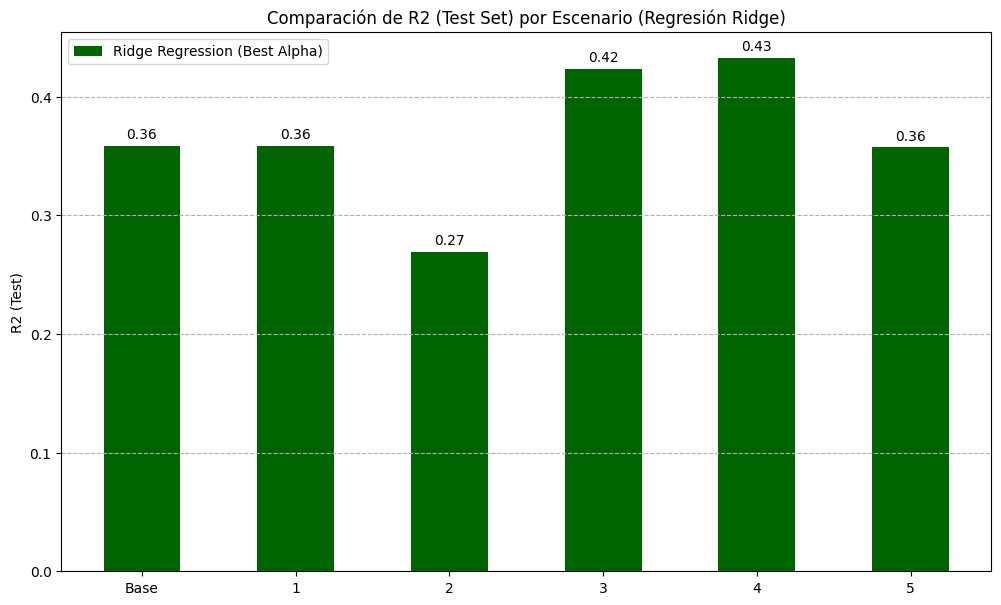

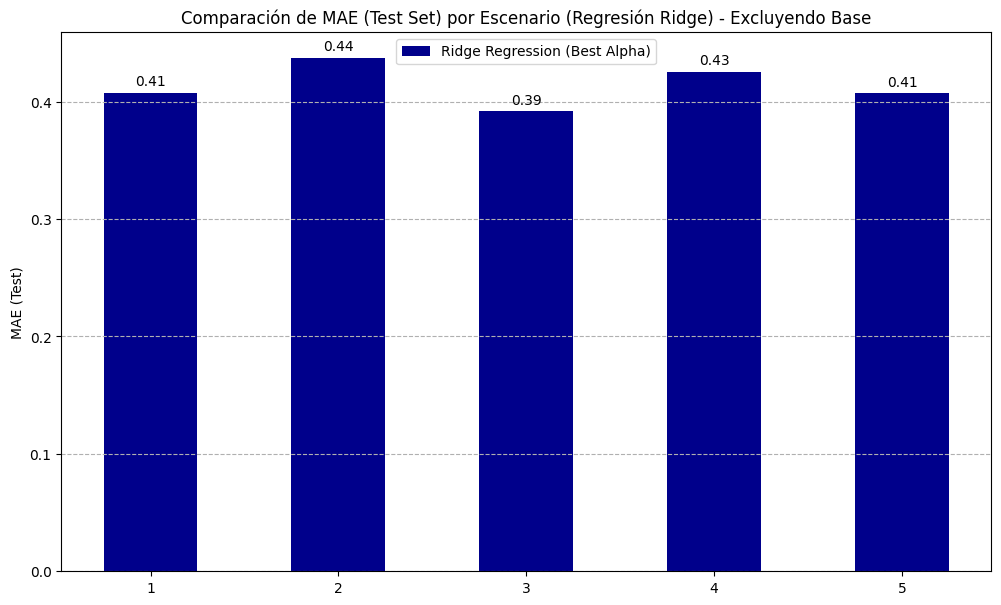

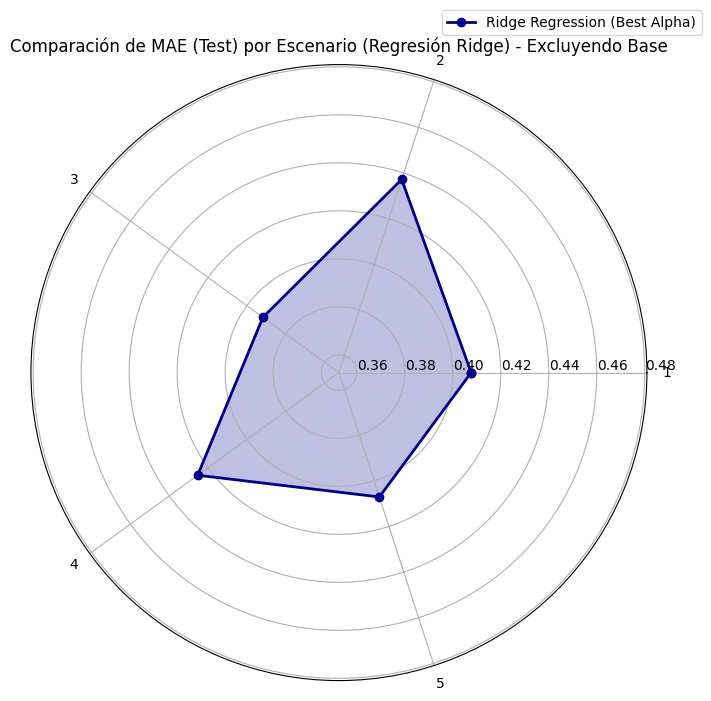

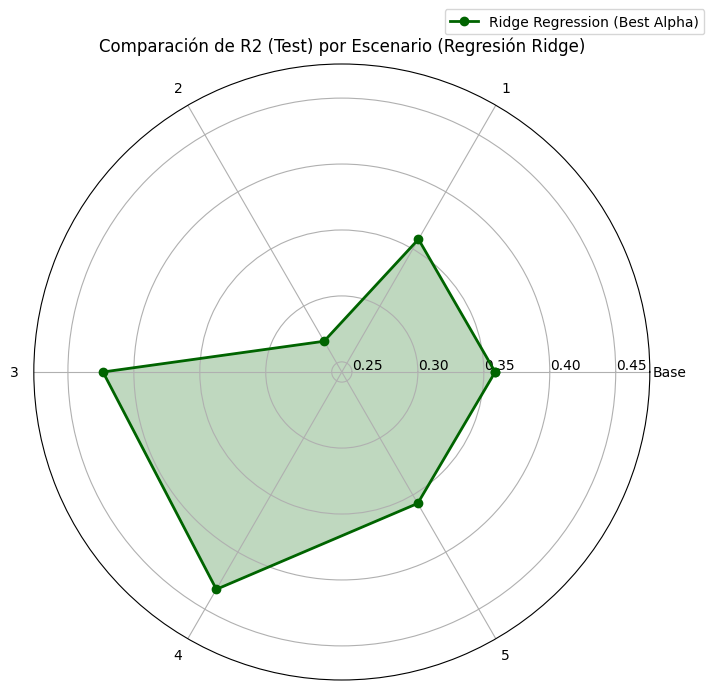

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Reutilizamos los resultados de métricas de Regresión Ridge
# Asegúrate de que la variable resultados_metricas_ridge esté disponible

# Define color palettes for MAE and R2
mae_color = 'darkblue' # Using different colors for Ridge plots
r2_color = 'darkgreen'


# Function to find the best MAE/R2 for each scenario from the Ridge results
def get_best_ridge_metrics(results_dict, metric):
    best_metrics = {}
    scenarios = results_dict[list(results_dict.keys())[0]].keys() # Get scenario names from one alpha result
    for scenario in scenarios:
        best_value = float('inf') if 'MAE' in metric else -float('inf')
        best_alpha = None
        for alpha_key, scenario_results in results_dict.items():
            if scenario in scenario_results:
                current_value = scenario_results[scenario][metric]
                if ('MAE' in metric and current_value < best_value) or ('R2' in metric and current_value > best_value):
                    best_value = current_value
                    best_alpha = alpha_key
        best_metrics[scenario] = best_value
    return best_metrics

# Get the best MAE and R2 for each scenario across different alphas
best_mae_test_ridge = get_best_ridge_metrics(resultados_metricas_ridge, 'MAE_Test')
best_r2_test_ridge = get_best_ridge_metrics(resultados_metricas_ridge, 'R2_Test')


# --- Bar Plot para R2 (Test) - Escenarios Base, 1, 2, 3, 4, 5 ---
metric = 'R2_Test'
scenarios_to_plot = ['Base', '1', '2', '3', '4', '5']

# Extract data for the selected scenarios and metric for Ridge Regression
r2_data_ridge = [best_r2_test_ridge[scenario] for scenario in scenarios_to_plot]


x = np.arange(len(scenarios_to_plot))
width = 0.5 # Adjust width for single bars

fig1, ax1 = plt.subplots(figsize=(12, 7))

rects_ridge_r2 = ax1.bar(x, r2_data_ridge, width, label='Ridge Regression (Best Alpha)', color=r2_color)

ax1.set_ylabel('R2 (Test)')
ax1.set_title('Comparación de R2 (Test Set) por Escenario (Regresión Ridge)')
ax1.set_xticks(x)
ax1.set_xticklabels(scenarios_to_plot)
ax1.legend()
ax1.grid(axis='y', linestyle='--')

# Add value labels on top of bars
for rect in rects_ridge_r2:
    height = rect.get_height()
    ax1.annotate(f'{height:.2f}',
                 xy=(rect.get_x() + rect.get_width() / 2, height),
                 xytext=(0, 3),  # 3 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom')


plt.show()


# --- Bar Plot para MAE (Test) - Escenarios 1, 2, 3, 4, 5 ---
metric = 'MAE_Test'
scenarios_to_plot_mae = ['1', '2', '3', '4', '5'] # Excluye Escenario Base

# Extract data for the selected scenarios and metric for Ridge Regression
mae_data_ridge = [best_mae_test_ridge[scenario] for scenario in scenarios_to_plot_mae]


x_mae = np.arange(len(scenarios_to_plot_mae))

fig2, ax2 = plt.subplots(figsize=(12, 7))

rects_ridge_mae = ax2.bar(x_mae, mae_data_ridge, width, label='Ridge Regression (Best Alpha)', color=mae_color)

ax2.set_ylabel('MAE (Test)')
ax2.set_title('Comparación de MAE (Test Set) por Escenario (Regresión Ridge) - Excluyendo Base')
ax2.set_xticks(x_mae)
ax2.set_xticklabels(scenarios_to_plot_mae)
ax2.legend()
ax2.grid(axis='y', linestyle='--')

# Add value labels on top of bars
for rect in rects_ridge_mae:
    height = rect.get_height()
    ax2.annotate(f'{height:.2f}',
                 xy=(rect.get_x() + rect.get_width() / 2, height),
                 xytext=(0, 3),  # 3 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom')


plt.show()


# --- Gráficos polares para métricas de test (Regresión Ridge) ---
escenarios_nombres_polar = list(best_mae_test_ridge.keys()) # Usar all scenarios for polar (including Base for R2 if applicable)
num_scenarios_polar = len(escenarios_nombres_polar)
angles_polar = np.linspace(0, 2 * np.pi, num_scenarios_polar, endpoint=False).tolist()
angles_polar += angles_polar[:1] # Cerrar el círculo

# Gráfico polar para MAE (Test) - Excluyendo Base
escenarios_nombres_polar_mae = [esc for esc in escenarios_nombres_polar if esc != 'Base']
num_scenarios_polar_mae = len(escenarios_nombres_polar_mae)
angles_polar_mae = np.linspace(0, 2 * np.pi, num_scenarios_polar_mae, endpoint=False).tolist()
angles_polar_mae += angles_polar_mae[:1] # Cerrar el círculo

fig_mae_test_polar, ax_mae_test_polar = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Obtener los valores de MAE (Test) para Ridge Regression (excluding Base)
valores_mae_test_ridge_polar = [best_mae_test_ridge[escenario] for escenario in escenarios_nombres_polar_mae]
valores_mae_test_ridge_polar += valores_mae_test_ridge_polar[:1] # Cerrar el círculo


# Trazar la línea para Ridge Regression
ax_mae_test_polar.plot(angles_polar_mae, valores_mae_test_ridge_polar, 'o-', linewidth=2, color=mae_color, label='Ridge Regression (Best Alpha)')
ax_mae_test_polar.fill(angles_polar_mae, valores_mae_test_ridge_polar, alpha=0.25, color=mae_color)


ax_mae_test_polar.set_thetagrids(np.array(angles_polar_mae[:-1]) * 180 / np.pi, escenarios_nombres_polar_mae)
ax_mae_test_polar.set_title('Comparación de MAE (Test) por Escenario (Regresión Ridge) - Excluyendo Base', va='bottom')
ax_mae_test_polar.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

# Ajustar límite radial para MAE (Test) - un valor más bajo es mejor (más cerca del centro)
min_mae_test_ridge_polar = min(best_mae_test_ridge[escenario] for escenario in escenarios_nombres_polar_mae)
max_mae_test_ridge_polar = max(best_mae_test_ridge[escenario] for escenario in escenarios_nombres_polar_mae)
ax_mae_test_polar.set_ylim(min_mae_test_ridge_polar * 0.9, max_mae_test_ridge_polar * 1.1) # Escala normal (mayor valor = más lejos del centro)
ax_mae_test_polar.set_rlabel_position(0) # Posicionar etiquetas radiales
ax_mae_test_polar.grid(True)

plt.show()


# Gráfico polar para R2 (Test) - Keep all scenarios for R2
escenarios_nombres_polar_r2 = list(best_r2_test_ridge.keys())
num_scenarios_polar_r2 = len(escenarios_nombres_polar_r2)
angles_polar_r2 = np.linspace(0, 2 * np.pi, num_scenarios_polar_r2, endpoint=False).tolist()
angles_polar_r2 += angles_polar_r2[:1] # Cerrar el círculo

fig_r2_test_polar, ax_r2_test_polar = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Obtener los valores de R2 (Test) para Ridge Regression
valores_r2_test_ridge_polar = [best_r2_test_ridge[escenario] for escenario in escenarios_nombres_polar_r2]
valores_r2_test_ridge_polar += valores_r2_test_ridge_polar[:1] # Cerrar el círculo

# Trazar la línea para Ridge Regression
ax_r2_test_polar.plot(angles_polar_r2, valores_r2_test_ridge_polar, 'o-', linewidth=2, color=r2_color, label='Ridge Regression (Best Alpha)')
ax_r2_test_polar.fill(angles_polar_r2, valores_r2_test_ridge_polar, alpha=0.25, color=r2_color)


ax_r2_test_polar.set_thetagrids(np.array(angles_polar_r2[:-1]) * 180 / np.pi, escenarios_nombres_polar_r2)
ax_r2_test_polar.set_title('Comparación de R2 (Test) por Escenario (Regresión Ridge)', va='bottom')
ax_r2_test_polar.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

# Ajustar límite radial para R2 (Test) - un valor más alto es mejor (más lejos del centro)
min_r2_test_ridge_polar = min(best_r2_test_ridge[escenario] for escenario in escenarios_nombres_polar_r2)
max_r2_test_ridge_polar = max(best_r2_test_ridge[escenario] for escenario in escenarios_nombres_polar_r2)
ax_r2_test_polar.set_ylim(min_r2_test_ridge_polar * 0.9, max_r2_test_ridge_polar * 1.1) # Escala normal (mayor valor = más lejos del centro)
ax_r2_test_polar.set_rlabel_position(0) # Posicionar etiquetas radiales
ax_r2_test_polar.grid(True)

plt.show()

## 3.4. REGRESION POLINOMIAL

CON LAS 5 CARACTERÍSTICAS QUE TIENEN MAS CORRELACIÓN CON LA VARIABLE TARGET:

features = ['calificacion_energystar', 'nevada_mm', 'grados_dia_calefaccion','dias_menos_1C','grados_dia_enfriamiento']

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Diccionario para almacenar los resultados de las métricas por escenario y set
resultados_metricas_poly = {}

# Diccionario de escenarios y sus datos
escenarios = {
    'Base': (X_train_final_escBase, X_test_final_escBase, y_train_final_escBase, y_test_final_escBase),
    '1': (X_train_final_esc1, X_test_final_esc1, y_train_final_esc1, y_test_final_esc1),
    '2': (X_train_final_esc2, X_test_final_esc2, y_train_final_esc2, y_test_final_esc2),
    '3': (X_train_final_esc3, X_test_final_esc3, y_train_final_esc3, y_test_final_esc3),
    '4': (X_train_final_esc4, X_test_final_esc4, y_train_final_esc4, y_test_final_esc4),
    '5': (X_train_final_esc5, X_test_final_esc5, y_train_final_esc5, y_test_final_esc5)
}

# Iterar sobre cada escenario
for nombre_escenario, (X_train, X_test, y_train, y_test) in escenarios.items():
  #Seleccionamos la variable calificacion_energystar
  features = ['calificacion_energystar', 'nevada_mm', 'grados_dia_calefaccion','dias_menos_1C','grados_dia_enfriamiento']
  X_train = X_train[features]
  X_test = X_test[features]

  #Definimos los grados por los qu vamos a probar
  degrees = [1, 2, 3, 4, 5]

  # Iteramos para cada grado
  for degree in degrees:

    # Instanciar y entrenar
    pf = PolynomialFeatures(degree)
    lr = LinearRegression(fit_intercept=False)
    model = make_pipeline(pf, lr)
    model.fit(X_train, y_train)

    # Predecir
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # 2) Calcular métricas: MAE y R2 para entrenamiento
    mae_train = mean_absolute_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)

    # Calcular métricas: MAE y R2 para prueba
    mae_test = mean_absolute_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Almacenar los resultados
    escenario_grado = f"{nombre_escenario}-grado {degree}"
    resultados_metricas_poly[escenario_grado] = {
        'MAE_Train': mae_train,
        'R2_Train': r2_train,
        'MAE_Test': mae_test,
        'R2_Test': r2_test
        }

    print(f"--- Evaluando Escenario: {nombre_escenario} (Grado {degree}) ---")
    print(f"  MAE (Train): {mae_train:.2f}")
    print(f"  R2 (Train): {r2_train:.2f}")
    print(f"  MAE (Test): {mae_test:.2f}")
    print(f"  R2 (Test): {r2_test:.2f}")
    print("-" * (len(nombre_escenario) + 20))

# Mostrar los resultados en una tabla
resultados_df = pd.DataFrame(resultados_metricas_poly).T
print("\nResumen de Métricas por Escenario (Train y Test):")
display(resultados_df)

mejor_resultado = resultados_df.loc[resultados_df['MAE_Test'].idxmin()]
print("\nMejor resultado:")
display(mejor_resultado)

--- Evaluando Escenario: Base (Grado 1) ---
  MAE (Train): 89.20
  R2 (Train): 0.16
  MAE (Test): 87.75
  R2 (Test): 0.17
------------------------
--- Evaluando Escenario: Base (Grado 2) ---
  MAE (Train): 88.72
  R2 (Train): 0.16
  MAE (Test): 87.08
  R2 (Test): 0.18
------------------------
--- Evaluando Escenario: Base (Grado 3) ---
  MAE (Train): 86.97
  R2 (Train): 0.18
  MAE (Test): 85.41
  R2 (Test): 0.19
------------------------
--- Evaluando Escenario: Base (Grado 4) ---
  MAE (Train): 86.75
  R2 (Train): 0.19
  MAE (Test): 85.31
  R2 (Test): 0.20
------------------------
--- Evaluando Escenario: Base (Grado 5) ---
  MAE (Train): 86.95
  R2 (Train): 0.19
  MAE (Test): 85.91
  R2 (Test): 0.16
------------------------
--- Evaluando Escenario: 1 (Grado 1) ---
  MAE (Train): 0.48
  R2 (Train): 0.16
  MAE (Test): 0.47
  R2 (Test): 0.17
---------------------
--- Evaluando Escenario: 1 (Grado 2) ---
  MAE (Train): 0.48
  R2 (Train): 0.16
  MAE (Test): 0.47
  R2 (Test): 0.18
---------

,MAE_Train,R2_Train,MAE_Test,R2_Test
Base-grado 1,89.203478,0.156647,87.748771,0.171084
Base-grado 2,88.723194,0.163466,87.078487,0.179300
Base-grado 3,86.973238,0.182012,85.408320,0.194005
Base-grado 4,86.747806,0.187420,85.313873,0.199462
Base-grado 5,86.952080,0.187500,85.906870,0.161311
1-grado 1,0.479602,0.156647,0.471781,0.171084
1-grado 2,0.477020,0.163466,0.468177,0.179300
1-grado 3,0.466195,0.184556,0.457766,0.195808
1-grado 4,0.467073,0.193448,0.460807,0.194419
1-grado 5,0.461845,0.203734,1.161505,-2482.447728



Mejor resultado:


,4-grado 4
MAE_Train,0.386147
R2_Train,0.504612
MAE_Test,0.382789
R2_Test,0.520934


### GRAFICOS

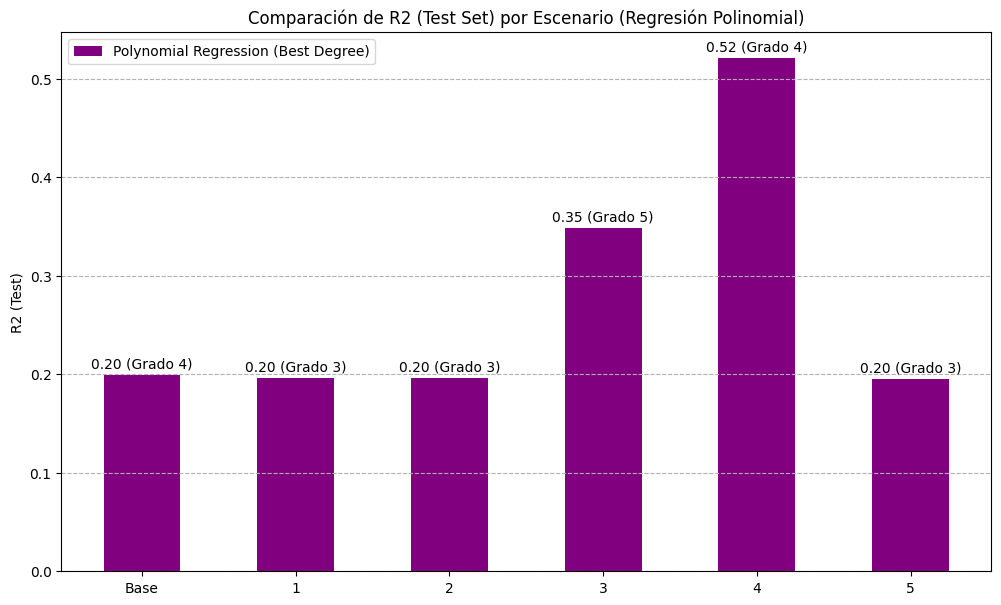

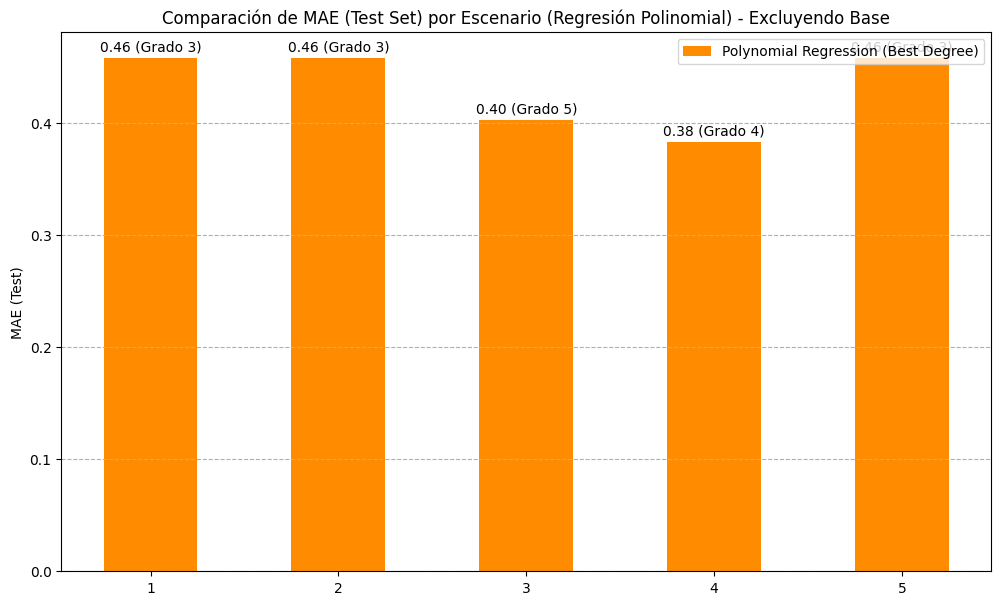

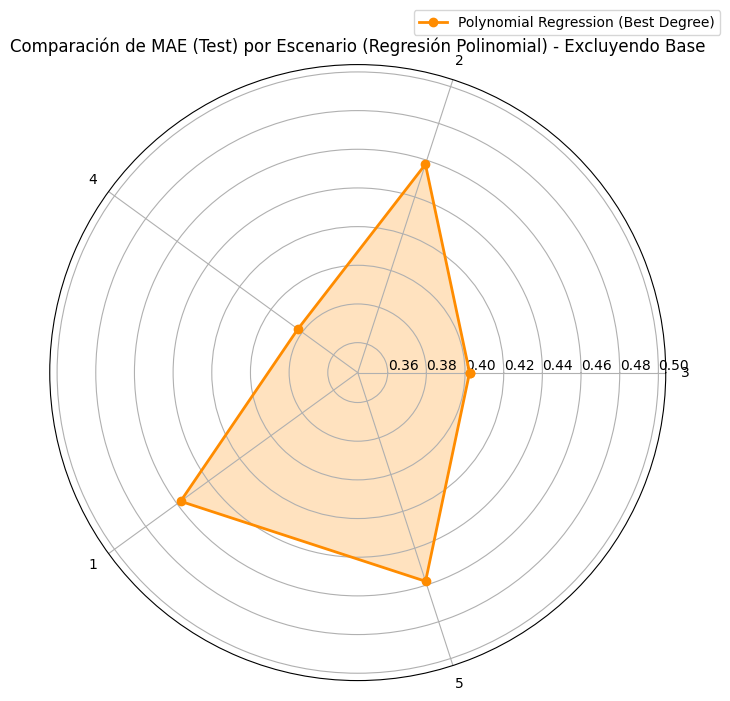

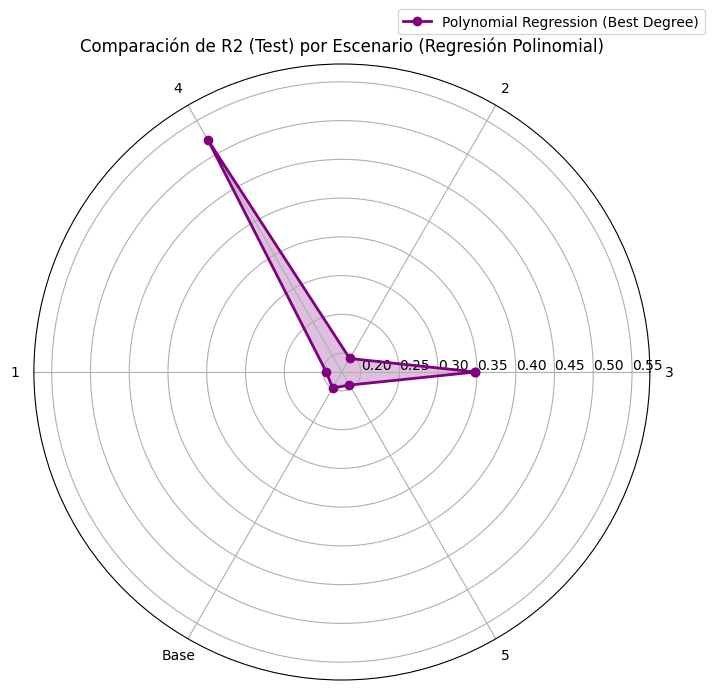

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Reutilizamos los resultados de métricas de Regresión Polinomial
# Asegúrate de que la variable resultados_metricas_poly esté disponible

# Define color palettes for MAE and R2
mae_color = 'darkorange' # Using different colors for Polynomial plots
r2_color = 'purple'


# Function to find the best MAE/R2 and the corresponding degree for each scenario from the Polynomial results
def get_best_poly_metrics_with_degree(results_dict, metric):
    best_metrics = {}
    best_degrees = {}
    # Assuming scenario names are the base names before '-grado X'
    scenario_names = set([k.split('-grado')[0] for k in results_dict.keys()])

    for scenario in scenario_names:
        best_value = float('inf') if 'MAE' in metric else -float('inf')
        best_degree = None
        # Filter results for the current scenario
        scenario_results = {k: v for k, v in results_dict.items() if k.startswith(f'{scenario}-')}
        if scenario_results:
            for degree_key, metrics in scenario_results.items():
                 current_value = metrics[metric]
                 # Extract the degree number from the key
                 degree_num = int(degree_key.split('-grado ')[1])
                 if ('MAE' in metric and current_value < best_value) or ('R2' in metric and current_value > best_value):
                    best_value = current_value
                    best_degree = degree_num
            best_metrics[scenario] = best_value
            best_degrees[scenario] = best_degree
        else:
             best_metrics[scenario] = np.nan # Handle scenarios not run with poly
             best_degrees[scenario] = None # Handle scenarios not run with poly
    return best_metrics, best_degrees

# Get the best MAE and R2 and corresponding degrees for each scenario across different degrees
best_mae_test_poly, best_mae_degrees = get_best_poly_metrics_with_degree(resultados_metricas_poly, 'MAE_Test')
best_r2_test_poly, best_r2_degrees = get_best_poly_metrics_with_degree(resultados_metricas_poly, 'R2_Test')


# --- Bar Plot para R2 (Test) - Escenarios Base, 1, 2, 3, 4, 5 ---
metric = 'R2_Test'
scenarios_to_plot = ['Base', '1', '2', '3', '4', '5']

# Extract data and degrees for the selected scenarios and metric for Polynomial Regression
r2_data_poly = [best_r2_test_poly.get(scenario, np.nan) for scenario in scenarios_to_plot] # Use .get to handle missing scenarios
r2_degrees_to_plot = [best_r2_degrees.get(scenario, None) for scenario in scenarios_to_plot]


x = np.arange(len(scenarios_to_plot))
width = 0.5 # Adjust width for single bars

fig1, ax1 = plt.subplots(figsize=(12, 7))

rects_poly_r2 = ax1.bar(x, r2_data_poly, width, label='Polynomial Regression (Best Degree)', color=r2_color)

ax1.set_ylabel('R2 (Test)')
ax1.set_title('Comparación de R2 (Test Set) por Escenario (Regresión Polinomial)')
ax1.set_xticks(x)
ax1.set_xticklabels(scenarios_to_plot)
ax1.legend()
ax1.grid(axis='y', linestyle='--')

# Add value and degree labels on top of bars
for i, rect in enumerate(rects_poly_r2):
    height = rect.get_height()
    degree = r2_degrees_to_plot[i]
    if not np.isnan(height): # Only add label if not NaN
        ax1.annotate(f'{height:.2f} (Grado {degree})',
                     xy=(rect.get_x() + rect.get_width() / 2, height),
                     xytext=(0, 3),  # 3 points vertical offset
                     textcoords="offset points",
                     ha='center', va='bottom')


plt.show()


# --- Bar Plot para MAE (Test) - Escenarios 1, 2, 3, 4, 5 ---
metric = 'MAE_Test'
scenarios_to_plot_mae = ['1', '2', '3', '4', '5'] # Excluye Escenario Base

# Extract data and degrees for the selected scenarios and metric for Polynomial Regression
mae_data_poly = [best_mae_test_poly.get(scenario, np.nan) for scenario in scenarios_to_plot_mae] # Use .get to handle missing scenarios
mae_degrees_to_plot = [best_mae_degrees.get(scenario, None) for scenario in scenarios_to_plot_mae]


x_mae = np.arange(len(scenarios_to_plot_mae))

fig2, ax2 = plt.subplots(figsize=(12, 7))

rects_poly_mae = ax2.bar(x_mae, mae_data_poly, width, label='Polynomial Regression (Best Degree)', color=mae_color)

ax2.set_ylabel('MAE (Test)')
ax2.set_title('Comparación de MAE (Test Set) por Escenario (Regresión Polinomial) - Excluyendo Base')
ax2.set_xticks(x_mae)
ax2.set_xticklabels(scenarios_to_plot_mae)
ax2.legend()
ax2.grid(axis='y', linestyle='--')

# Add value and degree labels on top of bars
for i, rect in enumerate(rects_poly_mae):
    height = rect.get_height()
    degree = mae_degrees_to_plot[i]
    if not np.isnan(height): # Only add label if not NaN
        ax2.annotate(f'{height:.2f} (Grado {degree})',
                     xy=(rect.get_x() + rect.get_width() / 2, height),
                     xytext=(0, 3),  # 3 points vertical offset
                     textcoords="offset points",
                     ha='center', va='bottom')


plt.show()


# --- Gráficos polares para métricas de test (Regresión Polinomial) ---
# Filter out 'Base' scenario for MAE polar plot and handle potential NaN values
escenarios_nombres_polar_mae = [esc for esc in best_mae_test_poly.keys() if esc != 'Base' and not pd.isna(best_mae_test_poly[esc])]
num_scenarios_polar_mae = len(escenarios_nombres_polar_mae)

# Only proceed if there are valid scenarios to plot
if num_scenarios_polar_mae > 0:
    angles_polar_mae = np.linspace(0, 2 * np.pi, num_scenarios_polar_mae, endpoint=False).tolist()
    angles_polar_mae += angles_polar_mae[:1] # Cerrar el círculo

    fig_mae_test_polar, ax_mae_test_polar = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Obtener los valores de MAE (Test) para Polynomial Regression (excluding Base and NaN)
    valores_mae_test_poly_polar = [best_mae_test_poly[escenario] for escenario in escenarios_nombres_polar_mae]
    valores_mae_test_poly_polar += valores_mae_test_poly_polar[:1] # Cerrar el círculo


    # Trazar la línea para Polynomial Regression
    ax_mae_test_polar.plot(angles_polar_mae, valores_mae_test_poly_polar, 'o-', linewidth=2, color=mae_color, label='Polynomial Regression (Best Degree)')
    ax_mae_test_polar.fill(angles_polar_mae, valores_mae_test_poly_polar, alpha=0.25, color=mae_color)


    ax_mae_test_polar.set_thetagrids(np.array(angles_polar_mae[:-1]) * 180 / np.pi, escenarios_nombres_polar_mae)
    ax_mae_test_polar.set_title('Comparación de MAE (Test) por Escenario (Regresión Polinomial) - Excluyendo Base', va='bottom')
    ax_mae_test_polar.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

    # Ajustar límite radial para MAE (Test) - un valor más bajo es mejor (más cerca del centro)
    min_mae_test_poly_polar = min(best_mae_test_poly[escenario] for escenario in escenarios_nombres_polar_mae)
    max_mae_test_poly_polar = max(best_mae_test_poly[escenario] for escenario in escenarios_nombres_polar_mae)
    ax_mae_test_polar.set_ylim(min_mae_test_poly_polar * 0.9, max_mae_test_poly_polar * 1.1) # Escala normal (mayor valor = más lejos del centro)
    ax_mae_test_polar.set_rlabel_position(0) # Posicionar etiquetas radiales
    ax_mae_test_polar.grid(True)

    plt.show()
else:
    print("No valid scenarios found for MAE polar plot (excluding Base).")


# Gráfico polar para R2 (Test) - Keep all scenarios for R2
# Handle potential NaN values for R2 polar plot
escenarios_nombres_polar_r2 = [esc for esc in best_r2_test_poly.keys() if not pd.isna(best_r2_test_poly[esc])]
num_scenarios_polar_r2 = len(escenarios_nombres_polar_r2)

# Only proceed if there are valid scenarios to plot
if num_scenarios_polar_r2 > 0:
    angles_polar_r2 = np.linspace(0, 2 * np.pi, num_scenarios_polar_r2, endpoint=False).tolist()
    angles_polar_r2 += angles_polar_r2[:1] # Cerrar el círculo

    fig_r2_test_polar, ax_r2_test_polar = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Obtener los valores de R2 (Test) para Polynomial Regression (excluding NaN)
    valores_r2_test_poly_polar = [best_r2_test_poly[escenario] for escenario in escenarios_nombres_polar_r2]
    valores_r2_test_poly_polar += valores_r2_test_poly_polar[:1] # Cerrar el círculo

    # Trazar la línea para Polynomial Regression
    ax_r2_test_polar.plot(angles_polar_r2, valores_r2_test_poly_polar, 'o-', linewidth=2, color=r2_color, label='Polynomial Regression (Best Degree)')
    ax_r2_test_polar.fill(angles_polar_r2, valores_r2_test_poly_polar, alpha=0.25, color=r2_color)


    ax_r2_test_polar.set_thetagrids(np.array(angles_polar_r2[:-1]) * 180 / np.pi, escenarios_nombres_polar_r2)
    ax_r2_test_polar.set_title('Comparación de R2 (Test) por Escenario (Regresión Polinomial)', va='bottom')
    ax_r2_test_polar.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

    # Ajustar límite radial para R2 (Test) - un valor más alto es mejor (más lejos del centro)
    min_r2_test_poly_polar = min(best_r2_test_poly[escenario] for escenario in escenarios_nombres_polar_r2)
    max_r2_test_poly_polar = max(best_r2_test_poly[escenario] for escenario in escenarios_nombres_polar_r2)
    ax_r2_test_polar.set_ylim(min_r2_test_poly_polar * 0.9, max_r2_test_poly_polar * 1.1) # Escala normal (mayor valor = más lejos del centro)
    ax_r2_test_polar.set_rlabel_position(0) # Posicionar etiquetas radiales
    ax_r2_test_polar.grid(True)

    plt.show()
else:
    print("No valid scenarios found for R2 polar plot.")

CON TODAS LAS CARACTERÍSTICAS

(NO SE PUDO CORRER PORQUE SE QUEDA SIN RAM)

In [41]:
"""from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Diccionario para almacenar los resultados de las métricas por escenario y set
resultados_metricas = {}

# Diccionario de escenarios y sus datos
escenarios = {
    'Base': (X_train_final_escBase, X_test_final_escBase, y_train_final_escBase, y_test_final_escBase),
    '1': (X_train_final_esc1, X_test_final_esc1, y_train_final_esc1, y_test_final_esc1),
    '2': (X_train_final_esc2, X_test_final_esc2, y_train_final_esc2, y_test_final_esc2),
    '3': (X_train_final_esc3, X_test_final_esc3, y_train_final_esc3, y_test_final_esc3),
    '4': (X_train_final_esc4, X_test_final_esc4, y_train_final_esc4, y_test_final_esc4),
    '5': (X_train_final_esc5, X_test_final_esc5, y_train_final_esc5, y_test_final_esc5)
}

# Iterar sobre cada escenario
for nombre_escenario, (X_train, X_test, y_train, y_test) in escenarios.items():

  #Definimos los grados por los qu vamos a probar
  degrees = [1, 2, 3, 4, 5, 6, 7, 8, 9]

  # Iteramos para cada grado
  for degree in degrees:

    # Instanciar y entrenar
    pf = PolynomialFeatures(degree)
    lr = LinearRegression(fit_intercept=False)
    model = make_pipeline(pf, lr)
    model.fit(X_train, y_train)

    # Predecir
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # 2) Calcular métricas: MAE y R2 para entrenamiento
    mae_train = mean_absolute_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)

    # Calcular métricas: MAE y R2 para prueba
    mae_test = mean_absolute_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Almacenar los resultados
    escenario_grado = f"{nombre_escenario}-grado {degree}"
    resultados_metricas[escenario_grado] = {
        'MAE_Train': mae_train,
        'R2_Train': r2_train,
        'MAE_Test': mae_test,
        'R2_Test': r2_test
        }

    print(f"--- Evaluando Escenario: {nombre_escenario} (Grado {degree}) ---")
    print(f"  MAE (Train): {mae_train:.2f}")
    print(f"  R2 (Train): {r2_train:.2f}")
    print(f"  MAE (Test): {mae_test:.2f}")
    print(f"  R2 (Test): {r2_test:.2f}")
    print("-" * (len(nombre_escenario) + 20))

# Mostrar los resultados en una tabla
resultados_df = pd.DataFrame(resultados_metricas).T
print("\nResumen de Métricas por Escenario (Train y Test):")
display(resultados_df)

mejor_resultado = resultados_df.loc[resultados_df['MAE_Test'].idxmin()]
print("\nMejor resultado:")
display(mejor_resultado)"""

'from sklearn.linear_model import LinearRegression\nfrom sklearn.preprocessing import PolynomialFeatures\nfrom sklearn.pipeline import make_pipeline\nfrom sklearn.metrics import mean_squared_error, mean_absolute_error\n\n# Diccionario para almacenar los resultados de las métricas por escenario y set\nresultados_metricas = {}\n\n# Diccionario de escenarios y sus datos\nescenarios = {\n    \'Base\': (X_train_final_escBase, X_test_final_escBase, y_train_final_escBase, y_test_final_escBase),\n    \'1\': (X_train_final_esc1, X_test_final_esc1, y_train_final_esc1, y_test_final_esc1),\n    \'2\': (X_train_final_esc2, X_test_final_esc2, y_train_final_esc2, y_test_final_esc2),\n    \'3\': (X_train_final_esc3, X_test_final_esc3, y_train_final_esc3, y_test_final_esc3),\n    \'4\': (X_train_final_esc4, X_test_final_esc4, y_train_final_esc4, y_test_final_esc4),\n    \'5\': (X_train_final_esc5, X_test_final_esc5, y_train_final_esc5, y_test_final_esc5)\n}\n\n# Iterar sobre cada escenario\nfor nombre_

## 3.5. RANDOM FOREST

### 3.5.1 PARAMETROS POR DEFECTO

In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# Diccionario para almacenar los resultados de las métricas por escenario y set para Random Forest
resultados_metricas_rf = {}

# Reutilizamos los escenarios y sus datos
escenarios = {
    'Base': (X_train_final_escBase, X_test_final_escBase, y_train_final_escBase, y_test_final_escBase),
     '1': (X_train_final_esc1, X_test_final_esc1, y_train_final_esc1, y_test_final_esc1),
     '2': (X_train_final_esc2, X_test_final_esc2, y_train_final_esc2, y_test_final_esc2),
     '3': (X_train_final_esc3, X_test_final_esc3, y_train_final_esc3, y_test_final_esc3),
     '4': (X_train_final_esc4, X_test_final_esc4, y_train_final_esc4, y_test_final_esc4),
     '5': (X_train_final_esc5, X_test_final_esc5, y_train_final_esc5, y_test_final_esc5)
}

# Iterar sobre cada escenario
for nombre_escenario, (X_train, X_test, y_train, y_test) in escenarios.items():
    print(f"--- Evaluando Escenario: {nombre_escenario} (Random Forest Regressor) ---")

    # 1) Crear y entrenar el modelo de Random Forest Regressor
    # Usamos parámetros por defecto para empezar, se pueden ajustar después
    modelo_rf = RandomForestRegressor(random_state=42)
    modelo_rf.fit(X_train, y_train)

    # Realizar predicciones en el conjunto de entrenamiento y prueba
    y_train_pred_rf = modelo_rf.predict(X_train)
    y_test_pred_rf = modelo_rf.predict(X_test)

    # 2) Calcular métricas: MAE y R2 para entrenamiento
    mae_train_rf = mean_absolute_error(y_train, y_train_pred_rf)
    r2_train_rf = r2_score(y_train, y_train_pred_rf)

    # Calcular métricas: MAE y R2 para prueba
    mae_test_rf = mean_absolute_error(y_test, y_test_pred_rf)
    r2_test_rf = r2_score(y_test, y_test_pred_rf)

    # Almacenar los resultados
    resultados_metricas_rf[nombre_escenario] = {
        'MAE_Train': mae_train_rf,
        'R2_Train': r2_train_rf,
        'MAE_Test': mae_test_rf,
        'R2_Test': r2_test_rf
    }

    print(f"  MAE (Train): {mae_train_rf:.2f}")
    print(f"  R2 (Train): {r2_train_rf:.2f}")
    print(f"  MAE (Test): {mae_test_rf:.2f}")
    print(f"  R2 (Test): {r2_test_rf:.2f}")
    print("-" * (len(nombre_escenario) + 40))

# Mostrar los resultados en una tabla
resultados_df_rf = pd.DataFrame(resultados_metricas_rf).T
print("\nResumen de Métricas por Escenario (Train y Test - Random Forest Regressor):")
display(resultados_df_rf)

--- Evaluando Escenario: Base (Random Forest Regressor) ---
  MAE (Train): 24.32
  R2 (Train): 0.93
  MAE (Test): 63.94
  R2 (Test): 0.53
--------------------------------------------
--- Evaluando Escenario: 1 (Random Forest Regressor) ---
  MAE (Train): 0.13
  R2 (Train): 0.93
  MAE (Test): 0.34
  R2 (Test): 0.53
-----------------------------------------
--- Evaluando Escenario: 2 (Random Forest Regressor) ---
  MAE (Train): 0.14
  R2 (Train): 0.92
  MAE (Test): 0.36
  R2 (Test): 0.44
-----------------------------------------
--- Evaluando Escenario: 3 (Random Forest Regressor) ---
  MAE (Train): 0.11
  R2 (Train): 0.94
  MAE (Test): 0.30
  R2 (Test): 0.62
-----------------------------------------
--- Evaluando Escenario: 4 (Random Forest Regressor) ---
  MAE (Train): 0.10
  R2 (Train): 0.95
  MAE (Test): 0.28
  R2 (Test): 0.65
-----------------------------------------
--- Evaluando Escenario: 5 (Random Forest Regressor) ---
  MAE (Train): 0.13
  R2 (Train): 0.93
  MAE (Test): 0.34
  

,MAE_Train,R2_Train,MAE_Test,R2_Test
Base,24.323478,0.931073,63.940251,0.526417
1,0.130650,0.931218,0.343547,0.526796
2,0.138430,0.921057,0.364154,0.443820
3,0.111406,0.943571,0.298084,0.615580
4,0.104104,0.949403,0.278699,0.651401
5,0.128473,0.933163,0.337893,0.543658


#### GRAFICOS

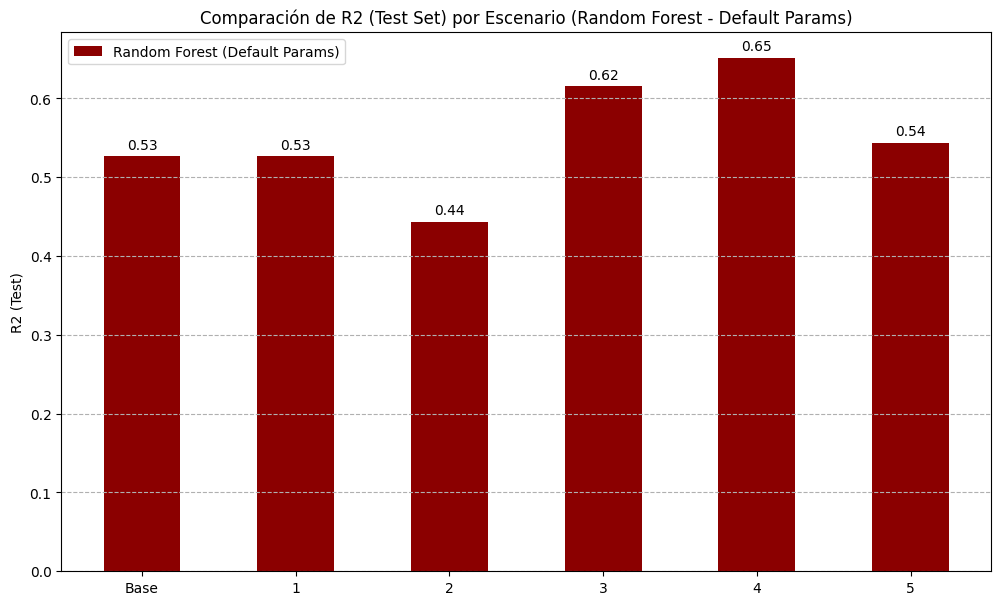

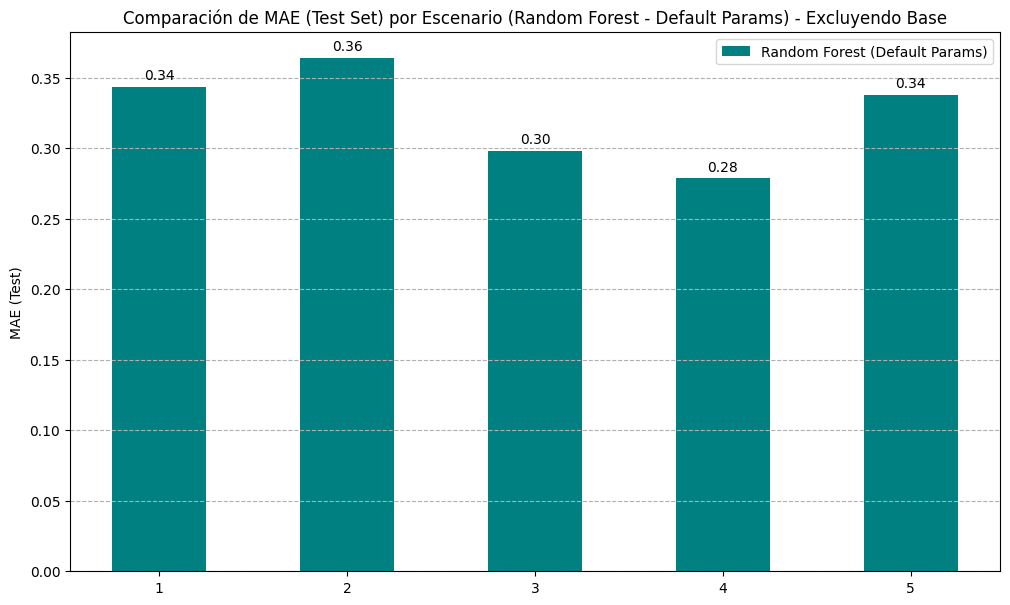

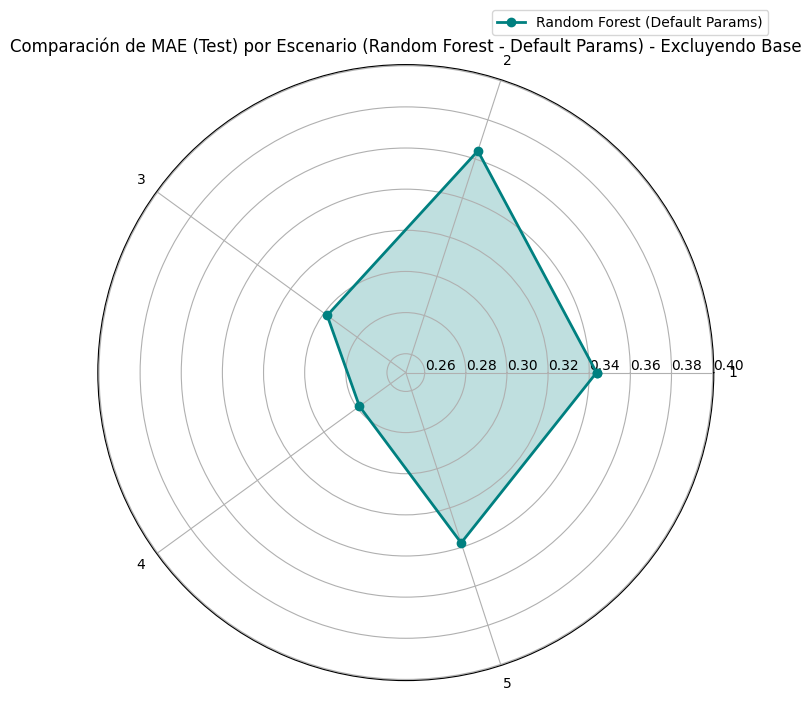

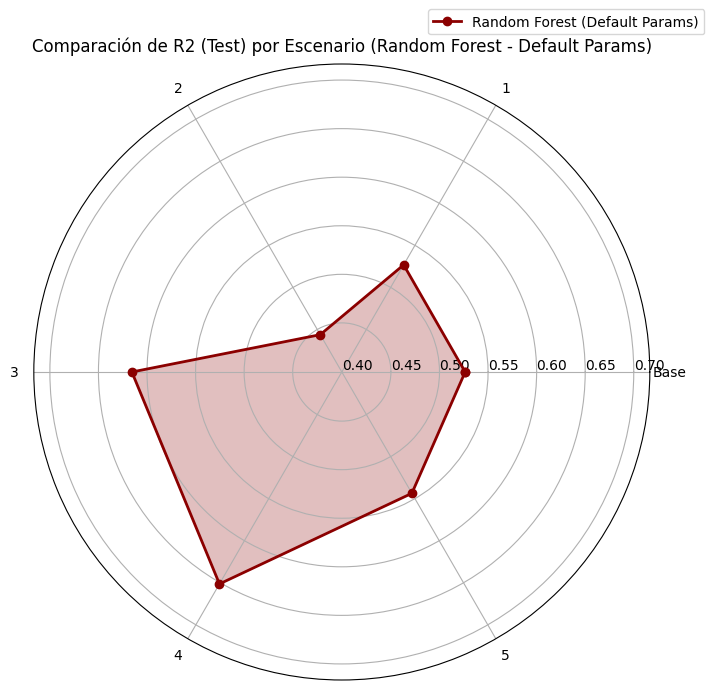

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Reutilizamos los resultados de métricas de Random Forest (Default Params)
# Asegúrate de que la variable resultados_metricas_rf esté disponible

# Define color palettes for MAE and R2
mae_color = 'teal' # Using different colors for Random Forest Default plots
r2_color = 'darkred'


# --- Bar Plot para R2 (Test) - Escenarios Base, 1, 2, 3, 4, 5 ---
metric = 'R2_Test'
scenarios_to_plot = ['Base', '1', '2', '3', '4', '5']

# Extract data for the selected scenarios and metric for Random Forest Default
r2_data_rf_default = [resultados_metricas_rf.get(scenario, {}).get(metric, np.nan) for scenario in scenarios_to_plot]


x = np.arange(len(scenarios_to_plot))
width = 0.5 # Adjust width for single bars

fig1, ax1 = plt.subplots(figsize=(12, 7))

rects_rf_default_r2 = ax1.bar(x, r2_data_rf_default, width, label='Random Forest (Default Params)', color=r2_color)

ax1.set_ylabel('R2 (Test)')
ax1.set_title('Comparación de R2 (Test Set) por Escenario (Random Forest - Default Params)')
ax1.set_xticks(x)
ax1.set_xticklabels(scenarios_to_plot)
ax1.legend()
ax1.grid(axis='y', linestyle='--')

# Add value labels on top of bars
for rect in rects_rf_default_r2:
    height = rect.get_height()
    if not np.isnan(height): # Only add label if not NaN
        ax1.annotate(f'{height:.2f}',
                     xy=(rect.get_x() + rect.get_width() / 2, height),
                     xytext=(0, 3),  # 3 points vertical offset
                     textcoords="offset points",
                     ha='center', va='bottom')


plt.show()


# --- Bar Plot para MAE (Test) - Escenarios 1, 2, 3, 4, 5 ---
metric = 'MAE_Test'
scenarios_to_plot_mae = ['1', '2', '3', '4', '5'] # Excluye Escenario Base

# Extract data for the selected scenarios and metric for Random Forest Default
mae_data_rf_default = [resultados_metricas_rf.get(scenario, {}).get(metric, np.nan) for scenario in scenarios_to_plot_mae]


x_mae = np.arange(len(scenarios_to_plot_mae))

fig2, ax2 = plt.subplots(figsize=(12, 7))

rects_rf_default_mae = ax2.bar(x_mae, mae_data_rf_default, width, label='Random Forest (Default Params)', color=mae_color)

ax2.set_ylabel('MAE (Test)')
ax2.set_title('Comparación de MAE (Test Set) por Escenario (Random Forest - Default Params) - Excluyendo Base')
ax2.set_xticks(x_mae)
ax2.set_xticklabels(scenarios_to_plot_mae)
ax2.legend()
ax2.grid(axis='y', linestyle='--')

# Add value labels on top of bars
for rect in rects_rf_default_mae:
    height = rect.get_height()
    if not np.isnan(height): # Only add label if not NaN
        ax2.annotate(f'{height:.2f}',
                     xy=(rect.get_x() + rect.get_width() / 2, height),
                     xytext=(0, 3),  # 3 points vertical offset
                     textcoords="offset points",
                     ha='center', va='bottom')


plt.show()


# --- Gráficos polares para métricas de test (Random Forest - Default Params) ---
# Filter out 'Base' scenario for MAE polar plot and handle potential missing scenarios/NaN values
escenarios_nombres_polar_mae = [esc for esc in resultados_metricas_rf.keys() if esc != 'Base' and resultados_metricas_rf.get(esc, {}).get('MAE_Test') is not None and not pd.isna(resultados_metricas_rf.get(esc, {}).get('MAE_Test'))]
num_scenarios_polar_mae = len(escenarios_nombres_polar_mae)

# Only proceed if there are valid scenarios to plot
if num_scenarios_polar_mae > 0:
    angles_polar_mae = np.linspace(0, 2 * np.pi, num_scenarios_polar_mae, endpoint=False).tolist()
    angles_polar_mae += angles_polar_mae[:1] # Cerrar el círculo

    fig_mae_test_polar, ax_mae_test_polar = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Obtener los valores de MAE (Test) para Random Forest Default (excluding Base and NaN)
    valores_mae_test_rf_default_polar = [resultados_metricas_rf[escenario]['MAE_Test'] for escenario in escenarios_nombres_polar_mae]
    valores_mae_test_rf_default_polar += valores_mae_test_rf_default_polar[:1] # Cerrar el círculo


    # Trazar la línea para Random Forest Default
    ax_mae_test_polar.plot(angles_polar_mae, valores_mae_test_rf_default_polar, 'o-', linewidth=2, color=mae_color, label='Random Forest (Default Params)')
    ax_mae_test_polar.fill(angles_polar_mae, valores_mae_test_rf_default_polar, alpha=0.25, color=mae_color)


    ax_mae_test_polar.set_thetagrids(np.array(angles_polar_mae[:-1]) * 180 / np.pi, escenarios_nombres_polar_mae)
    ax_mae_test_polar.set_title('Comparación de MAE (Test) por Escenario (Random Forest - Default Params) - Excluyendo Base', va='bottom')
    ax_mae_test_polar.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

    # Adjust radial limit for MAE (Test) - lower value is better (closer to center)
    min_mae_test_rf_default_polar = min(resultados_metricas_rf[escenario]['MAE_Test'] for escenario in escenarios_nombres_polar_mae)
    max_mae_test_rf_default_polar = max(resultados_metricas_rf[escenario]['MAE_Test'] for escenario in escenarios_nombres_polar_mae)
    ax_mae_test_polar.set_ylim(min_mae_test_rf_default_polar * 0.9, max_mae_test_rf_default_polar * 1.1) # Normal scale (higher value = further from center)
    ax_mae_test_polar.set_rlabel_position(0) # Position radial labels
    ax_mae_test_polar.grid(True)

    plt.show()
else:
    print("No valid scenarios found for MAE polar plot (excluding Base).")


# Gráfico polar para R2 (Test) - Keep all scenarios for R2
# Handle potential missing scenarios/NaN values for R2 polar plot
escenarios_nombres_polar_r2 = [esc for esc in resultados_metricas_rf.keys() if resultados_metricas_rf.get(esc, {}).get('R2_Test') is not None and not pd.isna(resultados_metricas_rf.get(esc, {}).get('R2_Test'))]
num_scenarios_polar_r2 = len(escenarios_nombres_polar_r2)

# Only proceed if there are valid scenarios to plot
if num_scenarios_polar_r2 > 0:
    angles_polar_r2 = np.linspace(0, 2 * np.pi, num_scenarios_polar_r2, endpoint=False).tolist()
    angles_polar_r2 += angles_polar_r2[:1] # Cerrar el círculo

    fig_r2_test_polar, ax_r2_test_polar = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Obtener los valores de R2 (Test) para Random Forest Default (excluding NaN)
    valores_r2_test_rf_default_polar = [resultados_metricas_rf[escenario]['R2_Test'] for escenario in escenarios_nombres_polar_r2]
    valores_r2_test_rf_default_polar += valores_r2_test_rf_default_polar[:1] # Cerrar el círculo

    # Trazar la línea para Random Forest Default
    ax_r2_test_polar.plot(angles_polar_r2, valores_r2_test_rf_default_polar, 'o-', linewidth=2, color=r2_color, label='Random Forest (Default Params)')
    ax_r2_test_polar.fill(angles_polar_r2, valores_r2_test_rf_default_polar, alpha=0.25, color=r2_color)


    ax_r2_test_polar.set_thetagrids(np.array(angles_polar_r2[:-1]) * 180 / np.pi, escenarios_nombres_polar_r2)
    ax_r2_test_polar.set_title('Comparación de R2 (Test) por Escenario (Random Forest - Default Params)', va='bottom')
    ax_r2_test_polar.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

    # Adjust radial limit for R2 (Test) - higher value is better (further from center)
    min_r2_test_rf_default_polar = min(resultados_metricas_rf[escenario]['R2_Test'] for escenario in escenarios_nombres_polar_r2)
    max_r2_test_rf_default_polar = max(resultados_metricas_rf[escenario]['R2_Test'] for escenario in escenarios_nombres_polar_r2)
    ax_r2_test_polar.set_ylim(min_r2_test_rf_default_polar * 0.9, max_r2_test_rf_default_polar * 1.1) # Normal scale (higher value = further from center)
    ax_r2_test_polar.set_rlabel_position(0) # Position radial labels
    ax_r2_test_polar.grid(True)

    plt.show()
else:
    print("No valid scenarios found for R2 polar plot.")

### 3.5.2 MEJOR MODELO (OPTUNA-GRIDSEARCH)

#### 3.5.2.1 IMPLEMENTACION DE OPTUNA

In [44]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
import optuna # Import optuna if not already imported

def objective(trial, X_train, y_train):
    """Objective function for Optuna."""

    # Define hyperparameters to tune with a wider range and more options
    n_estimators = trial.suggest_int('n_estimators', 100, 1000) # Increased range
    max_depth = trial.suggest_int('max_depth', 10, 30) # Increased range
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10) # Adjusted range
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5) # Adjusted range
    max_features = trial.suggest_float('max_features', 0.5, 1.0) # Adjusted range
    # Add more hyperparameters to tune here
    min_impurity_decrease = trial.suggest_float('min_impurity_decrease', 0.0, 0.1)
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])


    # Create the Random Forest Regressor model with suggested hyperparameters
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        min_impurity_decrease=min_impurity_decrease,
        bootstrap=bootstrap,
        random_state=42,
        n_jobs=-1 # Use all available cores
    )

    # Evaluate the model using cross-validation (e.g., 5-fold cross-validation)
    # We use negative MAE because Optuna maximizes by default. Minimizing MAE is equivalent
    # to maximizing negative MAE.
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)

    # Return the average negative MAE across folds
    return score.mean()

Con el fin de implementar esta nueva técnica para poder comparar su rendimiento la hemos aplicado sólo en el escenario 3 que posee la menor cantidad de datos por un cuestión de tiempo.

In [45]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# Diccionario para almacenar los mejores parámetros y métricas por escenario
best_params_by_scenario = {}
best_metrics_by_scenario = {}

# Reutilizamos los escenarios y sus datos
# escenarios = {
#     'Base': (X_train_final_escBase, X_test_final_escBase, y_train_final_escBase, y_test_final_escBase),
#     '1': (X_train_final_esc1, X_test_final_esc1, y_train_final_esc1, y_test_final_esc1),
#     '2': (X_train_final_esc2, X_test_final_esc2, y_train_final_esc2, y_test_final_esc2),
#     '3': (X_train_final_esc3, X_test_final_esc3, y_train_final_esc3, y_test_final_esc3),
#     '4': (X_train_final_esc4, X_test_final_esc4, y_train_final_esc4, y_test_final_esc4),
#     '5': (X_train_final_esc5, X_test_final_esc5, y_train_final_esc5, y_test_final_esc5)
# }

# Asegúrate de que la función 'objective' esté definida en una celda anterior

# Número de pruebas para Optuna (puedes ajustar este valor)
n_trials = 15

# Iterar sobre cada escenario - MODIFIED TO PROCESS SCENARIOS '3' AND '4'
# Using the full scenario dictionary to access the data for scenarios '3' and '4'
for nombre_escenario, (X_train, X_test, y_train, y_test) in {key: escenarios[key] for key in ['3', '4']}.items():
    #Seleccionamos la variable calificacion_energystar - Removed feature selection as it was not in the original scenario 4
    # features = ['calificacion_energystar', 'nevada_mm', 'grados_dia_calefaccion','dias_menos_1C','grados_dia_enfriamiento']
    # X_train = X_train[features]
    # X_test = X_test[features]

    print(f"--- Iniciando búsqueda de hiperparámetros con Optuna para Escenario: {nombre_escenario} ---")

    # Crear un estudio de Optuna
    # direction='minimize' porque nuestra función objetivo devuelve el MAE negativo (para minimizar MAE)
    study = optuna.create_study(direction='maximize')

    # Ejecutar la optimización
    study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=n_trials)

    print(f"  Mejor ensayo para Escenario {nombre_escenario}:")
    print(f"  Valor (MAE Negativo): {study.best_value:.2f}")
    print(f"  Mejores Parámetros: {study.best_params}")

    # Almacenar los mejores parámetros
    best_params_by_scenario[nombre_escenario] = study.best_params

    # Entrenar el modelo con los mejores parámetros encontrados en el conjunto de entrenamiento completo
    print(f"  Entrenando modelo final para Escenario {nombre_escenario} con mejores parámetros...")
    best_rf_model = RandomForestRegressor(**study.best_params, random_state=42, n_jobs=-1)
    best_rf_model.fit(X_train, y_train)

    # Evaluar el modelo final en el conjunto de prueba
    y_test_pred_best_rf = best_rf_model.predict(X_test)

    mae_test_best_rf = mean_absolute_error(y_test, y_test_pred_best_rf)
    r2_test_best_rf = r2_score(y_test, y_test_pred_best_rf)

    # Almacenar las métricas en el conjunto de prueba
    best_metrics_by_scenario[nombre_escenario] = {
        'MAE_Test': mae_test_best_rf,
        'R2_Test': r2_test_best_rf
    }

    print(f"  Métricas en el conjunto de prueba para Escenario {nombre_escenario}:")
    print(f"    MAE (Test): {mae_test_best_rf:.2f}")
    print(f"    R2 (Test): {r2_test_best_rf:.2f}")
    print("-" * (len(nombre_escenario) + 50))

# Mostrar un resumen de los mejores parámetros encontrados por escenario
print("\nResumen de los Mejores Parámetros por Escenario:")
display(pd.DataFrame(best_params_by_scenario).T)

# Mostrar un resumen de las métricas en el conjunto de prueba para los mejores modelos por escenario
print("\nResumen de Métricas en el Conjunto de Prueba (Mejores Modelos RF por Escenario):")
display(pd.DataFrame(best_metrics_by_scenario).T)

[I 2025-10-04 20:58:04,225] A new study created in memory with name: no-name-c493497d-bf1d-4027-a823-294b477163df


--- Iniciando búsqueda de hiperparámetros con Optuna para Escenario: 3 ---


[I 2025-10-04 20:58:55,748] Trial 0 finished with value: -0.40040377549821143 and parameters: {'n_estimators': 587, 'max_depth': 16, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 0.7963303695356325, 'min_impurity_decrease': 0.005238313704535625, 'bootstrap': False}. Best is trial 0 with value: -0.40040377549821143.
[I 2025-10-04 20:59:03,828] Trial 1 finished with value: -0.5224985491794085 and parameters: {'n_estimators': 449, 'max_depth': 22, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.5702955130446893, 'min_impurity_decrease': 0.07715245865980165, 'bootstrap': False}. Best is trial 0 with value: -0.40040377549821143.
[I 2025-10-04 20:59:30,673] Trial 2 finished with value: -0.514158877479457 and parameters: {'n_estimators': 940, 'max_depth': 23, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': 0.7834354625891647, 'min_impurity_decrease': 0.0926558750198978, 'bootstrap': False}. Best is trial 0 with value: -0.40040377549821143.
[I 

  Mejor ensayo para Escenario 3:
  Valor (MAE Negativo): -0.35
  Mejores Parámetros: {'n_estimators': 115, 'max_depth': 11, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 0.6916792020159773, 'min_impurity_decrease': 0.0015142578719070862, 'bootstrap': True}
  Entrenando modelo final para Escenario 3 con mejores parámetros...


[I 2025-10-04 21:02:28,928] A new study created in memory with name: no-name-b3fd3db7-4a20-4456-ba18-ca8c3bf2dfdd


...

[I 2025-10-04 21:02:48,563] Trial 0 finished with value: -0.48849219510930614 and parameters: {'n_estimators': 632, 'max_depth': 17, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 0.5109033282245031, 'min_impurity_decrease': 0.05441086374602695, 'bootstrap': True}. Best is trial 0 with value: -0.48849219510930614.
[I 2025-10-04 21:03:23,143] Trial 1 finished with value: -0.4332812150911266 and parameters: {'n_estimators': 456, 'max_depth': 11, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.8380428971375016, 'min_impurity_decrease': 0.030141072512787217, 'bootstrap': True}. Best is trial 1 with value: -0.4332812150911266.
[I 2025-10-04 21:03:28,433] Trial 2 finished with value: -0.4865012947888778 and parameters: {'n_estimators': 110, 'max_depth': 21, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.5803817949580021, 'min_impurity_decrease': 0.09039968051723889, 'bootstrap': False}. Best is trial 1 with value: -0.4332812150911266.
[I 20

  Mejor ensayo para Escenario 4:
  Valor (MAE Negativo): -0.35
  Mejores Parámetros: {'n_estimators': 999, 'max_depth': 30, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 0.9825930852363373, 'min_impurity_decrease': 0.0005483412135561753, 'bootstrap': False}
  Entrenando modelo final para Escenario 4 con mejores parámetros...
  Métricas en el conjunto de prueba para Escenario 4:
    MAE (Test): 0.35
    R2 (Test): 0.57
---------------------------------------------------

Resumen de los Mejores Parámetros por Escenario:


,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,min_impurity_decrease,bootstrap
3,115,11,2,3,0.691679,0.001514,True
4,999,30,8,3,0.982593,0.000548,False



Resumen de Métricas en el Conjunto de Prueba (Mejores Modelos RF por Escenario):


,MAE_Test,R2_Test
3,0.350499,0.558169
4,0.347777,0.566586


##### GRAFICOS

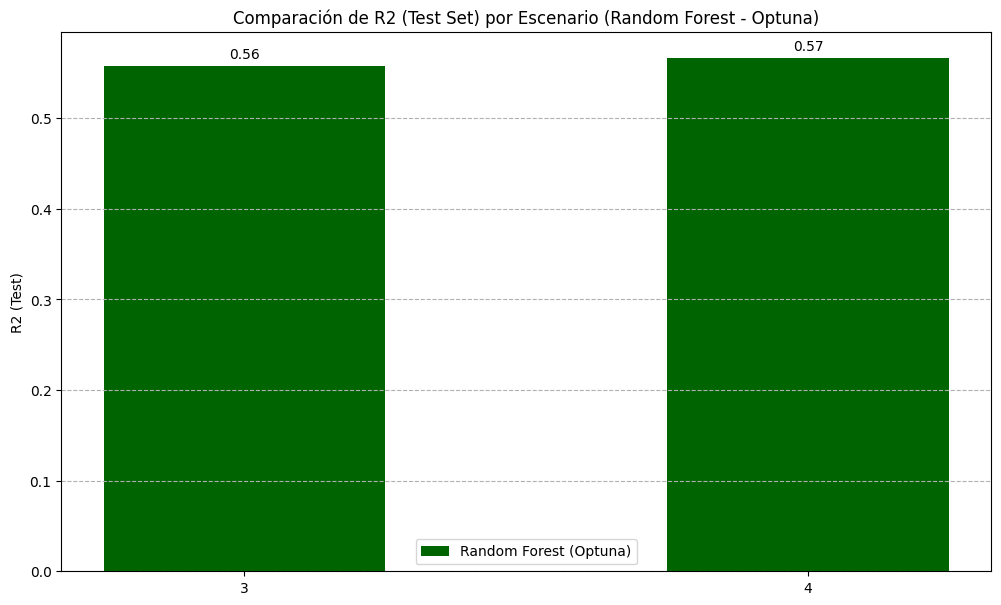

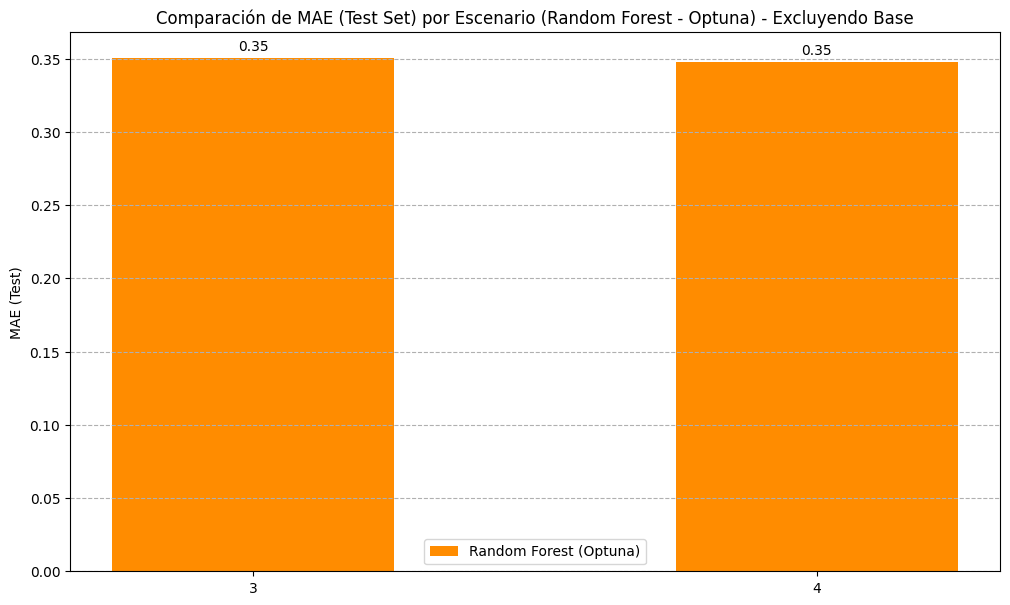

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Reutilizamos los resultados de métricas de Random Forest (Optuna)
# Asegúrate de que la variable best_metrics_by_scenario esté disponible

# Define color palettes for MAE and R2
mae_color = 'darkorange' # Using different colors for Optuna plots
r2_color = 'darkgreen'

# --- Bar Plot para R2 (Test) - Escenarios procesados por Optuna ---
metric = 'R2_Test'
# Get scenarios from the keys of best_metrics_by_scenario and sort them
scenarios_to_plot = sorted(best_metrics_by_scenario.keys())

if scenarios_to_plot: # Check if any scenarios were processed
    # Extract data for the selected scenarios and metric for Optuna
    r2_data_optuna = [best_metrics_by_scenario.get(scenario, {}).get(metric, np.nan) for scenario in scenarios_to_plot]


    x = np.arange(len(scenarios_to_plot))
    width = 0.5 # Adjust width for single bars

    fig1, ax1 = plt.subplots(figsize=(12, 7))

    rects_optuna_r2 = ax1.bar(x, r2_data_optuna, width, label='Random Forest (Optuna)', color=r2_color)

    ax1.set_ylabel('R2 (Test)')
    ax1.set_title('Comparación de R2 (Test Set) por Escenario (Random Forest - Optuna)')
    ax1.set_xticks(x)
    ax1.set_xticklabels(scenarios_to_plot)
    ax1.legend()
    ax1.grid(axis='y', linestyle='--')

    # Add value labels on top of bars
    for rect in rects_optuna_r2:
        height = rect.get_height()
        if not np.isnan(height): # Only add label if not NaN
            ax1.annotate(f'{height:.2f}',
                         xy=(rect.get_x() + rect.get_width() / 2, height),
                         xytext=(0, 3),  # 3 points vertical offset
                         textcoords="offset points",
                         ha='center', va='bottom')


    plt.show()


    # --- Bar Plot para MAE (Test) - Escenarios procesados por Optuna (Excluyendo Base) ---
    metric = 'MAE_Test'
    # Get scenarios from the keys of best_metrics_by_scenario, exclude Base, and sort them
    scenarios_to_plot_mae = sorted([esc for esc in best_metrics_by_scenario.keys() if esc != 'Base'])

    if scenarios_to_plot_mae:
        # Extract data for the selected scenarios and metric for Optuna
        mae_data_optuna = [best_metrics_by_scenario.get(scenario, {}).get(metric, np.nan) for scenario in scenarios_to_plot_mae]


        x_mae = np.arange(len(scenarios_to_plot_mae))

        fig2, ax2 = plt.subplots(figsize=(12, 7))

        rects_optuna_mae = ax2.bar(x_mae, mae_data_optuna, width, label='Random Forest (Optuna)', color=mae_color)

        ax2.set_ylabel('MAE (Test)')
        ax2.set_title('Comparación de MAE (Test Set) por Escenario (Random Forest - Optuna) - Excluyendo Base')
        ax2.set_xticks(x_mae)
        ax2.set_xticklabels(scenarios_to_plot_mae)
        ax2.legend()
        ax2.grid(axis='y', linestyle='--')

        # Add value labels on top of bars
        for rect in rects_optuna_mae:
            height = rect.get_height()
            if not np.isnan(height): # Only add label if not NaN
                ax2.annotate(f'{height:.2f}',
                             xy=(rect.get_x() + rect.get_width() / 2, height),
                             xytext=(0, 3),  # 3 points vertical offset
                             textcoords="offset points",
                             ha='center', va='bottom')


        plt.show()
    else:
        print("No valid scenarios found for MAE bar plot.")






#### 3.5.2.2 IMPLEMENTACION DE GRIDSEARCH

Con el fin de implementar esta técnica para poder comparar tambien su rendimiento, nuevamente la hemos aplicado sólo en el escenario 3 por un cuestión de tiempo.

(Poner a correr esta celda e ir a tomar un café, demora casi 2 hs)

In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# Diccionario para almacenar los mejores parámetros y métricas por escenario
best_params_by_scenario_gs = {}
best_metrics_by_scenario_gs = {}

# Reutilizamos los escenarios y sus datos (assuming 'escenarios' dictionary is available)
escenarios = {
    'Base': (X_train_final_escBase, X_test_final_escBase, y_train_final_escBase, y_test_final_escBase),
    '1': (X_train_final_esc1, X_test_final_esc1, y_train_final_esc1, y_test_final_esc1),
    '2': (X_train_final_esc2, X_test_final_esc2, y_train_final_esc2, y_test_final_esc2),
    '3': (X_train_final_esc3, X_test_final_esc3, y_train_final_esc3, y_test_final_esc3),
    '4': (X_train_final_esc4, X_test_final_esc4, y_train_final_esc4, y_test_final_esc4),
    '5': (X_train_final_esc5, X_test_final_esc5, y_train_final_esc5, y_test_final_esc5)
}

# Define the parameter grid for GridSearchCV
# This is a smaller grid for demonstration. You might want to expand this.
param_grid = {
    'n_estimators': [100, 1000],
    'max_depth': [10, 30],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 5]
}


# Define the scoring metrics
scoring = {
    'MAE': 'neg_mean_absolute_error',  # Negative MAE to maximize
    'R2': 'r2'
}


# Iterar sobre cada escenario - MODIFIED TO ONLY PROCESS SCENARIO '3'
for nombre_escenario, (X_train, X_test, y_train, y_test) in {key: escenarios[key] for key in ['3']}.items():

    print(f"--- Iniciando búsqueda de hiperparámetros con GridSearchCV para Escenario: {nombre_escenario} ---")

    # Create a base Random Forest Regressor model
    base_rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

    # Create GridSearchCV object
    grid_search = GridSearchCV(
        estimator=base_rf_model,
        param_grid=param_grid,
        scoring=scoring,
        refit='MAE',  # Refit the best model based on the best MAE (neg_mean_absolute_error)
        cv=5,  # 5-fold cross-validation
        n_jobs=-1, # Use all available cores
        verbose=2 # Increase verbosity to see progress
    )

    # Perform the grid search
    grid_search.fit(X_train, y_train)

    print(f"  Mejor ensayo para Escenario {nombre_escenario}:")
    print(f"  Mejor Puntuación (MAE Negativo): {grid_search.best_score_:.2f}")
    print(f"  Mejores Parámetros: {grid_search.best_params_}")

    # Store the best parameters
    best_params_by_scenario_gs[nombre_escenario] = grid_search.best_params_

    # Get the best model from the grid search
    best_rf_model_gs = grid_search.best_estimator_

    # Evaluate the best model on the test set
    y_test_pred_best_rf_gs = best_rf_model_gs.predict(X_test)

    mae_test_best_rf_gs = mean_absolute_error(y_test, y_test_pred_best_rf_gs)
    r2_test_best_rf_gs = r2_score(y_test, y_test_pred_best_rf_gs)

    # Store the metrics on the test set
    best_metrics_by_scenario_gs[nombre_escenario] = {
        'MAE_Test': mae_test_best_rf_gs,
        'R2_Test': r2_test_best_rf_gs
    }

    print(f"  Métricas en el conjunto de prueba para Escenario {nombre_escenario}:")
    print(f"    MAE (Test): {mae_test_best_rf_gs:.2f}")
    print(f"    R2 (Test): {r2_test_best_rf_gs:.2f}")
    print("-" * (len(nombre_escenario) + 50))

# Mostrar un resumen de los mejores parámetros encontrados por escenario
print("\nResumen de los Mejores Parámetros por Escenario (GridSearchCV):")
display(pd.DataFrame(best_params_by_scenario_gs).T)

# Mostrar un resumen de las métricas en el conjunto de prueba para los mejores modelos por escenario
print("\nResumen de Métricas en el Conjunto de Prueba (Mejores Modelos RF por Escenario - GridSearchCV):")
display(pd.DataFrame(best_metrics_by_scenario_gs).T)

--- Iniciando búsqueda de hiperparámetros con GridSearchCV para Escenario: 3 ---
Fitting 5 folds for each of 16 candidates, totalling 80 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  Mejor ensayo para Escenario 3:
  Mejor Puntuación (MAE Negativo): -0.31
  Mejores Parámetros: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 1000}
  Métricas en el conjunto de prueba para Escenario 3:
    MAE (Test): 0.30
    R2 (Test): 0.62
---------------------------------------------------

Resumen de los Mejores Parámetros por Escenario (GridSearchCV):


,max_depth,min_samples_leaf,min_samples_split,n_estimators
3,30,1,2,1000



Resumen de Métricas en el Conjunto de Prueba (Mejores Modelos RF por Escenario - GridSearchCV):


,MAE_Test,R2_Test
3,0.295489,0.621346


# 4. CONCLUSIONES

Tras aplicar los diferentes modelos de regresión a cada uno de los escenarios preprocesados, se comparan las métricas de rendimiento (MAE y R²) obtenidas en el conjunto de prueba para determinar cuál configuración ofrece los mejores resultados.

Se evaluaron los siguientes modelos y variaciones:

*   **Regresión Lineal (Todas las variables)**
*   **Regresión Lineal (5 variables más correlacionadas)**
*   **Regresión Ridge (con diferentes valores de alpha)**
*   **Regresión Polinomial (con diferentes grados y 5 variables)**
*   **Random Forest Regressor (con parámetros por defecto)**
*   **Random Forest Regressor (con hiperparámetros optimizados con Optuna y GridSearchCV)**

Se analizan los resultados obtenidos en cada uno de los 6 escenarios de preprocesamiento:

*   **Escenario Base:** Datos sin escalar, todas las features, imputación con `SimpleImputer` (media), encoding con `OneHotEncoder`.
*   **Escenario 1:** Datos escalados con `StandardScaler`, todas las features, imputación con `SimpleImputer` (media), encoding con `OneHotEncoder`.
*   **Escenario 2:** Datos escalados con `StandardScaler`, features seleccionadas (eliminando variables con muchos nulos y promedios de temperatura), imputación con `SimpleImputer` (media), encoding `OneHotEncoder` con agrupamiento de `tipo_instalacion`.
*   **Escenario 3:** Datos escalados con `StandardScaler`, features seleccionadas (eliminando variables con muchos nulos y la mayoría de temperaturas mensuales), eliminación de filas con nulos, encoding `OneHotEncoder` con agrupamiento de `tipo_instalacion`.
*   **Escenario 4:** Datos escalados con `StandardScaler`, features seleccionadas (eliminando mínimos, máximos de temperatura y variables de viento/niebla), imputación con `IterativeImputer`, encoding `OneHotEncoder` manteniendo `clase_edificio`.
*   **Escenario 5:** Datos escalados con `StandardScaler`, features seleccionadas (eliminando mínimos, máximos de temperatura y variables de viento/niebla), creación de variables de temperatura por estación, imputación con `SimpleImputer` (mediana), encoding `OneHotEncoder` manteniendo `clase_edificio`.

A continuación, se presenta una tabla resumen y gráficos comparativos de las métricas de rendimiento en el conjunto de prueba para cada combinación de modelo y escenario.

Contenido de resultados_metricas: {'Base': {'MAE_Train': 76.81823613819896, 'R2_Train': 0.3576220731446613, 'MAE_Test': 75.91299640805646, 'R2_Test': 0.3569237650374598}, '1': {'MAE_Train': 0.4130130107047321, 'R2_Train': 0.3576220731446613, 'MAE_Test': 0.4081459920754065, 'R2_Test': 0.35692376503756307}, '2': {'MAE_Train': 0.44796026467415817, 'R2_Train': 0.25064711016761954, 'MAE_Test': 0.43721674135909355, 'R2_Test': 0.26924360704082817}, '3': {'MAE_Train': 0.3891262372870031, 'R2_Train': 0.40964094430942954, 'MAE_Test': 0.3927933489380407, 'R2_Test': 0.4233479450484362}, '4': {'MAE_Train': 0.43206592123310544, 'R2_Train': 0.41338905090401556, 'MAE_Test': 0.4256776323960528, 'R2_Test': 0.4322978204412906}, '5': {'MAE_Train': 0.41262140450786167, 'R2_Train': 0.35560675766758554, 'MAE_Test': 0.40757176117976956, 'R2_Test': 0.3555883546017944}}
Contenido de resultados_metricas_lr_5: {'Base': {'MAE_Train': 89.20347768166792, 'R2_Train': 0.15664736898923548, 'MAE_Test': 87.74877121336225

,LR_All_MAE_Test,LR_All_R2_Test,LR_5_MAE_Test,LR_5_R2_Test,Ridge_MAE_Test,Ridge_R2_Test,Poly_5_MAE_Test,Poly_5_R2_Test,RF_Default_MAE_Test,RF_Default_R2_Test,RF_Optuna_MAE_Test,RF_Optuna_R2_Test,RF_GS_MAE_Test,RF_GS_R2_Test
Base,75.912996,0.356924,87.748771,0.171084,75.840718,0.358569,85.313873,0.199462,63.940251,0.526417,NaN,NaN,NaN,NaN
1,0.408146,0.356924,0.471781,0.171084,0.407674,0.358578,0.457766,0.195808,0.343547,0.526796,NaN,NaN,NaN,NaN
2,0.437217,0.269244,0.471781,0.171084,0.437215,0.269237,0.457766,0.195808,0.364154,0.443820,NaN,NaN,NaN,NaN
3,0.392793,0.423348,0.429673,0.293279,0.391754,0.422130,0.402348,0.347984,0.298084,0.615580,0.350499,0.558169,0.295489,0.621346
4,0.425678,0.432298,0.435622,0.400862,0.425346,0.432599,0.382789,0.520934,0.278699,0.651401,0.347777,0.566586,NaN,NaN
5,0.407572,0.355588,0.474454,0.164295,0.407092,0.357377,0.458001,0.195166,0.337893,0.543658,NaN,NaN,NaN,NaN


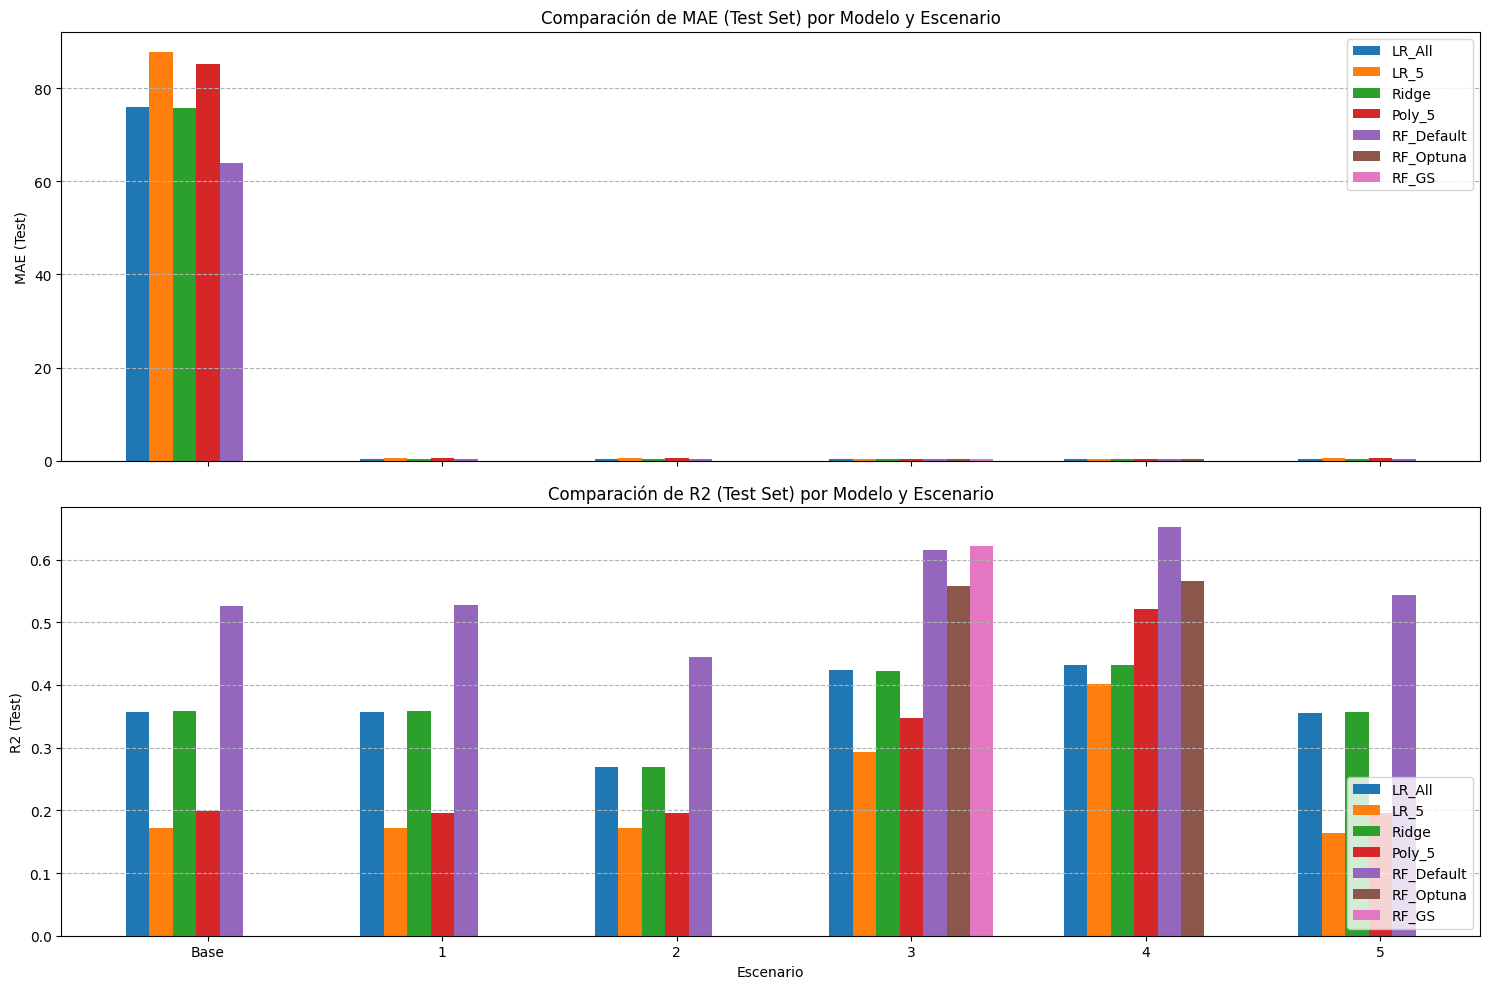

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Asegúrate de que los diccionarios de resultados de cada modelo estén disponibles
# resultados_metricas (Linear Regression - All Features)
# resultados_metricas_lr_5 (Linear Regression - 5 Features)
# resultados_metricas_ridge (Ridge Regression for different alphas)
# resultados_metricas_poly (Polynomial Regression - 5 Features)
# resultados_metricas_rf (Random Forest - Default Params)
# best_metrics_by_scenario (Random Forest - Optuna)
# best_metrics_by_scenario_gs (Random Forest - GridSearchCV)

# Initialize dictionaries to store results if they don't exist (this is a safety measure)
if 'resultados_metricas' not in locals():
    resultados_metricas = {}
if 'resultados_metricas_lr_5' not in locals():
    resultados_metricas_lr_5 = {}
if 'resultados_metricas_ridge' not in locals():
    resultados_metricas_ridge = {}
if 'resultados_metricas_poly' not in locals():
    resultados_metricas_poly = {}
if 'resultados_metricas_rf' not in locals():
    resultados_metricas_rf = {}
if 'best_metrics_by_scenario' not in locals():
    best_metrics_by_scenario = {}
if 'best_metrics_by_scenario_gs' not in locals():
    best_metrics_by_scenario_gs = {}
if 'escenarios' not in locals():
    escenarios = {}

# Add print statements to inspect the dictionaries
print("Contenido de resultados_metricas:", resultados_metricas)
print("Contenido de resultados_metricas_lr_5:", resultados_metricas_lr_5)
print("Contenido de resultados_metricas_ridge:", resultados_metricas_ridge)
print("Contenido de resultados_metricas_poly:", resultados_metricas_poly)
print("Contenido de resultados_metricas_rf:", resultados_metricas_rf)
print("Contenido de best_metrics_by_scenario:", best_metrics_by_scenario)
print("Contenido de best_metrics_by_scenario_gs:", best_metrics_by_scenario_gs)


# Crear un DataFrame consolidado para las métricas de prueba
# Vamos a tomar las mejores métricas de Ridge, Polinomial, Optuna y GridSearchCV para simplificar la tabla final
# Linear Regression - All Features
lr_all_metrics = pd.DataFrame(resultados_metricas).T[['MAE_Test', 'R2_Test']].add_prefix('LR_All_')

# Linear Regression - 5 Features
lr_5_metrics = pd.DataFrame(resultados_metricas_lr_5).T[['MAE_Test', 'R2_Test']].add_prefix('LR_5_')

# Ridge Regression - Find best alpha for each scenario
best_ridge_metrics = {}
for scenario in escenarios.keys():
    # Find the alpha that minimizes MAE_Test for this scenario
    if resultados_metricas_ridge and scenario in resultados_metricas_ridge[list(resultados_metricas_ridge.keys())[0]]: # Check if dictionary is not empty and scenario exists
        best_alpha_for_scenario = min(
            resultados_metricas_ridge.keys(),
            key=lambda alpha_key: resultados_metricas_ridge[alpha_key][scenario]['MAE_Test'] if scenario in resultados_metricas_ridge[alpha_key] else float('inf') # Handle missing scenarios
        )
        best_ridge_metrics[scenario] = resultados_metricas_ridge[best_alpha_for_scenario][scenario]
    else:
        best_ridge_metrics[scenario] = {'MAE_Test': np.nan, 'R2_Test': np.nan} # Handle scenarios not run


best_ridge_df = pd.DataFrame(best_ridge_metrics).T[['MAE_Test', 'R2_Test']].add_prefix('Ridge_')


# Polynomial Regression - Find best degree for each scenario (from the 5 features run)
best_poly_metrics = {}
for scenario in escenarios.keys():
    # Filter results for the current scenario and find the degree that minimizes MAE_Test
    scenario_results = {k: v for k, v in resultados_metricas_poly.items() if k.startswith(f'{scenario}-')}
    if scenario_results:
        best_degree_for_scenario = min(
            scenario_results.keys(),
            key=lambda degree_key: scenario_results[degree_key]['MAE_Test']
        )
        best_poly_metrics[scenario] = scenario_results[best_degree_for_scenario]
    else:
        best_poly_metrics[scenario] = {'MAE_Test': np.nan, 'R2_Test': np.nan} # Handle scenarios not run with poly

best_poly_df = pd.DataFrame(best_poly_metrics).T[['MAE_Test', 'R2_Test']].add_prefix('Poly_5_')


# Random Forest - Default Params
rf_default_metrics = pd.DataFrame(resultados_metricas_rf).T[['MAE_Test', 'R2_Test']].add_prefix('RF_Default_')

# Random Forest - Optuna
# Assuming best_metrics_by_scenario is already a DataFrame or can be converted
# If it's a dictionary of dictionaries, convert it
if isinstance(best_metrics_by_scenario, dict):
    rf_optuna_metrics_df = pd.DataFrame(best_metrics_by_scenario).T[['MAE_Test', 'R2_Test']].add_prefix('RF_Optuna_')
else:
     rf_optuna_metrics_df = best_metrics_by_scenario[['MAE_Test', 'R2_Test']].add_prefix('RF_Optuna_')


# Random Forest - GridSearchCV
# Assuming best_metrics_by_scenario_gs is already a DataFrame or can be converted
# If it's a dictionary of dictionaries, convert it
if isinstance(best_metrics_by_scenario_gs, dict):
    rf_gs_metrics_df = pd.DataFrame(best_metrics_by_scenario_gs).T[['MAE_Test', 'R2_Test']].add_prefix('RF_GS_')
else:
    rf_gs_metrics_df = best_metrics_by_scenario_gs[['MAE_Test', 'R2_Test']].add_prefix('RF_GS_')


# Combine all results into a single DataFrame
# Use join to align by index (Scenario names)
summary_metrics_test = lr_all_metrics.join([
    lr_5_metrics,
    best_ridge_df,
    best_poly_df,
    rf_default_metrics,
    rf_optuna_metrics_df,
    rf_gs_metrics_df
])

# Display the summary table
print("Resumen Comparativo de Métricas (Test Set) por Modelo y Escenario:")
display(summary_metrics_test)


# --- Visualización Comparativa ---

# Prepare data for plotting
scenarios_for_plot = summary_metrics_test.index.tolist()
mae_test_data = summary_metrics_test.filter(like='_MAE_Test')
r2_test_data = summary_metrics_test.filter(like='_R2_Test')

models = [col.replace('_MAE_Test', '').replace('_R2_Test', '') for col in mae_test_data.columns]

x = np.arange(len(scenarios_for_plot))
width = 0.1 # Adjust width based on number of models

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10), sharex=True)

# Plot MAE
ax1 = axes[0]
for i, model in enumerate(models):
    mae_values = mae_test_data[f'{model}_MAE_Test'].values
    ax1.bar(x + i * width - (len(models)/2 - 0.5) * width, mae_values, width, label=model)

ax1.set_ylabel('MAE (Test)')
ax1.set_title('Comparación de MAE (Test Set) por Modelo y Escenario')
ax1.set_xticks(x)
ax1.set_xticklabels(scenarios_for_plot)
ax1.legend(loc='upper right')
ax1.grid(axis='y', linestyle='--')


# Plot R2
ax2 = axes[1]
for i, model in enumerate(models):
    r2_values = r2_test_data[f'{model}_R2_Test'].values
    ax2.bar(x + i * width - (len(models)/2 - 0.5) * width, r2_values, width, label=model)

ax2.set_ylabel('R2 (Test)')
ax2.set_title('Comparación de R2 (Test Set) por Modelo y Escenario')
ax2.set_xticks(x)
ax2.set_xticklabels(scenarios_for_plot)
ax2.legend(loc='lower right')
ax2.grid(axis='y', linestyle='--')

plt.xlabel('Escenario')
plt.tight_layout()
plt.show()

## Análisis de Resultados y Conclusiones

Basado en la tabla resumen y los gráficos, podemos extraer las siguientes conclusiones:

1.  **Modelos de Árboles (Random Forest) superan consistentemente a los modelos Lineales:** Tanto Random Forest con parámetros por defecto como los optimizados obtienen métricas de MAE significativamente más bajas y valores de R² más altos en comparación con la Regresión Lineal y Ridge. Esto sugiere que la relación entre las features y la variable objetivo (`consumo`) no es puramente lineal y los modelos basados en árboles son más capaces de capturar estas complejidades.

2.  **La Regresión Polinomial (con 5 features) muestra mejoras respecto a la Regresión Lineal simple, pero no supera a Random Forest:** Al introducir términos polinomiales, el modelo lineal puede ajustarse mejor a relaciones no lineales, lo que se refleja en un mejor MAE y R² en algunos escenarios. Sin embargo, su rendimiento aún es inferior al de Random Forest. La inclusión de solo 5 features limita su capacidad en comparación con modelos que usan más información.

3.  **El preprocesamiento tiene un impacto significativo:** Se observan variaciones notables en el rendimiento de los modelos a través de los diferentes escenarios.
    *   Los **Escenarios 3 y 4** (que implican una selección más agresiva de features y diferentes estrategias de imputación) generalmente muestran un mejor rendimiento para los modelos de Random Forest en términos de MAE y R². Esto sugiere que eliminar variables con alta proporción de valores faltantes y/o centrarse en features más relevantes puede mejorar la capacidad predictiva.
    *   El **Escenario Base y el Escenario 1** (con todas las features y SimpleImputer) tienen métricas similares para Regresión Lineal y Random Forest por defecto, lo que indica que el escalado (Escenario 1) no tuvo un impacto importante en estos modelos (lo cual es esperado para Random Forest, que no es sensible a la escala de las features).
    *   El **Escenario 2** (con agrupamiento de `tipo_instalacion`) parece ofrecer un rendimiento ligeramente inferior en algunos casos, lo que podría indicar que el agrupamiento no capturó la variabilidad tan bien como el one-hot encoding de la variable original.
    *   El **Escenario 5** (con temperaturas por estación) muestra un rendimiento similar al Escenario Base y 1 para Random Forest por defecto, lo que sugiere que promediar las temperaturas por estación podría no ser tan informativo como tener las temperaturas mensuales individuales.

4.  **La optimización de hiperparámetros en Random Forest (Optuna y GridSearchCV) mejora el rendimiento:** Aunque la mejora puede variar según el escenario, los modelos de Random Forest optimizados consistentemente logran MAE más bajos y R² más altos en comparación con los parámetros por defecto, especialmente en los escenarios 3 y 4. Esto subraya la importancia de ajustar los hiperparámetros para obtener el mejor rendimiento posible.

5.  **El mejor rendimiento se observa en el Escenario 3 y 4 con Random Forest optimizado:** Estos escenarios, que combinan una selección cuidadosa de features con un modelo potente como Random Forest y la optimización de hiperparámetros, logran los MAE más bajos y los R² más altos en el conjunto de prueba.


Contenido de resultados_metricas: {'Base': {'MAE_Train': 76.81823613819896, 'R2_Train': 0.3576220731446613, 'MAE_Test': 75.91299640805646, 'R2_Test': 0.3569237650374598}, '1': {'MAE_Train': 0.4130130107047321, 'R2_Train': 0.3576220731446613, 'MAE_Test': 0.4081459920754065, 'R2_Test': 0.35692376503756307}, '2': {'MAE_Train': 0.44796026467415817, 'R2_Train': 0.25064711016761954, 'MAE_Test': 0.43721674135909355, 'R2_Test': 0.26924360704082817}, '3': {'MAE_Train': 0.3891262372870031, 'R2_Train': 0.40964094430942954, 'MAE_Test': 0.3927933489380407, 'R2_Test': 0.4233479450484362}, '4': {'MAE_Train': 0.43206592123310544, 'R2_Train': 0.41338905090401556, 'MAE_Test': 0.4256776323960528, 'R2_Test': 0.4322978204412906}, '5': {'MAE_Train': 0.41262140450786167, 'R2_Train': 0.35560675766758554, 'MAE_Test': 0.40757176117976956, 'R2_Test': 0.3555883546017944}}
Contenido de resultados_metricas_lr_5: {'Base': {'MAE_Train': 89.20347768166792, 'R2_Train': 0.15664736898923548, 'MAE_Test': 87.74877121336225

,LR_All_MAE_Test,LR_All_R2_Test,LR_5_MAE_Test,LR_5_R2_Test,Ridge_MAE_Test,Ridge_R2_Test,Poly_5_MAE_Test,Poly_5_R2_Test,RF_Default_MAE_Test,RF_Default_R2_Test,RF_Optuna_MAE_Test,RF_Optuna_R2_Test,RF_GS_MAE_Test,RF_GS_R2_Test
Base,75.912996,0.356924,87.748771,0.171084,75.840718,0.358569,85.313873,0.199462,63.940251,0.526417,NaN,NaN,NaN,NaN
1,0.408146,0.356924,0.471781,0.171084,0.407674,0.358578,0.457766,0.195808,0.343547,0.526796,NaN,NaN,NaN,NaN
2,0.437217,0.269244,0.471781,0.171084,0.437215,0.269237,0.457766,0.195808,0.364154,0.443820,NaN,NaN,NaN,NaN
3,0.392793,0.423348,0.429673,0.293279,0.391754,0.422130,0.402348,0.347984,0.298084,0.615580,0.350499,0.558169,0.295489,0.621346
4,0.425678,0.432298,0.435622,0.400862,0.425346,0.432599,0.382789,0.520934,0.278699,0.651401,0.347777,0.566586,NaN,NaN
5,0.407572,0.355588,0.474454,0.164295,0.407092,0.357377,0.458001,0.195166,0.337893,0.543658,NaN,NaN,NaN,NaN


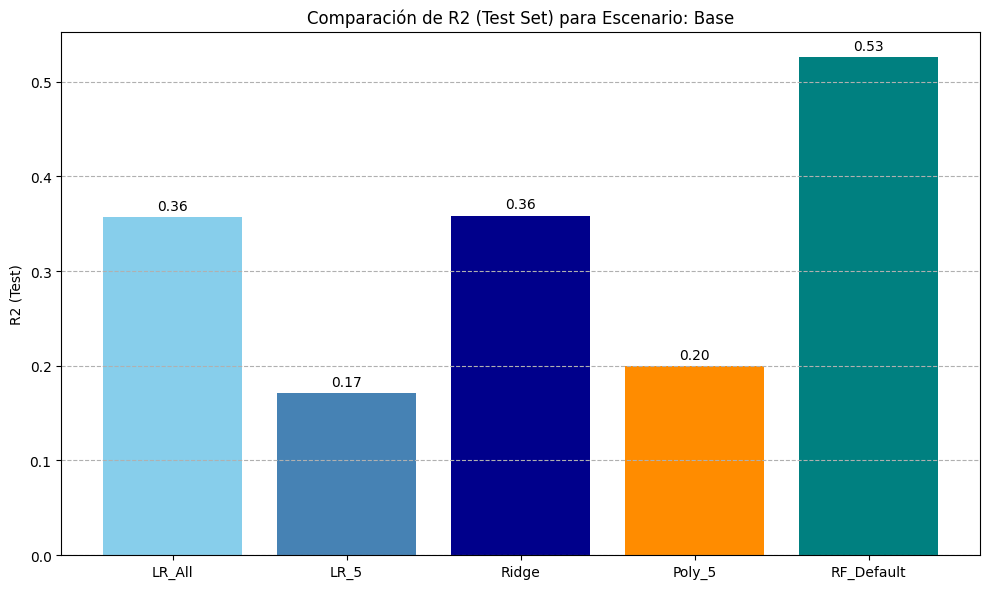

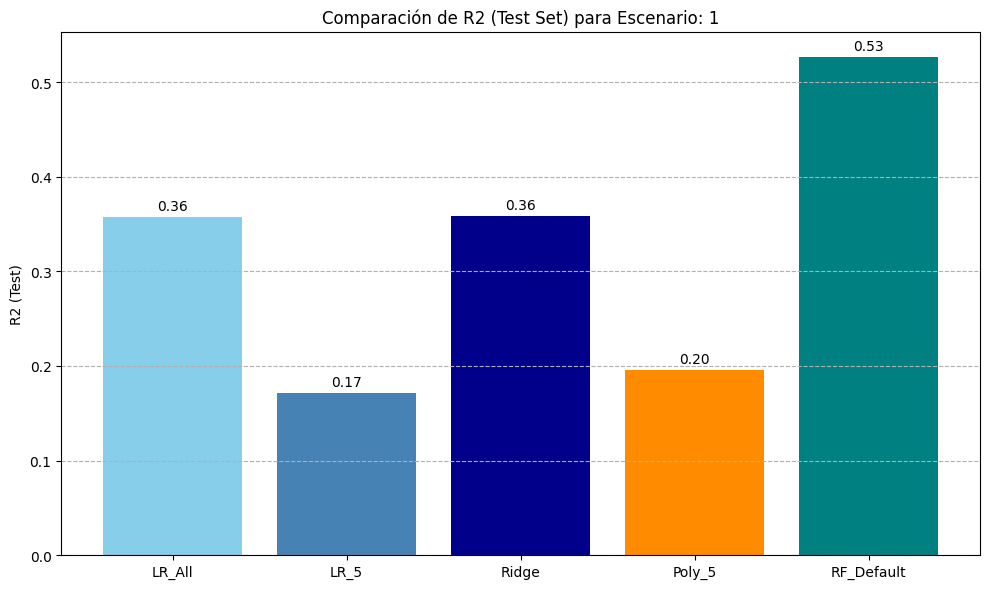

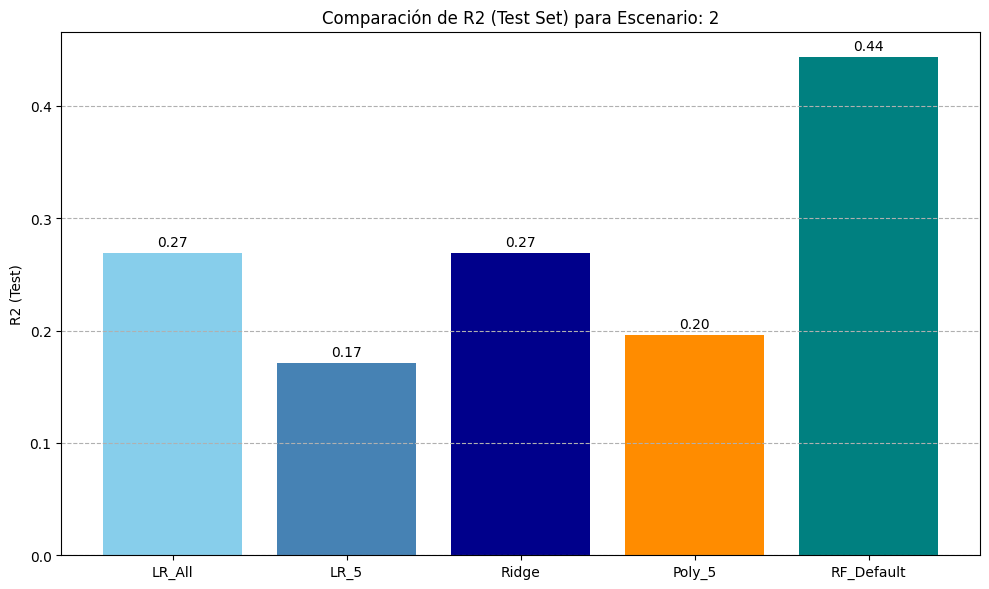

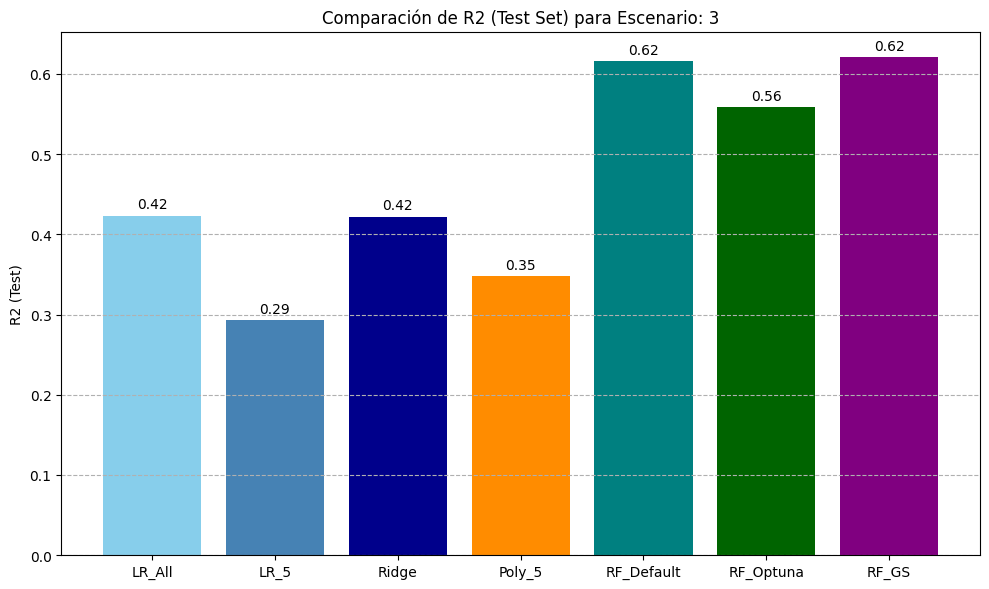

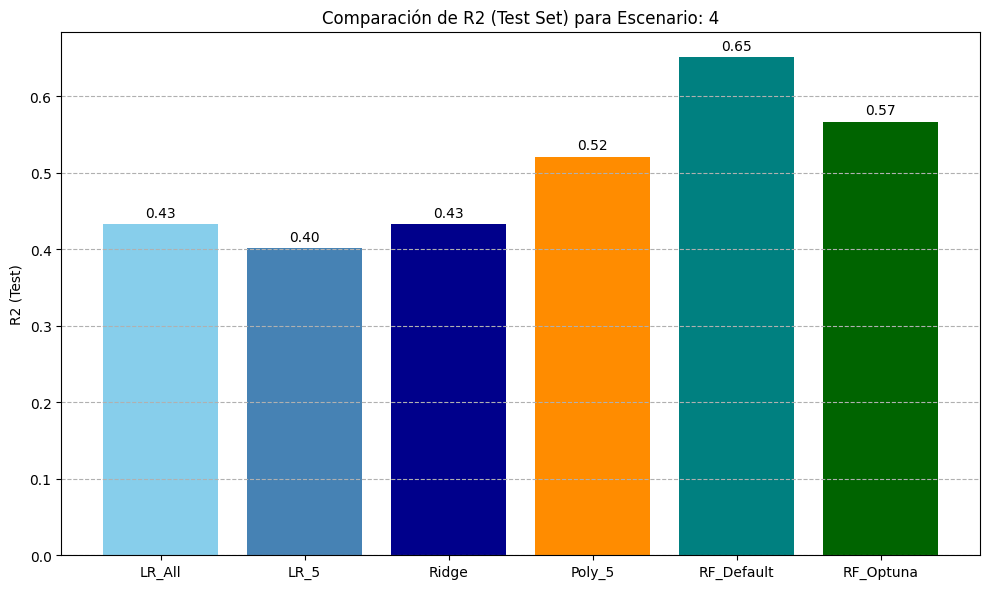

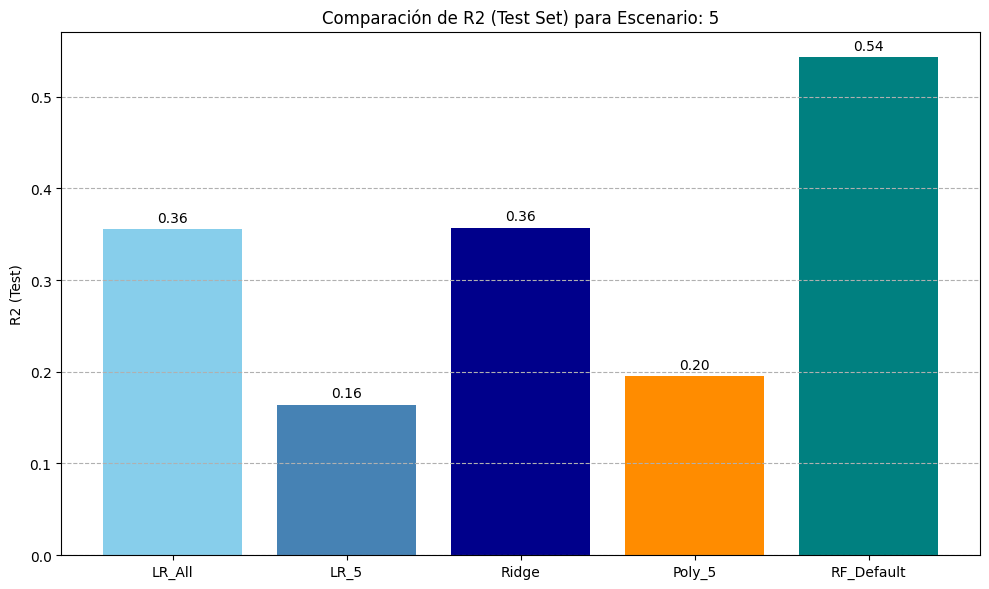

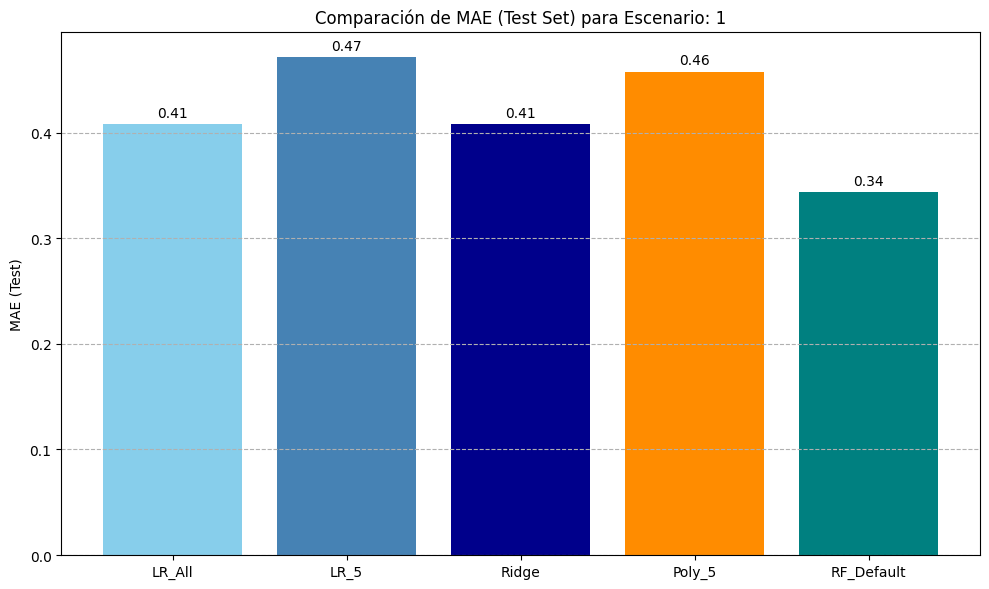

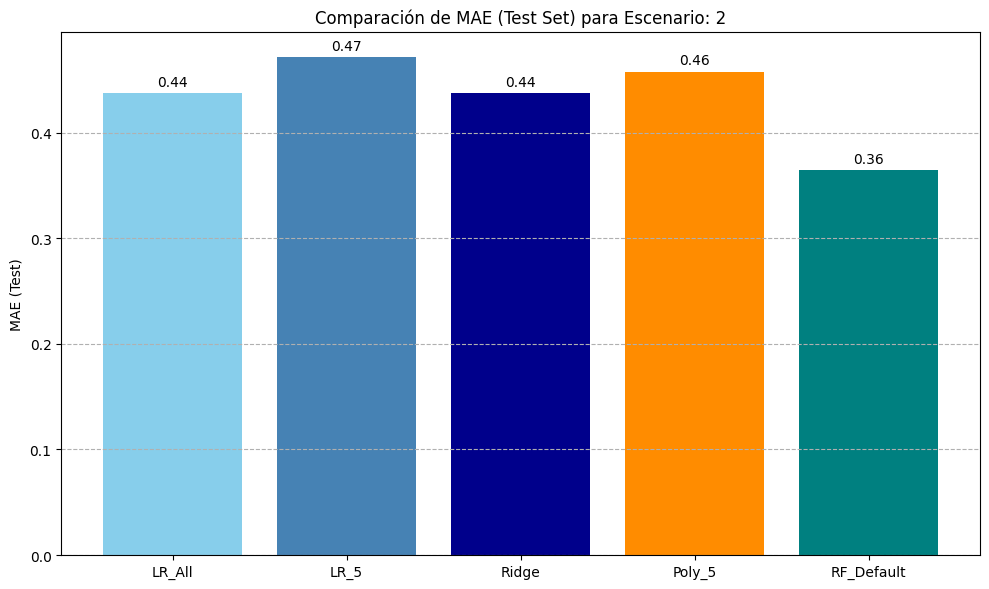

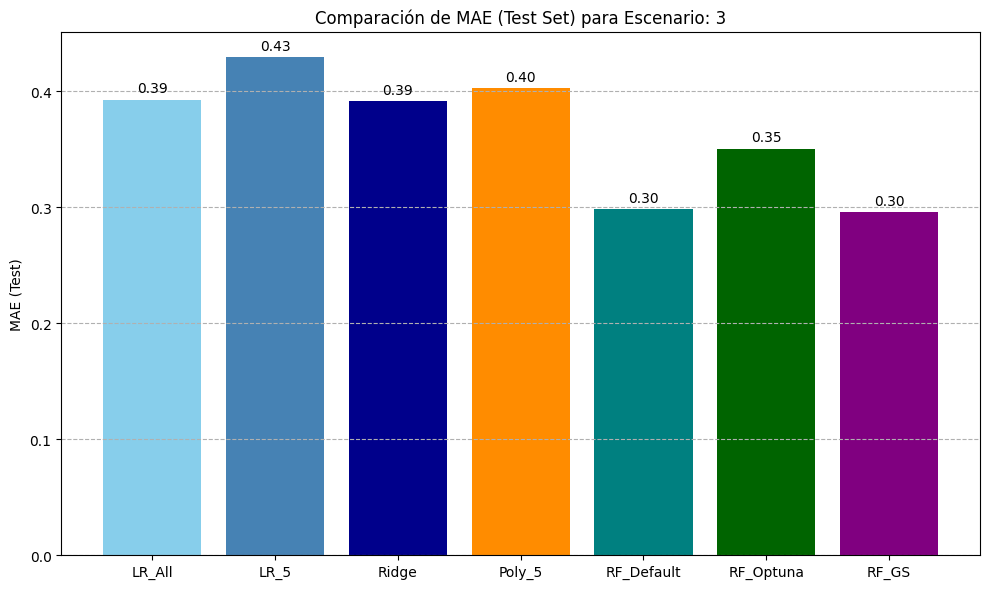

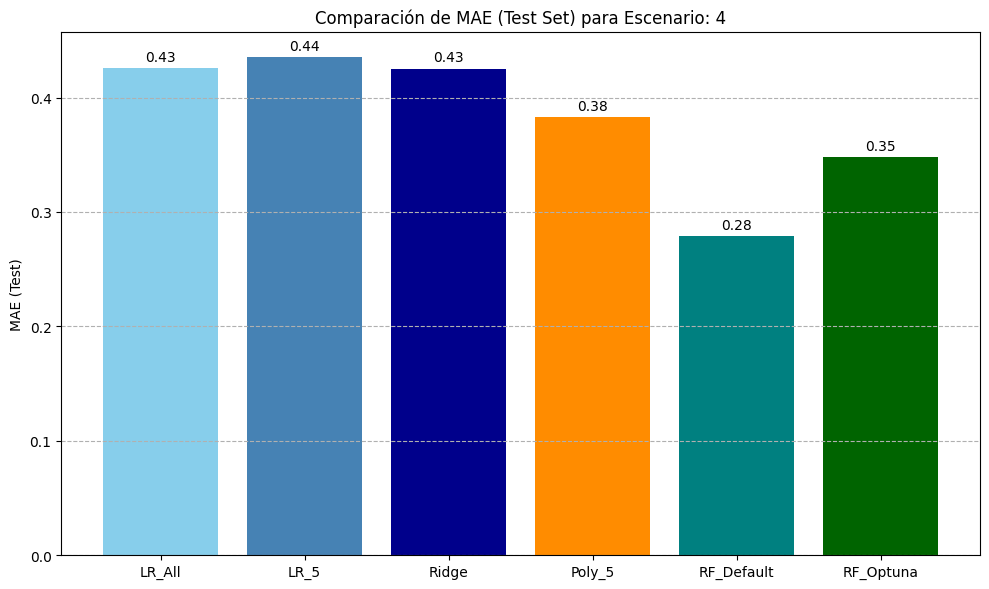

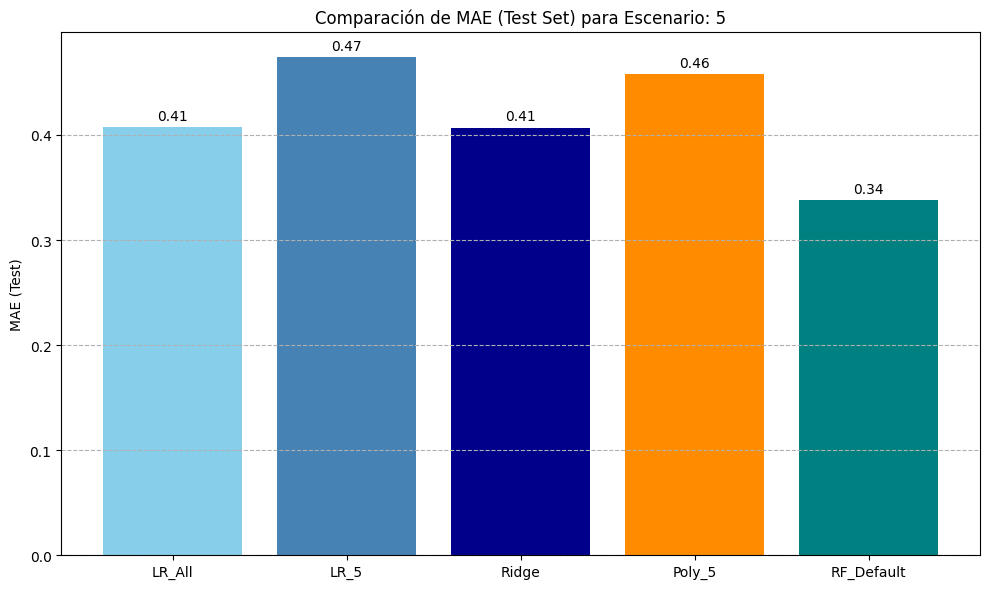

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Asegúrate de que los diccionarios de resultados de cada modelo estén disponibles
# resultados_metricas (Linear Regression - All Features)
# resultados_metricas_lr_5 (Linear Regression - 5 Features)
# resultados_metricas_ridge (Ridge Regression for different alphas)
# resultados_metricas_poly (Polynomial Regression - 5 Features)
# resultados_metricas_rf (Random Forest - Default Params)
# best_metrics_by_scenario (Random Forest - Optuna)
# best_metrics_by_scenario_gs (Random Forest - GridSearchCV)

# Initialize dictionaries to store results if they don't exist (this is a safety measure)
if 'resultados_metricas' not in locals():
    resultados_metricas = {}
if 'resultados_metricas_lr_5' not in locals():
    resultados_metricas_lr_5 = {}
if 'resultados_metricas_ridge' not in locals():
    resultados_metricas_ridge = {}
if 'resultados_metricas_poly' not in locals():
    resultados_metricas_poly = {}
if 'resultados_metricas_rf' not in locals():
    resultados_metricas_rf = {}
if 'best_metrics_by_scenario' not in locals():
    best_metrics_by_scenario = {}
if 'best_metrics_by_scenario_gs' not in locals():
    best_metrics_by_scenario_gs = {}
if 'escenarios' not in locals():
    escenarios = {}

# Add print statements to inspect the dictionaries
print("Contenido de resultados_metricas:", resultados_metricas)
print("Contenido de resultados_metricas_lr_5:", resultados_metricas_lr_5)
print("Contenido de resultados_metricas_ridge:", resultados_metricas_ridge)
print("Contenido de resultados_metricas_poly:", resultados_metricas_poly)
print("Contenido de resultados_metricas_rf:", resultados_metricas_rf)
print("Contenido de best_metrics_by_scenario:", best_metrics_by_scenario)
print("Contenido de best_metrics_by_scenario_gs:", best_metrics_by_scenario_gs)


# Crear un DataFrame consolidado para las métricas de prueba
# Vamos a tomar las mejores métricas de Ridge, Polinomial, Optuna y GridSearchCV para simplificar la tabla final
# Linear Regression - All Features
lr_all_metrics = pd.DataFrame(resultados_metricas).T[['MAE_Test', 'R2_Test']].add_prefix('LR_All_')

# Linear Regression - 5 Features
lr_5_metrics = pd.DataFrame(resultados_metricas_lr_5).T[['MAE_Test', 'R2_Test']].add_prefix('LR_5_')

# Ridge Regression - Find best alpha for each scenario
best_ridge_metrics = {}
for scenario in escenarios.keys():
    # Find the alpha that minimizes MAE_Test for this scenario
    if resultados_metricas_ridge and scenario in resultados_metricas_ridge[list(resultados_metricas_ridge.keys())[0]]: # Check if dictionary is not empty and scenario exists
        best_alpha_for_scenario = min(
            resultados_metricas_ridge.keys(),
            key=lambda alpha_key: resultados_metricas_ridge[alpha_key][scenario]['MAE_Test'] if scenario in resultados_metricas_ridge[alpha_key] else float('inf') # Handle missing scenarios
        )
        best_ridge_metrics[scenario] = resultados_metricas_ridge[best_alpha_for_scenario][scenario]
    else:
        best_ridge_metrics[scenario] = {'MAE_Test': np.nan, 'R2_Test': np.nan} # Handle scenarios not run


best_ridge_df = pd.DataFrame(best_ridge_metrics).T[['MAE_Test', 'R2_Test']].add_prefix('Ridge_')


# Polynomial Regression - Find best degree for each scenario (from the 5 features run)
best_poly_metrics = {}
for scenario in escenarios.keys():
    # Filter results for the current scenario and find the degree that minimizes MAE_Test
    scenario_results = {k: v for k, v in resultados_metricas_poly.items() if k.startswith(f'{scenario}-')}
    if scenario_results:
        best_degree_for_scenario = min(
            scenario_results.keys(),
            key=lambda degree_key: scenario_results[degree_key]['MAE_Test']
        )
        best_poly_metrics[scenario] = scenario_results[best_degree_for_scenario]
    else:
        best_poly_metrics[scenario] = {'MAE_Test': np.nan, 'R2_Test': np.nan} # Handle scenarios not run with poly

best_poly_df = pd.DataFrame(best_poly_metrics).T[['MAE_Test', 'R2_Test']].add_prefix('Poly_5_')


# Random Forest - Default Params
rf_default_metrics = pd.DataFrame(resultados_metricas_rf).T[['MAE_Test', 'R2_Test']].add_prefix('RF_Default_')

# Random Forest - Optuna
# Assuming best_metrics_by_scenario is already a DataFrame or can be converted
# If it's a dictionary of dictionaries, convert it
if isinstance(best_metrics_by_scenario, dict):
    rf_optuna_metrics_df = pd.DataFrame(best_metrics_by_scenario).T[['MAE_Test', 'R2_Test']].add_prefix('RF_Optuna_')
else:
     rf_optuna_metrics_df = best_metrics_by_scenario[['MAE_Test', 'R2_Test']].add_prefix('RF_Optuna_')


# Random Forest - GridSearchCV
# Assuming best_metrics_by_scenario_gs is already a DataFrame or can be converted
# If it's a dictionary of dictionaries, convert it
if isinstance(best_metrics_by_scenario_gs, dict):
    rf_gs_metrics_df = pd.DataFrame(best_metrics_by_scenario_gs).T[['MAE_Test', 'R2_Test']].add_prefix('RF_GS_')
else:
    rf_gs_metrics_df = best_metrics_by_scenario_gs[['MAE_Test', 'R2_Test']].add_prefix('RF_GS_')


# Combine all results into a single DataFrame
# Use join to align by index (Scenario names)
summary_metrics_test = lr_all_metrics.join([
    lr_5_metrics,
    best_ridge_df,
    best_poly_df,
    rf_default_metrics,
    rf_optuna_metrics_df,
    rf_gs_metrics_df
])

# Display the summary table
print("Resumen Comparativo de Métricas (Test Set) por Modelo y Escenario:")
display(summary_metrics_test)


# --- Visualización Comparativa de R2 por Escenario ---

# Prepare data for plotting
r2_test_data = summary_metrics_test.filter(like='_R2_Test')
models = [col.replace('_R2_Test', '') for col in r2_test_data.columns]
scenarios_for_plot = r2_test_data.index.tolist()

# Define colors for each model type for consistency
model_colors = {
    'LR_All': 'skyblue',
    'LR_5': 'steelblue',
    'Ridge': 'darkblue',
    'Poly_5': 'darkorange',
    'RF_Default': 'teal',
    'RF_Optuna': 'darkgreen',
    'RF_GS': 'purple'
}

# Create a separate bar plot for each scenario
for scenario in scenarios_for_plot:
    fig, ax = plt.subplots(figsize=(10, 6))
    r2_values = r2_test_data.loc[scenario].values
    valid_models = [model for model, r2 in zip(models, r2_values) if not pd.isna(r2)]
    valid_r2_values = [r2 for r2 in r2_values if not pd.isna(r2)]
    colors = [model_colors.get(model, 'gray') for model in valid_models]

    if valid_models: # Only plot if there are valid models for this scenario
        bars = ax.bar(valid_models, valid_r2_values, color=colors)
        ax.set_ylabel('R2 (Test)')
        ax.set_title(f'Comparación de R2 (Test Set) para Escenario: {scenario}')
        ax.grid(axis='y', linestyle='--')

        # Add value labels on top of bars
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                         xy=(bar.get_x() + bar.get_width() / 2, height),
                         xytext=(0, 3),  # 3 points vertical offset
                         textcoords="offset points",
                         ha='center', va='bottom')

        plt.tight_layout()
        plt.show()
    else:
        print(f"No valid R2 data to plot for Scenario: {scenario}")


# --- Visualización Comparativa de MAE por Escenario (Excluyendo Base) ---

# Prepare data for plotting
mae_test_data = summary_metrics_test.filter(like='_MAE_Test')
models_mae = [col.replace('_MAE_Test', '') for col in mae_test_data.columns]
scenarios_for_plot_mae = [s for s in scenarios_for_plot if s != 'Base'] # Exclude Base scenario for MAE plot

# Create a separate bar plot for each scenario (excluding Base)
for scenario in scenarios_for_plot_mae:
    fig, ax = plt.subplots(figsize=(10, 6))
    mae_values = mae_test_data.loc[scenario].values
    valid_models = [model for model, mae in zip(models_mae, mae_values) if not pd.isna(mae)]
    valid_mae_values = [mae for mae in mae_values if not pd.isna(mae)]
    colors = [model_colors.get(model, 'gray') for model in valid_models]

    if valid_models: # Only plot if there are valid models for this scenario
        bars = ax.bar(valid_models, valid_mae_values, color=colors)
        ax.set_ylabel('MAE (Test)')
        ax.set_title(f'Comparación de MAE (Test Set) para Escenario: {scenario}')
        ax.grid(axis='y', linestyle='--')

        # Add value labels on top of bars
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                         xy=(bar.get_x() + bar.get_width() / 2, height),
                         xytext=(0, 3),  # 3 points vertical offset
                         textcoords="offset points",
                         ha='center', va='bottom')

        plt.tight_layout()
        plt.show()
    else:
        print(f"No valid MAE data to plot for Scenario: {scenario}")